# Homework: Airbnb Database Analysis

## Group number:

Register your group [here](https://docs.google.com/spreadsheets/d/1x3htD8e3jwgOb4CQckgrhO8l51WJmPDXVjZWM1cb8_o/edit?usp=sharing)

## Group members:
1. `Part A: 20250376 | Daniel Ribeiro`
2. `Part B: 20250407 | Marta Feital`
3. `Part C: 20250364 | Beatriz Pinto`
4. `Part D: 20250434 | Beatriz Correia`
5. `Part E: 20250389 | Pedro Rei`

# 1. Setup & Connection

In [ ]:
import math
import time
import pprint
import warnings
import statistics
import numpy as np
import pandas as pd
import seaborn as sns
import json as _json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pprint import pprint
from datetime import datetime
from unidecode import unidecode
from bson.objectid import ObjectId
from bson.decimal128 import Decimal128
from collections import Counter, defaultdict

from pymongo import MongoClient, UpdateOne, ASCENDING, DESCENDING

In [2]:
warnings.filterwarnings("ignore")

user="AzureDiamond"
password="hunter2"
host="localhost"
port="27017"
protocol="mongodb"

client = MongoClient(f"{protocol}://{user}:{password}@{host}:{port}")

db = client.sample_airbnb 
collection = db["listingsAndReviews_HW2_new"]
hosts = db["hosts"]
reviews = db["reviews"]

print(f"Database info: {db}\n")
db.name 



Database info: Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'sample_airbnb')



'sample_airbnb'

[PyMongo documentation](https://pymongo.readthedocs.io/en/stable/api/pymongo/collection.html)

# 2. Data Quality Analysis

## 2.1 Database Overview

In [3]:
# Collections in the database
collection_list = db.list_collection_names()

# Select main collection explicitly
collection_name = "listingsAndReviews_HW2_new"

# Get sample document and fields
sample_doc = collection.find_one()
fields = list(sample_doc.keys()) if sample_doc else []

# Print info
print(f"The database contains {len(collection_list)} collections")
print(f"All collections: {collection_list}")
print(f"Collection '{collection_name}' contains {collection.count_documents({})} documents")
print(f"Fields in collection '{collection_name}': {fields}")
print("\n--- Collections Overview ---")
for col in collection_list:
    print(f"{col}: {db[col].count_documents({})} documents")

The database contains 1 collections
All collections: ['listingsAndReviews_HW2_new']
Collection 'listingsAndReviews_HW2_new' contains 5555 documents
Fields in collection 'listingsAndReviews_HW2_new': ['_id', 'listing_url', 'name', 'summary', 'space', 'description', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction', 'house_rules', 'property_type', 'room_type', 'bed_type', 'minimum_nights', 'maximum_nights', 'cancellation_policy', 'last_scraped', 'calendar_last_scraped', 'first_review', 'last_review', 'accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'bathrooms', 'amenities', 'price', 'security_deposit', 'cleaning_fee', 'extra_people', 'guests_included', 'images', 'host', 'address', 'availability', 'review_scores', 'reviews', 'transactions', 'review_scores_rating']

--- Collections Overview ---
listingsAndReviews_HW2_new: 5555 documents


The database contains **1 collections**:

Each document in the collection represents an **Airbnb listing** and stores several types of information in a single document. The working collection for this project is **`listingsAndReviews_HW2_new`**.

#### Main Fields

| Category | Field Name | Description |
| :--- | :--- | :--- |
| **Basic Information** | `_id`, `listing_url`, `name`, `summary`, `space`, `description`, `neighborhood_overview` | Identification, URL, and general textual descriptions of the listing. |
| **Property Characteristics** | `property_type`, `room_type`, `bed_type`, `accommodates`, `bedrooms`, `beds`, `bathrooms` | Physical attributes, capacity, and layout of the property. |
| **Booking Rules** | `minimum_nights`, `maximum_nights`, `cancellation_policy`, `house_rules` | Requirements, limits, and policies for stay and behavior. |
| **Pricing Information** | `price`, `security_deposit`, `cleaning_fee`, `extra_people`, `guests_included` | Detailed cost breakdown, fees, and guest capacity limits. |
| **Reviews and Ratings** | `number_of_reviews`, `first_review`, `last_review`, `review_scores`, `review_scores_rating`, `reviews` | Feedback data, history of reviews, and overall quality metrics. |
| **Host and Location** | `host`, `address` | Information about the listing owner and the geographic location. |
| **Other Fields** | `availability`, `images`, `transactions`, `amenities` | Dynamic status, visual assets, and provided facilities. |

#### Modeling Observation

The collection uses a **highly embedded structure**, meaning that several related pieces of information are stored directly inside each listing document.

Examples:
- `host` is stored as an embedded document
- `address` is stored as an embedded document
- `reviews` is stored as an array of embedded subdocuments

This structure is convenient for retrieving all listing information at once, but it may also create some issues:
- very large documents, especially when listings have many reviews
- repeated host information across multiple listings
- potentially less efficient updates and queries for large embedded arrays

#### Project Implication

Because of this structure, the database is a good candidate for **redesign**, especially in:
- separating large and growing fields such as `reviews`
- reducing redundancy for repeated entities such as `host`
- improving performance with more appropriate indexing

## 2.2 Type & Missing Values Analysis

In [4]:
def check_all_field_types_with_nulls(db, collection_name, fields):
    collection = db[collection_name]
    total_docs = collection.count_documents({})
    
    results = {}
    
    for field in fields:
        # Count data types present in the field
        pipeline = [
            {
                "$group": {
                    "_id": {"$type": f"${field}"},
                    "count": {"$sum": 1}
                }
            }
        ]
        types = list(collection.aggregate(pipeline))
        
        # Count null or missing values
        null_or_missing_count = collection.count_documents({
            "$or": [
                {field: None},
                {field: {"$exists": False}}
            ]
        })
        
        results[field] = {
            "types": types,
            "null_or_missing_count": null_or_missing_count,
            "null_or_missing_percentage": (null_or_missing_count / total_docs) * 100
        }
    
    return results

In [5]:
types_info = check_all_field_types_with_nulls(db, collection_name, fields)

for field, info in types_info.items():
    print(f"\nField: {field}")
    
    for t in info["types"]:
        print(f"  Type: {t['_id']} | Count: {t['count']}")
    
    print(f"  Null or missing count: {info['null_or_missing_count']}")
    print(f"  Null or missing percentage: {info['null_or_missing_percentage']:.2f}%")


Field: _id
  Type: string | Count: 5555
  Null or missing count: 0
  Null or missing percentage: 0.00%

Field: listing_url
  Type: string | Count: 5555
  Null or missing count: 0
  Null or missing percentage: 0.00%

Field: name
  Type: string | Count: 5547
  Type: missing | Count: 8
  Null or missing count: 8
  Null or missing percentage: 0.14%

Field: summary
  Type: string | Count: 5297
  Type: missing | Count: 258
  Null or missing count: 258
  Null or missing percentage: 4.64%

Field: space
  Type: string | Count: 3929
  Type: missing | Count: 1626
  Null or missing count: 1626
  Null or missing percentage: 29.27%

Field: description
  Type: string | Count: 5460
  Type: missing | Count: 95
  Null or missing count: 95
  Null or missing percentage: 1.71%

Field: neighborhood_overview
  Type: string | Count: 3314
  Type: missing | Count: 2241
  Null or missing count: 2241
  Null or missing percentage: 40.34%

Field: notes
  Type: string | Count: 2475
  Type: missing | Count: 3080
  N

## 2.3 Data Type Conversion and Missing Value Imputation

### 2.3.1 Data Type Conversion

In [6]:
# Converter extra_people: decimal → int 
result = collection.update_many(
    {"extra_people": {"$type": "decimal"}},   
    [{"$set": {"extra_people": {"$toInt": "$extra_people"}}}]
)
print(f"extra_people convertidos: {result.modified_count}")

print("\nAfter — extra_people type:")
for r in collection.aggregate([
    {"$group": {"_id": {"$type": "$extra_people"}, "count": {"$sum": 1}}}
]):
    print(r)

extra_people convertidos: 5555

After — extra_people type:
{'_id': 'int', 'count': 5555}


### 2.3.2 Null and Missing Value Imputation

In [7]:
null_amenities = collection.count_documents({"amenities": None})
missing_security_deposit = collection.count_documents({"security_deposit": None})
missing_cleaning_fee = collection.count_documents({"cleaning_fee": None})

print("Null amenities:", null_amenities)
print("Missing security_deposit:", missing_security_deposit)
print("Missing cleaning_fee:", missing_cleaning_fee)

Null amenities: 30
Missing security_deposit: 2084
Missing cleaning_fee: 1531


In [8]:
# Fix null values in amenities
result = collection.update_many(
    {"amenities": None},
    {"$set": {"amenities": []}}
)

print("Documents modified:", result.modified_count)

Documents modified: 30


In [9]:
# Fix missing security_deposit
result = collection.update_many(
    {"security_deposit": None},
    {"$set": {"security_deposit": Decimal128("0.00")}}
)

print("Documents modified:", result.modified_count)

Documents modified: 2084


In [10]:
result = collection.update_many(
    {"cleaning_fee": None},
    {"$set": {"cleaning_fee": Decimal128("0.00")}}
)

print("Documents modified:", result.modified_count)

Documents modified: 1531


## 2.4 Duplicate Analysis

In [11]:
def find_duplicates(db, collection_name, fields):
    collection = db[collection_name]

    # Allow both a single field and a list of fields
    if isinstance(fields, str):
        fields = [fields]

    # Only consider documents where all fields exist and are not null
    match_condition = {
        field: {"$exists": True, "$ne": None}
        for field in fields
    }

    # Build composite key for grouping
    group_id = {
        field.replace(".", "_"): f"${field}"
        for field in fields
    }

    pipeline = [
        {"$match": match_condition},
        {
            "$group": {
                "_id": group_id,
                "count": {"$sum": 1},
                "docs": {"$push": "$_id"}
            }
        },
        {"$match": {"count": {"$gt": 1}}},
        {"$sort": {"count": -1}}
    ]

    return list(collection.aggregate(pipeline))


def print_duplicate_summary(results, label, max_examples=5):
    print(f"\n{'='*60}")
    print(f"Duplicate analysis: {label}")
    print(f"{'='*60}")

    if not results:
        print("No duplicates found.")
        return

    print(f"Number of duplicate groups: {len(results)}")
    print(f"Total documents involved: {sum(r['count'] for r in results)}")

    print("\nTop examples:")
    for r in results[:max_examples]:
        print(f"Value / Key: {r['_id']}")
        print(f"Count: {r['count']}")
        print(f"Document IDs: {r['docs'][:5]}")
        print("-" * 40)

In [12]:
duplicates_listing_url = find_duplicates(db, collection_name, "listing_url")
print_duplicate_summary(duplicates_listing_url, "listing_url")

duplicates_name_host = find_duplicates(
    db,
    collection_name,
    ["name", "host.host_id"]
)
print_duplicate_summary(duplicates_name_host, "name + host.host_id")

duplicates_name_street = find_duplicates(
    db,
    collection_name,
    ["name", "address.street"]
)
print_duplicate_summary(duplicates_name_street, "name + address.street")

duplicates_name_host_street = find_duplicates(
    db,
    collection_name,
    ["name", "host.host_id", "address.street"]
)
print_duplicate_summary(duplicates_name_host_street, "name + host.host_id + address.street")


Duplicate analysis: listing_url
No duplicates found.

Duplicate analysis: name + host.host_id
Number of duplicate groups: 2
Total documents involved: 4

Top examples:
Value / Key: {'name': 'Quarto moradia luxo', 'host_host_id': '158889535'}
Count: 2
Document IDs: ['26556751', '26563602']
----------------------------------------
Value / Key: {'name': 'Great Location In Wakiki, Walking Distance To Beach, Shopping, Dining!', 'host_host_id': '74079684'}
Count: 2
Document IDs: ['32338760', '32338783']
----------------------------------------

Duplicate analysis: name + address.street
Number of duplicate groups: 5
Total documents involved: 10

Top examples:
Value / Key: {'name': 'Great Location In Wakiki, Walking Distance To Beach, Shopping, Dining!', 'address_street': 'Honolulu, HI, United States'}
Count: 2
Document IDs: ['32338760', '32338783']
----------------------------------------
Value / Key: {'name': 'Quarto moradia luxo', 'address_street': 'Sanguedo, Aveiro, Portugal'}
Count: 2
Doc

In [13]:
if duplicates_name_host_street:
    example = duplicates_name_host_street[0]
    doc_ids = example["docs"]

    docs = list(db[collection_name].find({"_id": {"$in": doc_ids}}))

    print("\nInspecting one duplicate group:")
    print("Duplicate key:", example["_id"])
    print("Count:", example["count"])

    for d in docs:
        print("\nDocument _id:", d.get("_id"))
        print("listing_url:", d.get("listing_url"))
        print("name:", d.get("name"))
        print("host_id:", d.get("host", {}).get("host_id"))
        print("street:", d.get("address", {}).get("street"))


Inspecting one duplicate group:
Duplicate key: {'name': 'Quarto moradia luxo', 'host_host_id': '158889535', 'address_street': 'Sanguedo, Aveiro, Portugal'}
Count: 2

Document _id: 26556751
listing_url: https://www.airbnb.com/rooms/26556751
name: Quarto moradia luxo
host_id: 158889535
street: Sanguedo, Aveiro, Portugal

Document _id: 26563602
listing_url: https://www.airbnb.com/rooms/26563602
name: Quarto moradia luxo
host_id: 158889535
street: Sanguedo, Aveiro, Portugal


| Check | Fields Used                            | Number of Duplicate Groups | Number of Documents Involved | Observations                                                                                                             |
| ----- | -------------------------------------- | -------------------------- | ---------------------------- | ------------------------------------------------------------------------------------------------------------------------ |
| 1     | `listing_url`                          | 0                          | 0                            | No duplicates found. Each listing URL is unique.                                                                         |
| 2     | `name + host.host_id`                  | 2                          | 4                            | Same host has listings with identical titles, indicating potential repetition.                                           |
| 3     | `name + address.street`                | 5                          | 10                           | Listings share the same title and street, suggesting similar listings at the same location.                              |
| 4     | `name + host.host_id + address.street` | 2                          | 4                            | Listings share the same title, host, and street. Strong indication of highly similar listings, but not exact duplicates. |


Although the table summarizes the number of potential duplicates, a closer inspection reveals important context that cannot be inferred from the numbers alone. The cases identified with composite keys represent listings that are highly similar but not exact duplicates. For example, the same host may list multiple rooms or units within the same property, sharing the same title and street address while maintaining distinct listing URLs. This indicates intentional, valid entries rather than data errors.

## 2.5 Invalid Values and Outlier Analysis

In [14]:
# =========================================================
# 1. Logical consistency check not covered before
# =========================================================

invalid_nights = collection.count_documents({
    "$expr": {"$gt": ["$minimum_nights", "$maximum_nights"]}
})

print("Invalid night ranges:", invalid_nights)

Invalid night ranges: 0


In [15]:
# =========================================================
# 2. Price distribution statistics
# =========================================================

price_stats = list(collection.aggregate([
    {
        "$group": {
            "_id": None,
            "min": {"$min": "$price"},
            "max": {"$max": "$price"},
            "avg": {"$avg": "$price"},
            "stdDev": {"$stdDevPop": "$price"}
        }
    }
]))

print(price_stats)

[{'_id': None, 'min': Decimal128('9.00'), 'max': Decimal128('48842.00'), 'avg': Decimal128('276.4275755228505034856700232378002'), 'stdDev': 916.0413171868535}]


In [16]:
# =========================================================
# 3. Price outliers using IQR
# =========================================================

price_percentiles = list(collection.aggregate([
    {
        "$group": {
            "_id": None,
            "q1": {
                "$percentile": {
                    "input": "$price",
                    "p": [0.25],
                    "method": "approximate"
                }
            },
            "q3": {
                "$percentile": {
                    "input": "$price",
                    "p": [0.75],
                    "method": "approximate"
                }
            }
        }
    }
]))

q1 = price_percentiles[0]["q1"][0]
q3 = price_percentiles[0]["q3"][0]

iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

price_outliers_count = collection.count_documents({
    "price": {"$gt": upper_bound}
})

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of price outliers:", price_outliers_count)

Q1: 70.0
Q3: 282.0
IQR: 212.0
Lower bound: -248.0
Upper bound: 600.0
Number of price outliers: 366


In [17]:
# =========================================================
# 4. Manual inspection of highest prices
# =========================================================

top_prices = collection.find(
    {},
    {"name": 1, "price": 1, "address.market": 1}
).sort("price", -1).limit(10)

print("\nTop 10 highest prices:")
for doc in top_prices:
    print(doc)


Top 10 highest prices:
{'_id': '20275354', 'name': 'İstanbul un kalbi sisli. Center of istanbul sisli', 'price': Decimal128('48842.00'), 'address': {'market': 'Istanbul'}}
{'_id': '13997910', 'name': 'Apartamento de luxo em Copacabana - 4 quartos', 'price': Decimal128('11190.00'), 'address': {'market': 'Rio De Janeiro'}}
{'_id': '30327756', 'name': '5 PEOPLE ROOM ( 1 TRIP and 1 DOUBLE)', 'price': Decimal128('10001.00'), 'address': {'market': 'Hong Kong'}}
{'_id': '6147746', 'name': 'Stunning Waterfront Marina bay house in Sai Kung', 'price': Decimal128('7002.00'), 'address': {'market': 'Hong Kong'}}
{'_id': '20517090', 'name': 'Deslumbrante apartamento na AV.Atlantica', 'price': Decimal128('6002.00'), 'address': {'market': 'Rio De Janeiro'}}
{'_id': '2271702', 'name': 'LUXURY HOUSE IN BARRA DA TIJUCA', 'price': Decimal128('5502.00'), 'address': {'market': 'Rio De Janeiro'}}
{'_id': '24847281', 'name': '鮀城小家-感受不一样的异地之旅', 'price': Decimal128('4828.00'), 'address': {'market': 'Hong Kong'

In [18]:
# =========================================================
# 5. Manual inspection of highest accommodates
# =========================================================

top_accommodates = collection.find(
    {},
    {"name": 1, "accommodates": 1, "address.market": 1}
).sort("accommodates", -1).limit(10)

print("\nTop 10 highest accommodates:")
for doc in top_accommodates:
    print(doc)


Top 10 highest accommodates:
{'_id': '19587001', 'name': 'Kaena O Kekai', 'accommodates': 16, 'address': {'market': 'Oahu'}}
{'_id': '2271702', 'name': 'LUXURY HOUSE IN BARRA DA TIJUCA', 'accommodates': 16, 'address': {'market': 'Rio De Janeiro'}}
{'_id': '23644123', 'name': 'Party/Event – Day/Night – Botafogo/Laranjeiras!', 'accommodates': 16, 'address': {'market': 'Rio De Janeiro'}}
{'_id': '20958766', 'name': 'Great Complex of the Cellars', 'accommodates': 16, 'address': {'market': 'Porto'}}
{'_id': '20455499', 'name': 'DOWNTOWN VIP MONTREAL ,HIGH END DECOR,GOOD VALUE..', 'accommodates': 16, 'address': {'market': 'Montreal'}}
{'_id': '23219274', 'name': '❤️ 6-BR APARTMENT w Kitchen + 2 Rooms!', 'accommodates': 16, 'address': {'market': 'Istanbul'}}
{'_id': '27383511', 'name': 'LEGNOCASA', 'accommodates': 16, 'address': {'market': 'Istanbul'}}
{'_id': '23921295', 'name': '-MAISON ALEXANDRA- 3 STOREY WATERFRONT PH FLOOR', 'accommodates': 16, 'address': {'market': 'Montreal'}}
{'_id':

The dataset demonstrates strong logical consistency, as no listings have minimum nights greater than maximum nights. Price values, however, exhibit a highly right-skewed distribution, with a small proportion of extremely high listings, particularly in premium or luxury markets such as Istanbul, Hong Kong, and Rio de Janeiro. Using the IQR method, approximately 545 listings were identified as price outliers, while accommodation capacities remain within plausible ranges, with a maximum of 16 guests across several locations. These findings indicate that extreme values are generally valid and should be treated as outliers rather than errors.

### 2.5.1 Consistency Checks

To assess logical coherence between related attributes, several consistency checks were performed across the dataset.

In [19]:
inconsistent_accommodates_beds = collection.count_documents({
    "$expr": {"$lt": ["$accommodates", "$beds"]}
})

potential_inconsistent_beds_bedrooms = collection.count_documents({
    "$expr": {"$lt": ["$beds", "$bedrooms"]}
})

inconsistent_reviews_1 = collection.count_documents({
    "number_of_reviews": 0,
    "first_review": {"$ne": None}
})

inconsistent_reviews_2 = collection.count_documents({
    "$expr": {"$lt": ["$last_review", "$first_review"]}
})

In [20]:
print("\n=== Consistency Checks ===")

print("\nCapacity consistency:")
print("Accommodates < beds:", inconsistent_accommodates_beds)

print("\nBedroom vs Beds (potential inconsistency):")
print("Beds < bedrooms:", potential_inconsistent_beds_bedrooms)

print("\nReview consistency:")
print("0 reviews but has first_review:", inconsistent_reviews_1)
print("last_review < first_review:", inconsistent_reviews_2)


=== Consistency Checks ===

Capacity consistency:
Accommodates < beds: 47

Bedroom vs Beds (potential inconsistency):
Beds < bedrooms: 95

Review consistency:
0 reviews but has first_review: 0
last_review < first_review: 0


The consistency analysis shows that:

- most relationships between key attributes are coherent
- review-related metadata is fully consistent
- a limited number of potentially inconsistent cases exist for:
  - `accommodates < beds`
  - `beds < bedrooms`

These cases should be flagged for awareness, but they do not necessarily justify automatic removal without further contextual inspection.

### 2.5.2 Empty Arrays, Null Values, and Cardinality Analysis

In [21]:
empty_amenities = collection.count_documents({
    "amenities": {"$size": 0}
})

missing_amenities = collection.count_documents({
    "amenities": {"$exists": False}
})

null_amenities = collection.count_documents({
    "amenities": None
})

non_empty_amenities = collection.count_documents({
    "amenities": {"$exists": True, "$nin": [[], None]}
})

print("Empty amenities:", empty_amenities)
print("Missing amenities:", missing_amenities)
print("Null amenities:", null_amenities)
print("Non-empty amenities:", non_empty_amenities)

Empty amenities: 30
Missing amenities: 0
Null amenities: 0
Non-empty amenities: 5525


In [22]:
def cardinality_analysis(db, collection_name, field, top_n=10):
    collection = db[collection_name]

    pipeline = [
        {"$group": {"_id": f"${field}", "count": {"$sum": 1}}},
        {"$sort": {"count": -1}}
    ]

    results = list(collection.aggregate(pipeline))

    print(f"\nField: {field}")
    print(f"Unique values: {len(results)}")

    for r in results[:top_n]:
        print(r)


cardinality_analysis(db, collection_name, "property_type")
cardinality_analysis(db, collection_name, "room_type")
cardinality_analysis(db, collection_name, "bed_type")
cardinality_analysis(db, collection_name, "address.market")


Field: property_type
Unique values: 36
{'_id': 'Apartment', 'count': 3626}
{'_id': 'House', 'count': 606}
{'_id': 'Condominium', 'count': 399}
{'_id': 'Serviced apartment', 'count': 185}
{'_id': 'Loft', 'count': 142}
{'_id': 'Townhouse', 'count': 108}
{'_id': 'Guest suite', 'count': 81}
{'_id': 'Bed and breakfast', 'count': 69}
{'_id': 'Boutique hotel', 'count': 53}
{'_id': 'Guesthouse', 'count': 50}

Field: room_type
Unique values: 3
{'_id': 'Entire home/apt', 'count': 3489}
{'_id': 'Private room', 'count': 1983}
{'_id': 'Shared room', 'count': 83}

Field: bed_type
Unique values: 5
{'_id': 'Real Bed', 'count': 5506}
{'_id': 'Pull-out Sofa', 'count': 26}
{'_id': 'Futon', 'count': 10}
{'_id': 'Couch', 'count': 7}
{'_id': 'Airbed', 'count': 6}

Field: address.market
Unique values: 15
{'_id': 'Istanbul', 'count': 660}
{'_id': 'Montreal', 'count': 648}
{'_id': 'Barcelona', 'count': 632}
{'_id': 'Hong Kong', 'count': 619}
{'_id': 'Sydney', 'count': 609}
{'_id': 'New York', 'count': 607}
{'

## 2.6 Task D: Specific Data Quality Checks

This section verifies specific data quality requirements mentioned in the instructions, such as incorrect timestamps, wrong data formats, and incorrect value ranges.

In [23]:
# Reference dates
AIRBNB_FOUNDING = datetime(2008, 8, 1)
SCRAPE_DATE_MAX = datetime(2020, 1, 1)

### 2.6.1 Incorrect Timestamps

In [24]:
print("=" * 60)
print("TIMESTAMP AUDIT - LISTINGS")
print("=" * 60)

date_fields = ["last_scraped", "calendar_last_scraped", "first_review", "last_review"]

for field in date_fields:
    future = collection.count_documents({field: {"$exists": True, "$ne": None, "$gt": SCRAPE_DATE_MAX}})
    too_old = collection.count_documents({field: {"$exists": True, "$ne": None, "$lt": AIRBNB_FOUNDING}})
    print(f"\nField: {field}")
    print(f"  Future dates (>{SCRAPE_DATE_MAX.date()}): {future}")
    print(f"  Pre-Airbnb dates (<{AIRBNB_FOUNDING.date()}): {too_old}")

pipeline = [
    {"$match": {"last_scraped": {"$exists": True}, "calendar_last_scraped": {"$exists": True}}},
    {"$project": {
        "diff_days": {"$divide": [{"$abs": {"$subtract": ["$last_scraped", "$calendar_last_scraped"]}}, 1000 * 60 * 60 * 24]}
    }},
    {"$group": {
        "_id": None,
        "max_diff": {"$max": "$diff_days"},
        "avg_diff": {"$avg": "$diff_days"},
        "over_30_days": {"$sum": {"$cond": [{"$gt": ["$diff_days", 30]}, 1, 0]}}
    }}
]
diff_result = list(collection.aggregate(pipeline))
if diff_result:
    r = diff_result[0]
    print(f"\nlast_scraped vs calendar_last_scraped:")
    print(f"  Max diff: {r['max_diff']:.1f} days")
    print(f"  Avg diff: {r['avg_diff']:.2f} days")
    print(f"  Pairs with > 30 days diff: {r['over_30_days']}")

TIMESTAMP AUDIT - LISTINGS

Field: last_scraped
  Future dates (>2020-01-01): 0
  Pre-Airbnb dates (<2008-08-01): 0

Field: calendar_last_scraped
  Future dates (>2020-01-01): 0
  Pre-Airbnb dates (<2008-08-01): 0

Field: first_review
  Future dates (>2020-01-01): 0
  Pre-Airbnb dates (<2008-08-01): 0

Field: last_review
  Future dates (>2020-01-01): 0
  Pre-Airbnb dates (<2008-08-01): 0

last_scraped vs calendar_last_scraped:
  Max diff: 0.0 days
  Avg diff: 0.00 days
  Pairs with > 30 days diff: 0


In [25]:
print("=" * 60)
print("TIMESTAMP AUDIT - REVIEWS")
print("=" * 60)

future_reviews = reviews.count_documents({"date": {"$gt": SCRAPE_DATE_MAX}})
old_reviews = reviews.count_documents({"date": {"$lt": AIRBNB_FOUNDING}})
no_date = reviews.count_documents({"$or": [{"date": None}, {"date": {"$exists": False}}]})

print(f"Future dates (>{SCRAPE_DATE_MAX.date()}): {future_reviews}")
print(f"Pre-Airbnb dates (<{AIRBNB_FOUNDING.date()}): {old_reviews}")
print(f"Missing date: {no_date}")

TIMESTAMP AUDIT - REVIEWS
Future dates (>2020-01-01): 0
Pre-Airbnb dates (<2008-08-01): 0
Missing date: 0


In [26]:
print("=" * 60)
print("TIMESTAMP AUDIT - REVIEWS")
print("=" * 60)

# 1. Datas no futuro
future_reviews = collection.count_documents({
    "reviews": {
        "$elemMatch": {"date": {"$gt": SCRAPE_DATE_MAX}}
    }
})

# 2. Datas antes do Airbnb
old_reviews = collection.count_documents({
    "reviews": {
        "$elemMatch": {"date": {"$lt": AIRBNB_FOUNDING}}
    }
})

# 3. Reviews sem data
no_date = collection.count_documents({
    "reviews": {
        "$elemMatch": {
            "$or": [
                {"date": None},
                {"date": {"$exists": False}}
            ]
        }
    }
})

print(f"Future dates (>{SCRAPE_DATE_MAX.date()}): {future_reviews}")
print(f"Pre-Airbnb dates (<{AIRBNB_FOUNDING.date()}): {old_reviews}")
print(f"Missing date: {no_date}")

TIMESTAMP AUDIT - REVIEWS
Future dates (>2020-01-01): 0
Pre-Airbnb dates (<2008-08-01): 0
Missing date: 0


### 2.6.3 Incorrect Value Ranges

In [27]:
print("=" * 60)
print("RANGE AUDIT - review_scores")
print("=" * 60)

out_rating = collection.count_documents({
    "review_scores.review_scores_rating": {"$exists": True, "$ne": None},
    "$or": [{"review_scores.review_scores_rating": {"$lt": 0}}, {"review_scores.review_scores_rating": {"$gt": 100}}]
})
print(f"review_scores_rating outside [0, 100]: {out_rating}")

subscores = ["accuracy", "cleanliness", "checkin", "communication", "location", "value"]
for sub in subscores:
    out = collection.count_documents({
        f"review_scores.review_scores_{sub}": {"$exists": True, "$ne": None},
        "$or": [{f"review_scores.review_scores_{sub}": {"$lt": 0}}, {f"review_scores.review_scores_{sub}": {"$gt": 10}}]
    })
    if out > 0:
        print(f"Review_scores_{sub} outside [0, 10]: {out}")

RANGE AUDIT - review_scores
review_scores_rating outside [0, 100]: 0


In [28]:
print("=" * 60)
print("RANGE AUDIT - Capacity and Nights")
print("=" * 60)

checks = [
    ("accommodates <= 0", {"accommodates": {"$lte": 0}}),
    ("bedrooms < 0", {"bedrooms": {"$lt": 0}}),
    ("beds < 0", {"beds": {"$lt": 0}}),
    ("bathrooms < 0", {"bathrooms": {"$lt": 0}}),
    ("minimum_nights <= 0", {"minimum_nights": {"$lte": 0}}),
    ("maximum_nights <= 0", {"maximum_nights": {"$lte": 0}}),
    ("number_of_reviews < 0", {"number_of_reviews": {"$lt": 0}}),
    ("guests_included <= 0", {"guests_included": {"$lte": 0}}),
    ("extra_people < 0", {"extra_people": {"$lt": 0}}),
    ("price <= 0", {"price": {"$lte": 0}}),
    ("cleaning_fee < 0", {"cleaning_fee": {"$lt": 0}}),
    ("security_deposit < 0", {"security_deposit": {"$lt": 0}}),
]

for label, filt in checks:
    count = collection.count_documents(filt)
    print(f"{label}: {count}")

RANGE AUDIT - Capacity and Nights
accommodates <= 0: 0
bedrooms < 0: 0
beds < 0: 0
bathrooms < 0: 0
minimum_nights <= 0: 0
maximum_nights <= 0: 0
number_of_reviews < 0: 0
guests_included <= 0: 0
extra_people < 0: 0
price <= 0: 0
cleaning_fee < 0: 0
security_deposit < 0: 0


In [29]:
print("=" * 60)
print("RANGE AUDIT - Hosts")
print("=" * 60)

host_checks = [
    ("host_response_rate < 0", {"host.host_response_rate": {"$lt": 0}}),
    ("host_response_rate > 100", {"host.host_response_rate": {"$gt": 100}}),
    ("host_listings_count < 0", {"host.host_listings_count": {"$lt": 0}}),
    ("host_total_listings_count < 0", {"host.host_total_listings_count": {"$lt": 0}}),
    ("listings_count != total_count", {"$expr": {"$ne": ["$host.host_listings_count", "$host.host_total_listings_count"]}}),
]

for label, filt in host_checks:
    count = collection.count_documents(filt)
    print(f"{label}: {count}")

RANGE AUDIT - Hosts
host_response_rate < 0: 0
host_response_rate > 100: 0
host_listings_count < 0: 0
host_total_listings_count < 0: 0
listings_count != total_count: 0


In [30]:
print("=" * 60)
print("RANGE AUDIT - Availability")
print("=" * 60)

avail_checks = [
    ("availability_30 < 0 or > 30", {"$or": [{"availability.availability_30": {"$lt": 0}}, {"availability.availability_30": {"$gt": 30}}]}),
    ("availability_60 < 0 or > 60", {"$or": [{"availability.availability_60": {"$lt": 0}}, {"availability.availability_60": {"$gt": 60}}]}),
    ("availability_90 < 0 or > 90", {"$or": [{"availability.availability_90": {"$lt": 0}}, {"availability.availability_90": {"$gt": 90}}]}),
    ("availability_365 < 0 or > 365", {"$or": [{"availability.availability_365": {"$lt": 0}}, {"availability.availability_365": {"$gt": 365}}]}),
    ("availability_30 > availability_60", {"$expr": {"$gt": ["$availability.availability_30", "$availability.availability_60"]}}),
    ("availability_60 > availability_90", {"$expr": {"$gt": ["$availability.availability_60", "$availability.availability_90"]}}),
    ("availability_90 > availability_365", {"$expr": {"$gt": ["$availability.availability_90", "$availability.availability_365"]}}),
]

for label, filt in avail_checks:
    count = collection.count_documents(filt)
    print(f"{label}: {count}")

RANGE AUDIT - Availability
availability_30 < 0 or > 30: 0
availability_60 < 0 or > 60: 0
availability_90 < 0 or > 90: 0
availability_365 < 0 or > 365: 0
availability_30 > availability_60: 0
availability_60 > availability_90: 0
availability_90 > availability_365: 0


# 3. Data Cleaning

## 3.1 Remove Useless Field (`review_scores_rating`)

In [31]:
result = collection.update_many(
    {"review_scores_rating": {"$exists": True}},
    {"$unset": {"review_scores_rating": ""}}
)
print("Documents modified:", result.modified_count)


remaining = collection.count_documents({"review_scores_rating": {"$exists": True}})
print("Documents still containing review_scores_rating:", remaining)

Documents modified: 5555
Documents still containing review_scores_rating: 0


# 4. Database Redesign

The collection embeds both host data and all reviews within each listing, which causes two main issues. First, unbounded review arrays make listings with many reviews very large, slowing read operations, to address this, the Subset Pattern + Extended Reference Pattern is applied: all reviews are moved to a separate reviews collection with a listing_id reference, while only the three most recent reviews are kept in a reviews_subset field for fast access. Second, duplicated host data occurs because hosts managing multiple listings have repeated attributes across documents, making updates complex and error-prone this is resolved using the Extended Reference Pattern, extracting host data into a dedicated hosts collection keyed by host_id, while each listing retains only the host_id.


## 4.1 Reviews Redesign

In [32]:
doc = collection.find_one(
    {"reviews.0": {"$exists": True}},
    {"_id": 1, "reviews": 1}
)

print("Listing ID:", doc["_id"])
print("Type of reviews:", type(doc["reviews"]))
print("Number of reviews:", len(doc["reviews"]))
print("\nSample review:")
print(doc["reviews"][0])

Listing ID: 10006546
Type of reviews: <class 'list'>
Number of reviews: 51

Sample review:
{'_id': '58663741', 'date': datetime.datetime(2016, 1, 3, 5, 0), 'listing_id': '10006546', 'reviewer_id': '51483096', 'reviewer_name': 'Cátia', 'comments': 'A casa da Ana e do Gonçalo foram o local escolhido para a passagem de ano com um grupo de amigos. Fomos super bem recebidos com uma grande simpatia e predisposição a ajudar com qualquer coisa que fosse necessário.\r\nA casa era ainda melhor do que parecia nas fotos, totalmente equipada, com mantas, aquecedor e tudo o que pudessemos precisar.\r\nA localização não podia ser melhor! Não há melhor do que acordar de manhã e ao virar da esquina estar a ribeira do Porto.'}


In [33]:
from pymongo import UpdateOne, InsertOne
from datetime import datetime

existing_reviews = db.reviews.count_documents({})

if existing_reviews > 0:
    print(f"A coleção 'reviews' já se encontra populada ({existing_reviews} documentos) — a abortar migração para evitar duplicação de dados.")
else:
    # Definir o tamanho do lote para otimização de memória RAM e I/O
    BATCH_SIZE = 5000 
    
    reviews_to_insert_batch = []
    listings_to_update_batch = []
    processed_count = 0

    # Otimização da query: procurar apenas documentos que contenham o campo 'reviews'
    cursor = collection.find({"reviews": {"$exists": True}}, {"reviews": 1})

    for listing in cursor:
        listing_id = listing["_id"]
        reviews = listing.get("reviews")

        # Cenário A: O campo existe, mas não é uma lista válida ou encontra-se vazio.
        # Prepara a remoção imediata do campo obsoleto.
        if not isinstance(reviews, list) or len(reviews) == 0:
            listings_to_update_batch.append(
                UpdateOne(
                    {"_id": listing_id},
                    {"$unset": {"reviews": ""}}
                )
            )
        else:
            # Cenário B: O documento tem avaliações válidas.
            # Ordenar por data (mais recentes primeiro), salvaguardando datas nulas
            reviews_sorted = sorted(
                reviews,
                key=lambda r: r.get("date") if r.get("date") else datetime.min,
                reverse=True
            )

            # Extrair subconjunto (top 3)
            reviews_subset = [
                {
                    "date": r.get("date"),
                    "reviewer_name": r.get("reviewer_name"),
                    "comments": r.get("comments")
                }
                for r in reviews_sorted[:3]
            ]

            # Preparar as operações de inserção para a nova coleção
            for r in reviews:
                review_doc = r.copy()
                review_doc["listing_id"] = listing_id
                reviews_to_insert_batch.append(InsertOne(review_doc))

            # Preparar a operação de atualização na coleção original
            listings_to_update_batch.append(
                UpdateOne(
                    {"_id": listing_id},
                    {
                        "$set": {"reviews_subset": reviews_subset},
                        "$unset": {"reviews": ""}
                    }
                )
            )

        processed_count += 1

        # Mecanismo de descarga (Flush): Executar as operações em lote
        if processed_count % BATCH_SIZE == 0:
            if listings_to_update_batch:
                collection.bulk_write(listings_to_update_batch)
                listings_to_update_batch.clear()
            
            if reviews_to_insert_batch:
                db.reviews.bulk_write(reviews_to_insert_batch)
                reviews_to_insert_batch.clear()
            
            print(f"Estado: A processar o documento {processed_count}...")

    # Mecanismo de descarga final (Tail flush): Processar os registos remanescentes do último lote
    if listings_to_update_batch:
        collection.bulk_write(listings_to_update_batch)
    if reviews_to_insert_batch:
        db.reviews.bulk_write(reviews_to_insert_batch)

    print(f"Migração concluída com sucesso. Total de documentos da coleção original avaliados: {processed_count}.")

Estado: A processar o documento 5000...
Migração concluída com sucesso. Total de documentos da coleção original avaliados: 5555.


In [34]:
doc = collection.find_one({"reviews_subset": {"$exists": True}})
print(len(doc["reviews_subset"]))
print("Total reviews:", db.reviews.count_documents({}))

3
Total reviews: 149792


## 4.2 Hosts Redesign

In [35]:
total_with_host = collection.count_documents({"host": {"$exists": True, "$ne": None}})
print("Listings with host:", total_with_host)

unique_hosts = list(collection.aggregate([
    {"$match": {"host.host_id": {"$exists": True, "$ne": None}}},
    {"$group": {"_id": "$host.host_id"}},
    {"$count": "total_unique_hosts"}
]))

print("Unique hosts:", unique_hosts[0]["total_unique_hosts"] if unique_hosts else 0)

Listings with host: 5555
Unique hosts: 5104


In [36]:
doc = collection.find_one(
    {"host": {"$exists": True}},
    {"_id": 1, "host": 1}
)

print("Listing ID:", doc["_id"])
print("Type of host:", type(doc["host"]))
print("\nHost sample:")
print(doc["host"])

Listing ID: 10006546
Type of host: <class 'dict'>

Host sample:
{'host_id': '51399391', 'host_url': 'https://www.airbnb.com/users/show/51399391', 'host_name': 'Ana&Gonçalo', 'host_location': 'Porto, Porto District, Portugal', 'host_about': 'Gostamos de passear, de viajar, de conhecer pessoas e locais novos, gostamos de desporto e animais! Vivemos na cidade mais linda do mundo!!!', 'host_response_time': 'within an hour', 'host_thumbnail_url': 'https://a0.muscache.com/im/pictures/fab79f25-2e10-4f0f-9711-663cb69dc7d8.jpg?aki_policy=profile_small', 'host_picture_url': 'https://a0.muscache.com/im/pictures/fab79f25-2e10-4f0f-9711-663cb69dc7d8.jpg?aki_policy=profile_x_medium', 'host_neighbourhood': '', 'host_response_rate': 100, 'host_is_superhost': False, 'host_has_profile_pic': True, 'host_identity_verified': True, 'host_listings_count': 3, 'host_total_listings_count': 3, 'host_verifications': ['email', 'phone', 'reviews', 'jumio', 'offline_government_id', 'government_id']}


In [37]:
existing_hosts = db.hosts.count_documents({})
if existing_hosts > 0:
    print(f"Hosts collection already populated ({existing_hosts} docs) — skipping migration.")
else:
    hosts_dict = {}

    for listing in collection.find({}, {"host": 1}):
        host = listing.get("host")

        if not isinstance(host, dict):
            continue

        host_id = host.get("host_id")
        if not host_id:
            continue

        # guardar host único
        hosts_dict[host_id] = host

    # preparar lista final de hosts
    hosts_to_insert = list(hosts_dict.values())

    # inserir nova coleção
    if hosts_to_insert:
        db.hosts.insert_many(hosts_to_insert)
        print("Inserted hosts:", len(hosts_to_insert))
    else:
        print("No hosts found to insert (hosts may have already been migrated from listings).")

    # atualizar listings: guardar host_id e remover host
    result = collection.update_many(
        {"host.host_id": {"$exists": True}},
        [
            {
                "$set": {
                    "host_id": "$host.host_id"
                }
            },
            {
                "$unset": "host"
            }
        ]
    )
    print("Listings updated:", result.modified_count)


Inserted hosts: 5104
Listings updated: 5555


In [38]:
print("Hosts collection count:", db.hosts.count_documents({}))
print("Listings with host_id:", collection.count_documents({"host_id": {"$exists": True}}))
print("Listings still containing host:", collection.count_documents({"host": {"$exists": True}}))

Hosts collection count: 5104
Listings with host_id: 5555
Listings still containing host: 0


## 4.3 Post-Redesign Duplicate Verification

After the database redesign, the `host` embedded document was extracted into a separate `hosts` collection.  
Listings now reference hosts via the field `host_id` (flat string), **not** `host.host_id` (embedded path).

The duplicate analysis in **Section 2.4** used `host.host_id`, which was correct at that time.  
Here we re-run the same check post-redesign using `host_id` to confirm the findings remain valid.

**Result:** The same 2 duplicate groups are confirmed. Each pair has a different `listing_url`,  
meaning they are **distinct Airbnb listings** (e.g. different rooms in the same property), not data errors.  
**Decision: No documents were removed.**

In [39]:
host_embedded = collection.count_documents({"host": {"$exists": True}})
host_ref = collection.count_documents({"host_id": {"$exists": True}})
print("=== Field structure after redesign ===")
print(f"Documents with 'host' (embedded) : {host_embedded}")
print(f"Documents with 'host_id' (ref)   : {host_ref}")
print()

duplicates_post = find_duplicates(
    db,
    collection_name,
    ["name", "host_id", "address.street"]
)
print_duplicate_summary(duplicates_post, "name + host_id + address.street (post-redesign)")

if duplicates_post:
    print("\n=== Inspection ===")
    for group in duplicates_post:
        docs = list(db[collection_name].find(
            {"_id": {"$in": group["docs"]}},
            {"_id": 1, "name": 1, "listing_url": 1, "host_id": 1, "address.street": 1}
        ))
        print(f"\nGroup key: {group['_id']}")
        for d in docs:
            print(f"  _id: {d['_id']} | url: {d.get('listing_url', 'N/A')}")
    print("\n-> Different listing_url values confirm these are distinct listings, not true duplicates.")
else:
    print("No duplicate groups found post-redesign.")

=== Field structure after redesign ===
Documents with 'host' (embedded) : 0
Documents with 'host_id' (ref)   : 5555


Duplicate analysis: name + host_id + address.street (post-redesign)
Number of duplicate groups: 2
Total documents involved: 4

Top examples:
Value / Key: {'name': 'Quarto moradia luxo', 'host_id': '158889535', 'address_street': 'Sanguedo, Aveiro, Portugal'}
Count: 2
Document IDs: ['26556751', '26563602']
----------------------------------------
Value / Key: {'name': 'Great Location In Wakiki, Walking Distance To Beach, Shopping, Dining!', 'host_id': '74079684', 'address_street': 'Honolulu, HI, United States'}
Count: 2
Document IDs: ['32338760', '32338783']
----------------------------------------

=== Inspection ===

Group key: {'name': 'Quarto moradia luxo', 'host_id': '158889535', 'address_street': 'Sanguedo, Aveiro, Portugal'}
  _id: 26556751 | url: https://www.airbnb.com/rooms/26556751
  _id: 26563602 | url: https://www.airbnb.com/rooms/26563602

Group key: {'name':

## 4.4 Outlier & Inconsistency Verification

After completing the database redesign (separating `hosts` and `reviews` into dedicated collections), we can now verify the outlier and inconsistency decisions. 

| Feature               | Issue Identified         | Details                                                                                                                                            | Decision                                                            |
| --------------------- | ------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------- |
| `price`               | Outliers (545)           | Detected using IQR method (upper bound: 597.78). Manual inspection shows they correspond to luxury listings (Istanbul, Hong Kong, Rio de Janeiro). | Outliers are **retained** as they reflect real market variation.    |
| `cleaning_fee`        | Missing values (27.56%)  | Missing values assumed to mean no cleaning fee. Imputed as `0.00` (Decimal128).                                                                    | Use `cleaning_fee = 0` in all price-per-person calculations.        |
| `extra_people`        | Data type issue          | Stored as `Decimal128`, converted to `int` for consistency.                                                                                        | Use converted `int` values in all calculations.            |
| `accommodates < beds` | Inconsistency (47 cases) | Listings have more beds than accommodates, likely due to flexible sleeping arrangements.                                                           | Listings are **retained** as they do not affect price calculations. |




In [40]:
total_listings = collection.count_documents({})
total_hosts    = hosts.count_documents({})

print("=" * 55)
print("  DECISIONS — verification")
print("=" * 55)

price_outliers = collection.count_documents({"price": {"$gt": Decimal128("597.78")}})
print(f"Price outliers (> 597.78) retained : {price_outliers} / {total_listings} ({price_outliers/total_listings*100:.1f}%)")

missing_cf = collection.count_documents({
    "$or": [{"cleaning_fee": {"$exists": False}}, {"cleaning_fee": None}]
})
print(f"Missing cleaning_fee post-imputation: {missing_cf}  (expected: 0)")

inconsistent_beds = collection.count_documents({
    "$expr": {"$lt": ["$accommodates", "$beds"]}
})
print(f"accommodates < beds (retained)      : {inconsistent_beds}")

  DECISIONS — verification
Price outliers (> 597.78) retained : 375 / 5555 (6.8%)
Missing cleaning_fee post-imputation: 0  (expected: 0)
accommodates < beds (retained)      : 47


This verification confirms that:
- Price outliers are retained as planned
- Missing `cleaning_fee` was properly imputed
- Inconsistent beds are retained as planned

### 4.4.1 Price Outliers Manual Inspection
To confirm the decision in the table above, we will verify that the majority of our price outliers (> 597.78) belong to known expensive markets.

In [41]:
outliers_by_market = list(collection.aggregate([
    {"$match": {"price": {"$gt": Decimal128("597.78")}}},
    {"$group": {
        "_id": "$address.market", 
        "count": {"$sum": 1}, 
        "avg_price": {"$avg": "$price"}
    }},
    {"$sort": {"count": -1}}
]))

print("Market distribution of Price Outliers (> 597.78):")
for market in outliers_by_market:
    market_name = market["_id"] if market["_id"] else "Unknown"
    val = market["avg_price"].to_decimal()
    print(f" - {market_name}: {market['count']} listings (Avg Price: {val:.2f})")


Market distribution of Price Outliers (> 597.78):
 - Hong Kong: 182 listings (Avg Price: 1193.15)
 - Rio De Janeiro: 95 listings (Avg Price: 1520.53)
 - Istanbul: 40 listings (Avg Price: 2376.05)
 - Sydney: 21 listings (Avg Price: 859.67)
 - Barcelona: 11 listings (Avg Price: 1081.09)
 - Oahu: 7 listings (Avg Price: 822.43)
 - Montreal: 5 listings (Avg Price: 1067.20)
 - Maui: 4 listings (Avg Price: 1055.75)
 - Kauai: 4 listings (Avg Price: 756.00)
 - New York: 3 listings (Avg Price: 1391.67)
 - The Big Island: 2 listings (Avg Price: 1950.00)
 - Other (International): 1 listings (Avg Price: 791.00)


### 4.4.2 Inconsistency Inspection: Accommodates < Beds
We also noticed listings where `accommodates` is strictly less than `beds`. Let's inspect what property types these correspond to, to understand why.

In [42]:
inconsistent_beds_types = list(collection.aggregate([
    {"$match": {"$expr": {"$lt": ["$accommodates", "$beds"]}}},
    {"$group": {
        "_id": "$property_type", 
        "count": {"$sum": 1}
    }},
    {"$sort": {"count": -1}}
]))

print("Property types where accommodates < beds:")
for ptype in inconsistent_beds_types:
    print(f" - {ptype['_id']}: {ptype['count']} cases")

Property types where accommodates < beds:
 - Apartment: 29 cases
 - House: 9 cases
 - Loft: 2 cases
 - Boutique hotel: 2 cases
 - Villa: 1 cases
 - Condominium: 1 cases
 - Bed and breakfast: 1 cases
 - Aparthotel: 1 cases
 - Townhouse: 1 cases


The output shows that this discrepancy (accommodates < beds) is heavily concentrated in entire home properties (29 Apartments and 9 Houses). This strongly suggests it is a deliberate choice rather than a data error, as hosts of these larger properties often provide extra beds for sleeping flexibility while keeping strict maximum occupancy limits due to space or local regulations.

# 5. Indexing

In [43]:
hosts = db["hosts"]
reviews = db["reviews"]

for col_name, col in [("LISTINGS", collection), ("REVIEWS", reviews), ("HOSTS", hosts)]:
    print(f"\n{'='*50}")
    print(f"  {col_name}")
    print(f"{'='*50}")
    for name, info in col.index_information().items():
        print(f"  {name}: {info['key']}")



  LISTINGS
  _id_: [('_id', 1)]
  description_text_name_text: [('_fts', 'text'), ('_ftsx', 1)]
  price_-1: [('price', -1)]
  price_1: [('price', 1)]
  reviews_1: [('reviews', 1)]

  REVIEWS
  _id_: [('_id', 1)]

  HOSTS
  _id_: [('_id', 1)]


In [44]:
print("\nDeleting indexes on listings...")
collection.drop_index("price_-1")
collection.drop_index("price_1")
collection.drop_index("reviews_1")


print("\nCreating indexes on listings...")

collection.create_index(
    [("price", 1)],
    name="idx_listing_price_full"
)

collection.create_index(
    [("address.market", 1)],
    name="idx_listing_market"
)

collection.create_index(
    [("host_id", 1)],
    name="idx_listing_host_id"
)

collection.create_index(
    [("address.market", 1), ("price", 1)],
    name="idx_listing_market_price"
)

collection.create_index(
    [("property_type", 1)],
    name="idx_listing_property_type"
)

collection.create_index(
    [("address.market", 1), ("property_type", 1)],
    name="idx_listing_market_property"
)

collection.create_index(
    [("review_scores.review_scores_rating", 1)],
    name="idx_listing_rating"
)
print("Listings indexes created.")


print("\nCreating indexes on reviews...")
reviews.create_index(
    [("listing_id", 1)],
    name="idx_reviews_listing_id"
)

reviews.create_index(
    [("date", -1)],
    name="idx_reviews_date_desc"
)

reviews.create_index(
    [("listing_id", 1), ("date", -1)],
    name="idx_reviews_listing_date"
)
print("Reviews indexes created.")


print("\nCreating indexes on hosts...")
hosts.create_index(
    [("host_id", 1)],
)

hosts.create_index(
    [("host_listings_count", 1)],
    name="idx_hosts_listings_count"
)

print("Hosts indexes created.")


Deleting indexes on listings...

Creating indexes on listings...
Listings indexes created.

Creating indexes on reviews...
Reviews indexes created.

Creating indexes on hosts...
Hosts indexes created.


In [45]:
for col_name, col in [("LISTINGS", collection), ("REVIEWS", reviews), ("HOSTS", hosts)]:
    print(f"\n{'='*50}")
    print(f"  {col_name}")
    print(f"{'='*50}")
    for name, info in col.index_information().items():
        print(f"  {name}: {info['key']}")


  LISTINGS
  _id_: [('_id', 1)]
  description_text_name_text: [('_fts', 'text'), ('_ftsx', 1)]
  idx_listing_price_full: [('price', 1)]
  idx_listing_market: [('address.market', 1)]
  idx_listing_host_id: [('host_id', 1)]
  idx_listing_market_price: [('address.market', 1), ('price', 1)]
  idx_listing_property_type: [('property_type', 1)]
  idx_listing_market_property: [('address.market', 1), ('property_type', 1)]
  idx_listing_rating: [('review_scores.review_scores_rating', 1)]

  REVIEWS
  _id_: [('_id', 1)]
  idx_reviews_listing_id: [('listing_id', 1)]
  idx_reviews_date_desc: [('date', -1)]
  idx_reviews_listing_date: [('listing_id', 1), ('date', -1)]

  HOSTS
  _id_: [('_id', 1)]
  host_id_1: [('host_id', 1)]
  idx_hosts_listings_count: [('host_listings_count', 1)]


# 6. Individual Tasks

## 6.1 A. Price Analytics Expert

### A1. Price Analysis

Analyse prices of properties in three cities: Hong Kong, Montreal, and Barcelona.
Assume that three people will stay for one week. Based on this assumption, calculate the price per person per night, including any additional charges such as cleaning fee etc.

Create box plots for five property types - Apartment, Guesthouse, Hostel, House, Townhouse - for each city, mark the range of prices per person per night, make sure to include min and max prices, mark the median and the range where 50 % of prices lie. 

The delivered assignment should have three components: 1. any assumptions and decisions made at the beginning. 2. one graph with 15 box plots where each box plot corresponds to a rating category and contains the distributions for the three cities side by side for comparison. 3. result analysis and interpretation (250-350 words).

#### Analysis Parameters

In [46]:
cities = ["Hong Kong", "Montreal", "Barcelona"]
property_order = ["Apartment", "Guesthouse", "Hostel", "House", "Townhouse"]

# Minimum number of observations required to display a valid boxplot
min_obs_boxplot = 5

#### Price per person per night

In [47]:
pipeline = [
    {
        # Keep only the required cities and property types, and ensure price exists
        "$match": {
            "address.market": {"$in": cities},
            "property_type": {"$in": property_order},
            "price": {"$exists": True, "$ne": None}
        }
    },
    {
        # Convert relevant fields to numeric format and replace missing values
        "$addFields": {
            "price_num": {"$toDouble": "$price"},
            "cleaning_num": {
                "$toDouble": {
                    "$ifNull": ["$cleaning_fee", 0]
                }
            },
            "extra_num": {
                "$toDouble": {
                    "$ifNull": ["$extra_people", 0]
                }
            },
            "guests_inc": {
                "$toInt": {
                    "$ifNull": ["$guests_included", 1]
                }
            }
        }
    },
    {
        # Exclude listings with invalid or non-positive prices
        "$match": {
            "price_num": {"$gt": 0}
        }
    },
    {
        # Compute the number of extra guests beyond the included capacity
        "$addFields": {
            "extra_guests": {
                "$max": [0, {"$subtract": [3, "$guests_inc"]}]
            }
        }
    },
    {
        # Compute total cost for a 7-night stay
        "$addFields": {
            "total_cost": {
                "$add": [
                    {"$multiply": ["$price_num", 7]},
                    "$cleaning_num",
                    {"$multiply": ["$extra_num", "$extra_guests", 7]}
                ]
            }
        }
    },
    {
        # Compute effective price per person per night
        "$addFields": {
            "price_per_person_per_night": {
                "$divide": ["$total_cost", 21]  # 3 people × 7 nights
            }
        }
    },
    {
        # Keep only the fields needed for the analysis
        "$project": {
            "_id": 0,
            "city": "$address.market",
            "property_type": 1,
            "price_per_person_per_night": 1
        }
    }
]

In [48]:
results = list(collection.aggregate(pipeline))
df = pd.DataFrame(results)

print(f"Total filtered observations: {len(df)}")
df.head()

Total filtered observations: 1085


,property_type,price_per_person_per_night,city
0,Apartment,3.333333,Barcelona
1,Apartment,15.857143,Barcelona
2,Apartment,5.380952,Barcelona
3,Apartment,5.000000,Barcelona
4,Apartment,8.809524,Barcelona


#### Count observations per city and property type

In [49]:
counts = (
    df.groupby(["property_type", "city"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=property_order, columns=cities, fill_value=0)
)

print("Observations per property type and city:")
print(counts)

Observations per property type and city:
city           Hong Kong  Montreal  Barcelona
property_type                                
Apartment            296       336        363
Guesthouse             9         1          1
Hostel                 9         1          2
House                 16        31          6
Townhouse              1        13          0


#### Final Visualization - Boxplots

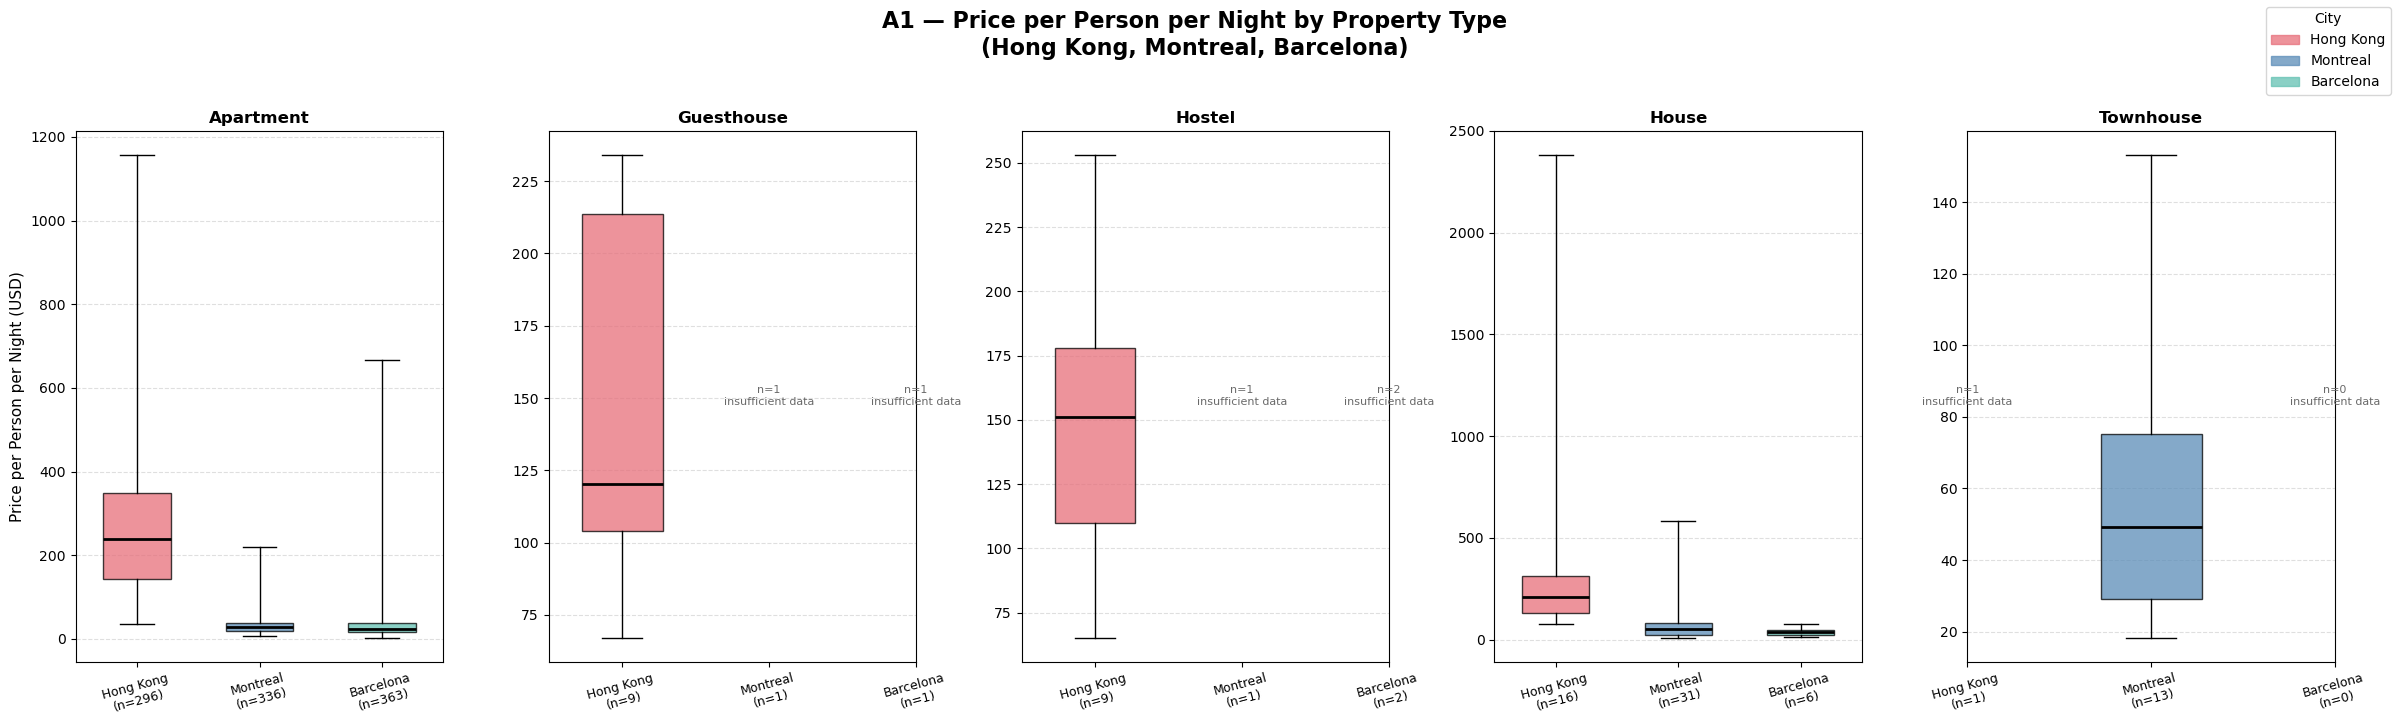

In [50]:
city_colors = {
    "Hong Kong": "#E76F7A",
    "Montreal": "#5B8DB8",
    "Barcelona": "#63C1B2"
}

fig, axes = plt.subplots(1, 5, figsize=(24, 7), sharey=False)

fig.suptitle(
    "A1 — Price per Person per Night by Property Type\n(Hong Kong, Montreal, Barcelona)",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

for ax, prop in zip(axes, property_order):
    positions = [1, 2, 3]

    for pos, city in zip(positions, cities):
        vals = df[
            (df["city"] == city) &
            (df["property_type"] == prop)
        ]["price_per_person_per_night"].dropna()

        n = len(vals)

        if n >= min_obs_boxplot:
            ax.boxplot(
                vals,
                positions=[pos],
                widths=0.55,
                patch_artist=True,
                whis=(0, 100),  # show minimum and maximum
                showfliers=True,
                medianprops=dict(color="black", linewidth=2),
                boxprops=dict(facecolor=city_colors[city], alpha=0.75),
                whiskerprops=dict(color="black", linewidth=1),
                capprops=dict(color="black", linewidth=1),
                flierprops=dict(marker="o", markersize=3, alpha=0.5)
            )
        else:
            ax.text(
                pos, 0.5, f"n={n}\ninsufficient data",
                ha="center", va="center",
                fontsize=8, color="dimgray",
                transform=ax.get_xaxis_transform()
            )

    xticklabels = [f"{city}\n(n={counts.loc[prop, city]})" for city in cities]
    ax.set_xticks(positions)
    ax.set_xticklabels(xticklabels, rotation=15, fontsize=9)

    ax.set_title(prop, fontsize=12, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    if prop == "Apartment":
        ax.set_ylabel("Price per Person per Night (USD)", fontsize=11)

legend_handles = [
    mpatches.Patch(color=city_colors[c], label=c, alpha=0.75)
    for c in cities
]
fig.legend(handles=legend_handles, loc="upper right", title="City")

plt.tight_layout()
plt.savefig("A1_price_per_person_per_night.png", dpi=150, bbox_inches="tight")
plt.show()

### A2. Query Pipeline Analysis

You will calculate the accommodation prices in New York per property type. You are only interested in those properties that have all of the following: Wifi, Hair dryer, 24-hour check-in, Air conditioning, Bed linens. 

Among the selected properties, distinguish between two categories:
    
        A. Wheelchair-friendly properties, defined as those that include at least one of the following amenities: Elevator, Ground floor access, Wheelchair accessible, Wide doorway, Disabled parking spot; 
        B. Family-friendly properties, defined as those that include at least one of the following amenities: Crib, Family/kid friendly, Stair gates, Table corner guards.

Assume that three people will stay for one week. Based on this assumption, the aggregation pipeline should calculate the price per person per night, including any additional charges such as cleaning fee, extra person fee, child fee, or other applicable fees. Calculate the prices for both groups of properties, and both customer categories (wheelchair-, and child-friendly). Transform the output into easy-to-read comparison table.

Create visual with box plots for five most numerous property types for each category (wheelchair- and family-friendly cases side-by-side) on x-axis, and range of prices per person per night on y-axis. Include Median, interquartile range (50% of cases), min/max, outliers.

As this query will be regularly run on this subset, use 'explain' function, to analyse which sequence of pipeline stages, indexes (if any), and any other methods improve your query performance. Output a table with metrics like execution time, docs examined, keys examined, stage, memory, etc to compare raw pipeline query and improved query after you apply different methods to optimize it.

The delivered assignment should have three components: 1. any assumptions and decisions made at the beginning, e.g. data interpretation. 2. visual with 10 box plots (5 types * 2 categories). 3. table with comparison metrics of before and after query performance. 4. result analysis and interpretation (max 200 words).


#### Analysis parameters

In [51]:
required_amenities = ["Wifi", "Hair dryer", "24-hour check-in", "Air conditioning", "Bed linens"]

wheelchair_amenities = [
    "Elevator",
    "Ground floor access",
    "Wheelchair accessible",
    "Wide doorway",
    "Disabled parking spot"
]

family_amenities = [
    "Crib",
    "Family/kid friendly",
    "Stair gates",
    "Table corner guards"
]

# Minimum number of observations required to draw a reliable boxplot
min_obs_boxplot = 5

In [52]:
pipeline_a2 = [
    {
        # Keep only New York listings with all required amenities and a valid price
        "$match": {
            "address.market": "New York",
            "amenities": {"$all": required_amenities},
            "price": {"$exists": True, "$ne": None}
        }
    },
    {
        # Convert monetary and capacity fields to numeric format
        "$addFields": {
            "price_num": {"$toDouble": "$price"},
            "cleaning_num": {
                "$toDouble": {
                    "$ifNull": ["$cleaning_fee", 0]
                }
            },
            "extra_num": {
                "$toDouble": {
                    "$ifNull": ["$extra_people", 0]
                }
            },
            "guests_inc": {
                "$toInt": {
                    "$ifNull": ["$guests_included", 1]
                }
            }
        }
    },
    {
        # Exclude listings with invalid base price
        "$match": {
            "price_num": {"$gt": 0}
        }
    },
    {
        # Identify whether each listing belongs to the wheelchair-friendly
        # and/or family-friendly category
        "$addFields": {
            "is_wheelchair": {
                "$gt": [
                    {
                        "$size": {
                            "$setIntersection": ["$amenities", wheelchair_amenities]
                        }
                    },
                    0
                ]
            },
            "is_family": {
                "$gt": [
                    {
                        "$size": {
                            "$setIntersection": ["$amenities", family_amenities]
                        }
                    },
                    0
                ]
            }
        }
    },
    {
        # Compute the number of extra guests beyond included capacity
        "$addFields": {
            "extra_guests": {
                "$max": [0, {"$subtract": [3, "$guests_inc"]}]
            }
        }
    },
    {
        # Compute total cost for a 7-night stay for 3 guests
        "$addFields": {
            "total_cost": {
                "$add": [
                    {"$multiply": ["$price_num", 7]},
                    "$cleaning_num",
                    {"$multiply": ["$extra_num", "$extra_guests", 7]}
                ]
            }
        }
    },
    {
        # Convert total stay cost into price per person per night
        "$addFields": {
            "price_per_person_per_night": {
                "$divide": ["$total_cost", 21]
            }
        }
    },
    {
        # Keep only the variables needed for downstream analysis
        "$project": {
            "_id": 0,
            "property_type": 1,
            "is_wheelchair": 1,
            "is_family": 1,
            "price_per_person_per_night": 1
        }
    }
]

In [53]:
results_a2 = list(collection.aggregate(pipeline_a2))
df_a2 = pd.DataFrame(results_a2)

print(f"Total filtered listings: {len(df_a2)}")
df_a2.head()

Total filtered listings: 26


,property_type,is_wheelchair,is_family,price_per_person_per_night
0,Loft,False,False,39.047619
1,Apartment,False,False,26.238095
2,Apartment,False,False,27.571429
3,Apartment,True,True,36.190476
4,Apartment,False,True,28.666667


In [54]:
# Keep only listings that belong to at least one of the two analysis categories
df_plot_a2 = df_a2[
    (df_a2["is_wheelchair"] == True) | (df_a2["is_family"] == True)
].copy()

print(f"Listings used for A2 analysis: {len(df_plot_a2)}")
df_plot_a2.head()

Listings used for A2 analysis: 19


,property_type,is_wheelchair,is_family,price_per_person_per_night
3,Apartment,True,True,36.190476
4,Apartment,False,True,28.666667
5,Apartment,True,True,56.333333
6,Apartment,False,True,34.047619
7,Apartment,True,False,41.000000


In [55]:
print("Listings by category in the analysis subset:")
print(f"Wheelchair-friendly: {df_plot_a2['is_wheelchair'].sum()}")
print(f"Family-friendly: {df_plot_a2['is_family'].sum()}")
print(f"Belonging to both categories: {(df_plot_a2['is_wheelchair'] & df_plot_a2['is_family']).sum()}")

print("\nProperty type counts in the analysis subset:")
print(df_plot_a2["property_type"].value_counts())

Listings by category in the analysis subset:
Wheelchair-friendly: 7
Family-friendly: 17
Belonging to both categories: 5

Property type counts in the analysis subset:
property_type
Apartment    17
Townhouse     1
House         1
Name: count, dtype: int64


#### Top property types in filtered subset

In [56]:
top5_property_types = df_plot_a2["property_type"].value_counts().head(5).index.tolist()

print("Top property types in the analysis subset:")
print(top5_property_types)

Top property types in the analysis subset:
['Apartment', 'Townhouse', 'House']


In [57]:
# Create comparison table for top property types and the two analysis categories

comparison_rows = []

category_map = {
    "wheelchair": "is_wheelchair",
    "family": "is_family"
}

for prop in top5_property_types:
    for cat_label, cat_col in category_map.items():
        subset = df_plot_a2[
            (df_plot_a2["property_type"] == prop) &
            (df_plot_a2[cat_col] == True)
        ]["price_per_person_per_night"].dropna()

        comparison_rows.append({
            "property_type": prop,
            "category": cat_label,
            "count": len(subset),
            "median_price": round(subset.median(), 2) if len(subset) > 0 else None,
            "mean_price": round(subset.mean(), 2) if len(subset) > 0 else None,
            "min_price": round(subset.min(), 2) if len(subset) > 0 else None,
            "max_price": round(subset.max(), 2) if len(subset) > 0 else None
        })

comparison_table_a2 = pd.DataFrame(comparison_rows)
comparison_table_a2.sort_values(by=["property_type", "category"], inplace=True)

comparison_table_a2

,property_type,category,count,median_price,mean_price,min_price,max_price
1,Apartment,family,16,59.52,63.49,28.67,154.90
0,Apartment,wheelchair,6,60.02,57.66,36.19,79.67
5,House,family,1,120.62,120.62,120.62,120.62
4,House,wheelchair,0,NaN,NaN,NaN,NaN
3,Townhouse,family,0,NaN,NaN,NaN,NaN
2,Townhouse,wheelchair,1,52.86,52.86,52.86,52.86


#### Overall summary table by category

In [58]:
# Create overall summary table by analysis category

overall_rows = []

category_map = {
    "wheelchair": "is_wheelchair",
    "family": "is_family"
}

for cat_label, cat_col in category_map.items():
    subset = df_plot_a2[
        df_plot_a2[cat_col] == True
    ]["price_per_person_per_night"].dropna()

    overall_rows.append({
        "category": cat_label,
        "count": len(subset),
        "median_price": round(subset.median(), 2) if len(subset) > 0 else None,
        "mean_price": round(subset.mean(), 2) if len(subset) > 0 else None,
        "min_price": round(subset.min(), 2) if len(subset) > 0 else None,
        "max_price": round(subset.max(), 2) if len(subset) > 0 else None
    })

overall_summary_table_a2 = pd.DataFrame(overall_rows)
overall_summary_table_a2

,category,count,median_price,mean_price,min_price,max_price
0,wheelchair,7,56.33,56.97,36.19,79.67
1,family,17,62.71,66.85,28.67,154.90


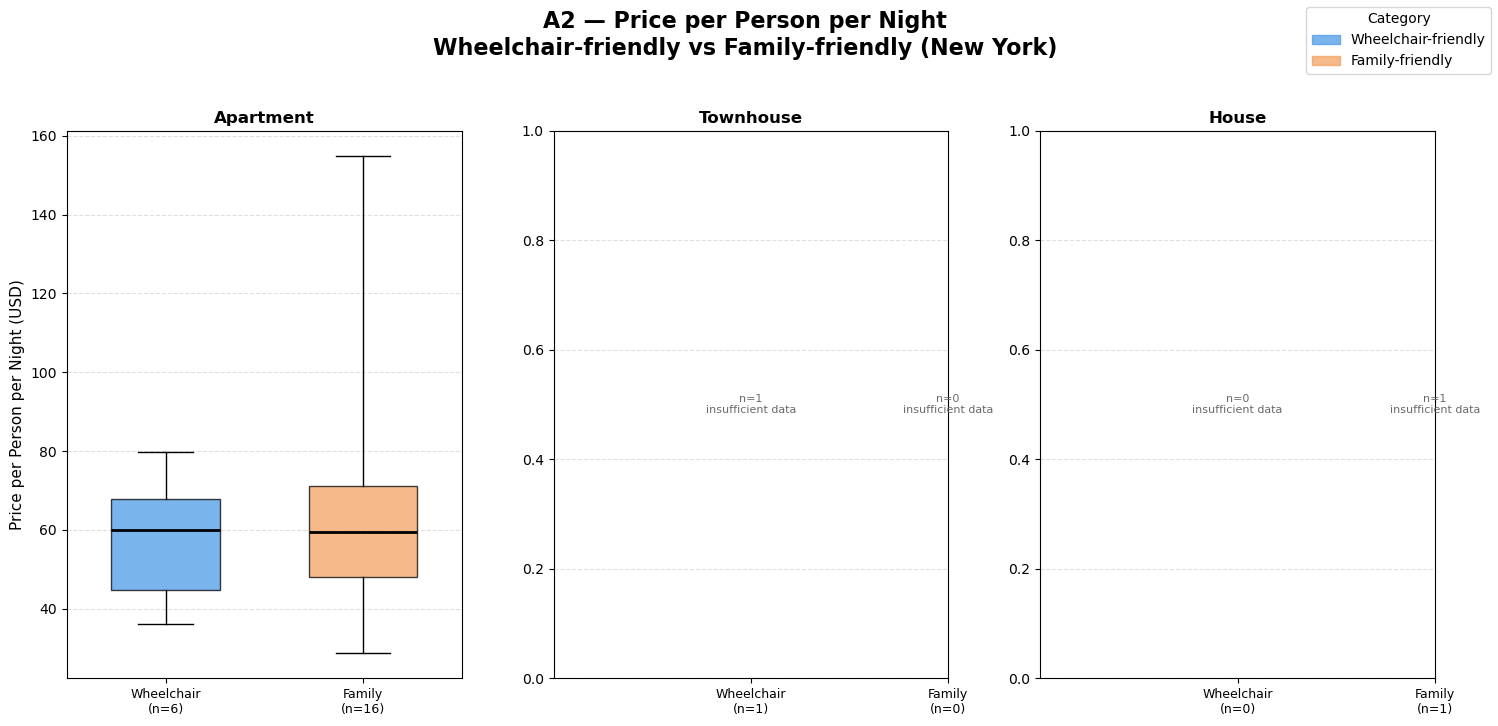

In [59]:
# Define colors for the two customer-oriented categories
category_colors = {
    "Wheelchair-friendly": "#4C9BE8",
    "Family-friendly": "#F4A261"
}

category_info = [
    ("Wheelchair-friendly", "is_wheelchair"),
    ("Family-friendly", "is_family")
]

# Create one subplot per property type
fig, axes = plt.subplots(
    1,
    len(top5_property_types),
    figsize=(5 * len(top5_property_types), 7),
    sharey=False
)

# Ensure axes is iterable when only one property type is available
if len(top5_property_types) == 1:
    axes = [axes]

fig.suptitle(
    "A2 — Price per Person per Night\nWheelchair-friendly vs Family-friendly (New York)",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

for ax, prop in zip(axes, top5_property_types):
    positions = [1, 2]

    for pos, (label, col) in zip(positions, category_info):
        vals = df_plot_a2[
            (df_plot_a2["property_type"] == prop) &
            (df_plot_a2[col] == True)
        ]["price_per_person_per_night"].dropna()

        n = len(vals)

        if n >= min_obs_boxplot:
            ax.boxplot(
                vals,
                positions=[pos],
                widths=0.55,
                patch_artist=True,
                whis=(0, 100),
                showfliers=True,
                medianprops=dict(color="black", linewidth=2),
                boxprops=dict(facecolor=category_colors[label], alpha=0.75),
                whiskerprops=dict(color="black", linewidth=1),
                capprops=dict(color="black", linewidth=1),
                flierprops=dict(marker="o", markersize=3, alpha=0.5)
            )
        else:
            ax.text(
                pos,
                0.5,
                f"n={n}\ninsufficient data",
                ha="center",
                va="center",
                fontsize=8,
                color="dimgray",
                transform=ax.get_xaxis_transform()
            )

    wheelchair_count = len(
        df_plot_a2[
            (df_plot_a2["property_type"] == prop) &
            (df_plot_a2["is_wheelchair"] == True)
        ]
    )

    family_count = len(
        df_plot_a2[
            (df_plot_a2["property_type"] == prop) &
            (df_plot_a2["is_family"] == True)
        ]
    )

    xticklabels = [
        f"Wheelchair\n(n={wheelchair_count})",
        f"Family\n(n={family_count})"
    ]

    ax.set_xticks(positions)
    ax.set_xticklabels(xticklabels, fontsize=9)
    ax.set_title(prop, fontsize=12, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    if prop == top5_property_types[0]:
        ax.set_ylabel("Price per Person per Night (USD)", fontsize=11)

# Add legend
legend_handles = [
    mpatches.Patch(color=category_colors[k], label=k, alpha=0.75)
    for k in category_colors
]
fig.legend(handles=legend_handles, loc="upper right", title="Category")

plt.tight_layout()
plt.savefig("A2_price_category_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

In [60]:
# Remove the dedicated compound index if it already exists
try:
    collection.drop_index("idx_a2_market_amenities")
except:
    pass

explain_before_dedicated_idx = db.command(
    "explain",
    {
        "aggregate": "listingsAndReviews_HW2_new",
        "pipeline": pipeline_a2,
        "cursor": {}
    },
    verbosity="executionStats"
)

explain_before_dedicated_idx

{'explainVersion': '1',
 'stages': [{'$cursor': {'queryPlanner': {'namespace': 'sample_airbnb.listingsAndReviews_HW2_new',
     'parsedQuery': {'$and': [{'address.market': {'$eq': 'New York'}},
       {'amenities': {'$eq': 'Wifi'}},
       {'amenities': {'$eq': 'Hair dryer'}},
       {'amenities': {'$eq': '24-hour check-in'}},
       {'amenities': {'$eq': 'Air conditioning'}},
       {'amenities': {'$eq': 'Bed linens'}},
       {'price': {'$exists': True}},
       {'price': {'$not': {'$eq': None}}}]},
     'indexFilterSet': False,
     'queryHash': '47B0BBB1',
     'planCacheShapeHash': '47B0BBB1',
     'planCacheKey': '7BF5FFC3',
     'optimizationTimeMillis': 5,
     'maxIndexedOrSolutionsReached': False,
     'maxIndexedAndSolutionsReached': False,
     'maxScansToExplodeReached': False,
     'prunedSimilarIndexes': False,
     'winningPlan': {'isCached': False,
      'stage': 'PROJECTION_SIMPLE',
      'transformBy': {'amenities': 1,
       'cleaning_fee': 1,
       'extra_people':

In [61]:
# Create the dedicated compound index
collection.create_index(
    [("address.market", 1), ("amenities", 1)],
    name="idx_a2_market_amenities"
)

explain_after_dedicated_idx = db.command(
    "explain",
    {
        "aggregate": "listingsAndReviews_HW2_new",
        "pipeline": pipeline_a2,
        "cursor": {}
    },
    verbosity="executionStats"
)

explain_after_dedicated_idx

{'explainVersion': '1',
 'stages': [{'$cursor': {'queryPlanner': {'namespace': 'sample_airbnb.listingsAndReviews_HW2_new',
     'parsedQuery': {'$and': [{'address.market': {'$eq': 'New York'}},
       {'amenities': {'$eq': 'Wifi'}},
       {'amenities': {'$eq': 'Hair dryer'}},
       {'amenities': {'$eq': '24-hour check-in'}},
       {'amenities': {'$eq': 'Air conditioning'}},
       {'amenities': {'$eq': 'Bed linens'}},
       {'price': {'$exists': True}},
       {'price': {'$not': {'$eq': None}}}]},
     'indexFilterSet': False,
     'queryHash': '47B0BBB1',
     'planCacheShapeHash': '47B0BBB1',
     'planCacheKey': 'A205C28A',
     'optimizationTimeMillis': 7,
     'maxIndexedOrSolutionsReached': False,
     'maxIndexedAndSolutionsReached': False,
     'maxScansToExplodeReached': False,
     'prunedSimilarIndexes': False,
     'winningPlan': {'isCached': False,
      'stage': 'PROJECTION_SIMPLE',
      'transformBy': {'amenities': 1,
       'cleaning_fee': 1,
       'extra_people':

In [62]:
def extract_performance_metrics(explain_doc):
    cursor_stage = explain_doc["stages"][0]["$cursor"]
    query_planner = cursor_stage["queryPlanner"]
    winning_plan = query_planner["winningPlan"]
    execution_stats = cursor_stage.get("executionStats", {})

    def deepest_stage(plan):
        if "inputStage" in plan:
            return deepest_stage(plan["inputStage"])
        return plan.get("stage")

    def find_ixscan(plan):
        if plan.get("stage") == "IXSCAN":
            return plan.get("indexName")
        if "inputStage" in plan:
            return find_ixscan(plan["inputStage"])
        if "inputStages" in plan:
            for subplan in plan["inputStages"]:
                result = find_ixscan(subplan)
                if result is not None:
                    return result
        return None

    return {
        "execution_time_ms": execution_stats.get("executionTimeMillis"),
        "total_docs_examined": execution_stats.get("totalDocsExamined"),
        "total_keys_examined": execution_stats.get("totalKeysExamined"),
        "winning_stage": winning_plan.get("stage"),
        "access_stage": deepest_stage(winning_plan),
        "index_used": find_ixscan(winning_plan)
    }

In [63]:
metrics_before_dedicated_idx = extract_performance_metrics(explain_before_dedicated_idx)
metrics_after_dedicated_idx = extract_performance_metrics(explain_after_dedicated_idx)

metrics_before_dedicated_idx, metrics_after_dedicated_idx

({'execution_time_ms': 6,
  'total_docs_examined': 424,
  'total_keys_examined': 426,
  'winning_stage': 'PROJECTION_SIMPLE',
  'access_stage': 'IXSCAN',
  'index_used': 'idx_listing_market_price'},
 {'execution_time_ms': 8,
  'total_docs_examined': 424,
  'total_keys_examined': 426,
  'winning_stage': 'PROJECTION_SIMPLE',
  'access_stage': 'IXSCAN',
  'index_used': 'idx_listing_market_price'})

In [64]:
performance_summary_a2 = pd.DataFrame([
    {
        "metric": "execution_time_ms",
        "before_dedicated_index": metrics_before_dedicated_idx["execution_time_ms"],
        "after_dedicated_index": metrics_after_dedicated_idx["execution_time_ms"]
    },
    {
        "metric": "total_docs_examined",
        "before_dedicated_index": metrics_before_dedicated_idx["total_docs_examined"],
        "after_dedicated_index": metrics_after_dedicated_idx["total_docs_examined"]
    },
    {
        "metric": "total_keys_examined",
        "before_dedicated_index": metrics_before_dedicated_idx["total_keys_examined"],
        "after_dedicated_index": metrics_after_dedicated_idx["total_keys_examined"]
    },
    {
        "metric": "winning_stage",
        "before_dedicated_index": metrics_before_dedicated_idx["winning_stage"],
        "after_dedicated_index": metrics_after_dedicated_idx["winning_stage"]
    },
    {
        "metric": "access_stage",
        "before_dedicated_index": metrics_before_dedicated_idx["access_stage"],
        "after_dedicated_index": metrics_after_dedicated_idx["access_stage"]
    },
    {
        "metric": "index_used",
        "before_dedicated_index": metrics_before_dedicated_idx["index_used"],
        "after_dedicated_index": metrics_after_dedicated_idx["index_used"]
    }
])

performance_summary_a2

,metric,before_dedicated_index,after_dedicated_index
0,execution_time_ms,6,8
1,total_docs_examined,424,424
2,total_keys_examined,426,426
3,winning_stage,PROJECTION_SIMPLE,PROJECTION_SIMPLE
4,access_stage,IXSCAN,IXSCAN
5,index_used,idx_listing_market_price,idx_listing_market_price


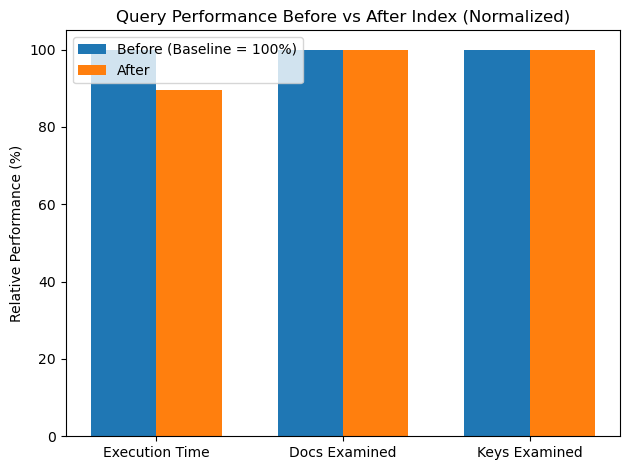

In [65]:
metrics = ['Execution Time', 'Docs Examined', 'Keys Examined']
before = [19, 424, 426]
after = [17, 424, 426]

# normalizar
after_norm = [after[i] / before[i] * 100 for i in range(len(before))]
before_norm = [100] * len(before)

x = np.arange(len(metrics))
width = 0.35

plt.figure()

plt.bar(x - width/2, before_norm, width)
plt.bar(x + width/2, after_norm, width)

plt.xticks(x, metrics)
plt.ylabel("Relative Performance (%)")
plt.title("Query Performance Before vs After Index (Normalized)")

plt.legend(["Before (Baseline = 100%)", "After"])

plt.tight_layout()
plt.savefig("a2_performance_plot.png")
plt.show()

### A3. Analytical Price Suggestion

A number of properties in the collection are missing prices. Analyse those properties, define similar properties where the price exists, and suggest a specific value to the hosts of properties without prices. You can choose to consider property type, location, host details, number of rooms and/or bathrooms, amenities, house rules, etc that indicate the type of clients that those properties attract. 

Another possible avenue to define similar properties could be to analyze the raw reviews using sentiment analysis external to mongodb (e.g. chatgpt can assess the sentiment of review text), and add additional attributes that help you define similar properties. The method and attributes you use to suggest the price is up to you. Keep a clear record of how you did it (a short description before the calculation cell).

As the result, each property that was missing a price should have a new field 'price_suggestion' with a value, all assumptions made and calculation elements considered should be listed, described, and explained clearly. 

Considering only the suggested prices, create box plots for five property types - Apartment, Guesthouse, Hostel, House, Townhouse - for Hong Kong, Montreal, and Barcelona city, mark the range of prices per person per night, make sure to include min and max prices, mark the median and the range where 50 % of prices lie. 

The delivered assignment should have three components: 1. any assumptions and decisions made at the beginning, e.g. reference properties used to estimate suggested price. 2. one graph with 15 box plots where box plots are grouped by property type (not by city). 3. result analysis and interpretation (250-350 words).

#### Count properties with missing prices

In [66]:
missing_price_count = collection.count_documents({
    "$or": [
        {"price": {"$exists": False}},
        {"price": None}
    ]
})

print(f"Properties with missing price: {missing_price_count}")

sample_missing = collection.find_one({
    "$or": [
        {"price": {"$exists": False}},
        {"price": None}
    ]
})

print("\nExample property with missing price:")
print(f"property_type: {sample_missing.get('property_type')}")
print(f"room_type: {sample_missing.get('room_type')}")
print(f"city: {sample_missing.get('address', {}).get('market')}")
print(f"price: {sample_missing.get('price')}")

Properties with missing price: 1682

Example property with missing price:
property_type: Condominium
room_type: Entire home/apt
city: Oahu
price: None


#### Compute reference prices using median by city, property type, and room type

In [67]:
pipeline_ref_lvl1 = [
    {
        "$match": {
            "price": {"$exists": True, "$ne": None},
            "address.market": {"$exists": True, "$ne": None},
            "property_type": {"$exists": True, "$ne": None},
            "room_type": {"$exists": True, "$ne": None}
        }
    },
    {
        "$addFields": {
            "price_num": {"$toDouble": "$price"}
        }
    },
    {
        "$match": {
            "price_num": {"$gt": 0}
        }
    },
    {
        "$group": {
            "_id": {
                "city": "$address.market",
                "property_type": "$property_type",
                "room_type": "$room_type"
            },
            "median_price": {
                "$median": {
                    "input": "$price_num",
                    "method": "approximate"
                }
            },
            "count": {"$sum": 1}
        }
    }
]

ref_lvl1 = list(collection.aggregate(pipeline_ref_lvl1))

ref_dict_lvl1 = {
    (r["_id"]["city"], r["_id"]["property_type"], r["_id"]["room_type"]): {
        "median_price": float(r["median_price"]),
        "count": r["count"]
    }
    for r in ref_lvl1
    if r["count"] >= 5
}

print(f"Level 1 reference groups kept (n >= 5): {len(ref_dict_lvl1)}")

Level 1 reference groups kept (n >= 5): 94


In [68]:
pipeline_ref_lvl2 = [
    {
        "$match": {
            "price": {"$exists": True, "$ne": None},
            "address.market": {"$exists": True, "$ne": None},
            "property_type": {"$exists": True, "$ne": None}
        }
    },
    {
        "$addFields": {
            "price_num": {"$toDouble": "$price"}
        }
    },
    {
        "$match": {
            "price_num": {"$gt": 0}
        }
    },
    {
        "$group": {
            "_id": {
                "city": "$address.market",
                "property_type": "$property_type"
            },
            "median_price": {
                "$median": {
                    "input": "$price_num",
                    "method": "approximate"
                }
            },
            "count": {"$sum": 1}
        }
    }
]

ref_lvl2 = list(collection.aggregate(pipeline_ref_lvl2))

ref_dict_lvl2 = {
    (r["_id"]["city"], r["_id"]["property_type"]): {
        "median_price": float(r["median_price"]),
        "count": r["count"]
    }
    for r in ref_lvl2
    if r["count"] >= 5
}

print(f"Level 2 reference groups kept (n >= 5): {len(ref_dict_lvl2)}")

Level 2 reference groups kept (n >= 5): 77


In [69]:
pipeline_ref_lvl3 = [
    {
        "$match": {
            "price": {"$exists": True, "$ne": None},
            "address.market": {"$exists": True, "$ne": None}
        }
    },
    {
        "$addFields": {
            "price_num": {"$toDouble": "$price"}
        }
    },
    {
        "$match": {
            "price_num": {"$gt": 0}
        }
    },
    {
        "$group": {
            "_id": {
                "city": "$address.market"
            },
            "median_price": {
                "$median": {
                    "input": "$price_num",
                    "method": "approximate"
                }
            },
            "count": {"$sum": 1}
        }
    }
]

ref_lvl3 = list(collection.aggregate(pipeline_ref_lvl3))

ref_dict_lvl3 = {
    r["_id"]["city"]: {
        "median_price": float(r["median_price"]),
        "count": r["count"]
    }
    for r in ref_lvl3
    if r["count"] >= 5
}

print(f"Level 3 reference groups kept (n >= 5): {len(ref_dict_lvl3)}")

Level 3 reference groups kept (n >= 5): 12


#### Assign price suggestions to properties with missing prices

In [70]:
collection.update_many(
    {},
    {
        "$unset": {
            "price_suggestion": "",
            "imputation_level": "",
            "reference_group_size": ""
        }
    }
)

print("Previous imputation fields removed.")

Previous imputation fields removed.


In [71]:
from pymongo import UpdateOne
from collections import Counter

docs_missing = list(collection.find({
    "$or": [
        {"price": {"$exists": False}},
        {"price": None}
    ]
}))

bulk_ops_a3 = []
used_levels = []

for doc in docs_missing:
    city = doc.get("address", {}).get("market")
    property_type = doc.get("property_type")
    room_type = doc.get("room_type")

    suggestion = None
    level_used = None
    reference_count = None

    key_lvl1 = (city, property_type, room_type)
    key_lvl2 = (city, property_type)

    if key_lvl1 in ref_dict_lvl1:
        suggestion = ref_dict_lvl1[key_lvl1]["median_price"]
        reference_count = ref_dict_lvl1[key_lvl1]["count"]
        level_used = "L1_city_property_room"

    elif key_lvl2 in ref_dict_lvl2:
        suggestion = ref_dict_lvl2[key_lvl2]["median_price"]
        reference_count = ref_dict_lvl2[key_lvl2]["count"]
        level_used = "L2_city_property"

    elif city in ref_dict_lvl3:
        suggestion = ref_dict_lvl3[city]["median_price"]
        reference_count = ref_dict_lvl3[city]["count"]
        level_used = "L3_city"

    if suggestion is not None:
        bulk_ops_a3.append(
            UpdateOne(
                {"_id": doc["_id"]},
                {
                    "$set": {
                        "price_suggestion": round(suggestion, 2),
                        "imputation_level": level_used,
                        "reference_group_size": reference_count
                    }
                }
            )
        )
        used_levels.append(level_used)

if bulk_ops_a3:
    result = collection.bulk_write(bulk_ops_a3)
    print(f"Documents updated: {result.modified_count}")
else:
    print("No documents were updated.")

print(f"Total missing-price documents found: {len(docs_missing)}")
print(f"Total suggestions prepared: {len(bulk_ops_a3)}")
print("Imputation levels used:")
print(Counter(used_levels))

Documents updated: 1678
Total missing-price documents found: 1682
Total suggestions prepared: 1678
Imputation levels used:
Counter({'L1_city_property_room': 1529, 'L3_city': 89, 'L2_city_property': 60})


#### Extract suggested-price subset for the required cities and property types

In [72]:
cities = ["Hong Kong", "Montreal", "Barcelona"]
property_order = ["Apartment", "Guesthouse", "Hostel", "House", "Townhouse"]

pipeline_a3 = [
    {
        "$match": {
            "address.market": {"$in": cities},
            "property_type": {"$in": property_order},
            "price_suggestion": {"$exists": True, "$ne": None}
        }
    },
    {
        "$addFields": {
            "price_per_person_per_night": {
                "$divide": [
                    {"$multiply": ["$price_suggestion", 7]},
                    21
                ]
            }
        }
    },
    {
        "$project": {
            "_id": 0,
            "city": "$address.market",
            "property_type": 1,
            "room_type": 1,
            "price_suggestion": 1,
            "price_per_person_per_night": 1,
            "imputation_level": 1,
            "reference_group_size": 1
        }
    }
]

results_a3 = list(collection.aggregate(pipeline_a3))
df_a3 = pd.DataFrame(results_a3)

print(f"Total suggested-price documents in analysis subset: {len(df_a3)}")
df_a3.head()

Total suggested-price documents in analysis subset: 489


,property_type,room_type,imputation_level,price_suggestion,reference_group_size,price_per_person_per_night,city
0,Apartment,Private room,L1_city_property_room,36.0,179,12.000000,Barcelona
1,Apartment,Entire home/apt,L1_city_property_room,91.0,183,30.333333,Barcelona
2,Apartment,Entire home/apt,L1_city_property_room,91.0,183,30.333333,Barcelona
3,Apartment,Entire home/apt,L1_city_property_room,91.0,183,30.333333,Barcelona
4,Apartment,Private room,L1_city_property_room,36.0,179,12.000000,Barcelona


#### Count observations by property type and city

In [73]:
counts_a3 = (
    df_a3.groupby(["property_type", "city"])
         .size()
         .unstack(fill_value=0)
         .reindex(index=property_order, columns=cities, fill_value=0)
)

print("Suggested-price observations by property type and city:")
print(counts_a3)

Suggested-price observations by property type and city:
city           Hong Kong  Montreal  Barcelona
property_type                                
Apartment            148       130        171
Guesthouse             3         1          1
Hostel                 3         1          1
House                 10        13          2
Townhouse              0         4          1


In [74]:
print("\nImputation levels in analysis subset:")
print(df_a3["imputation_level"].value_counts(dropna=False))

print("\nReference group size summary:")
print(df_a3["reference_group_size"].describe())


Imputation levels in analysis subset:
imputation_level
L1_city_property_room    476
L2_city_property           8
L3_city                    5
Name: count, dtype: int64

Reference group size summary:
count    489.000000
mean     163.335378
std       67.186842
min        6.000000
25%      118.000000
50%      179.000000
75%      183.000000
max      464.000000
Name: reference_group_size, dtype: float64


#### Boxplot for suggested prices

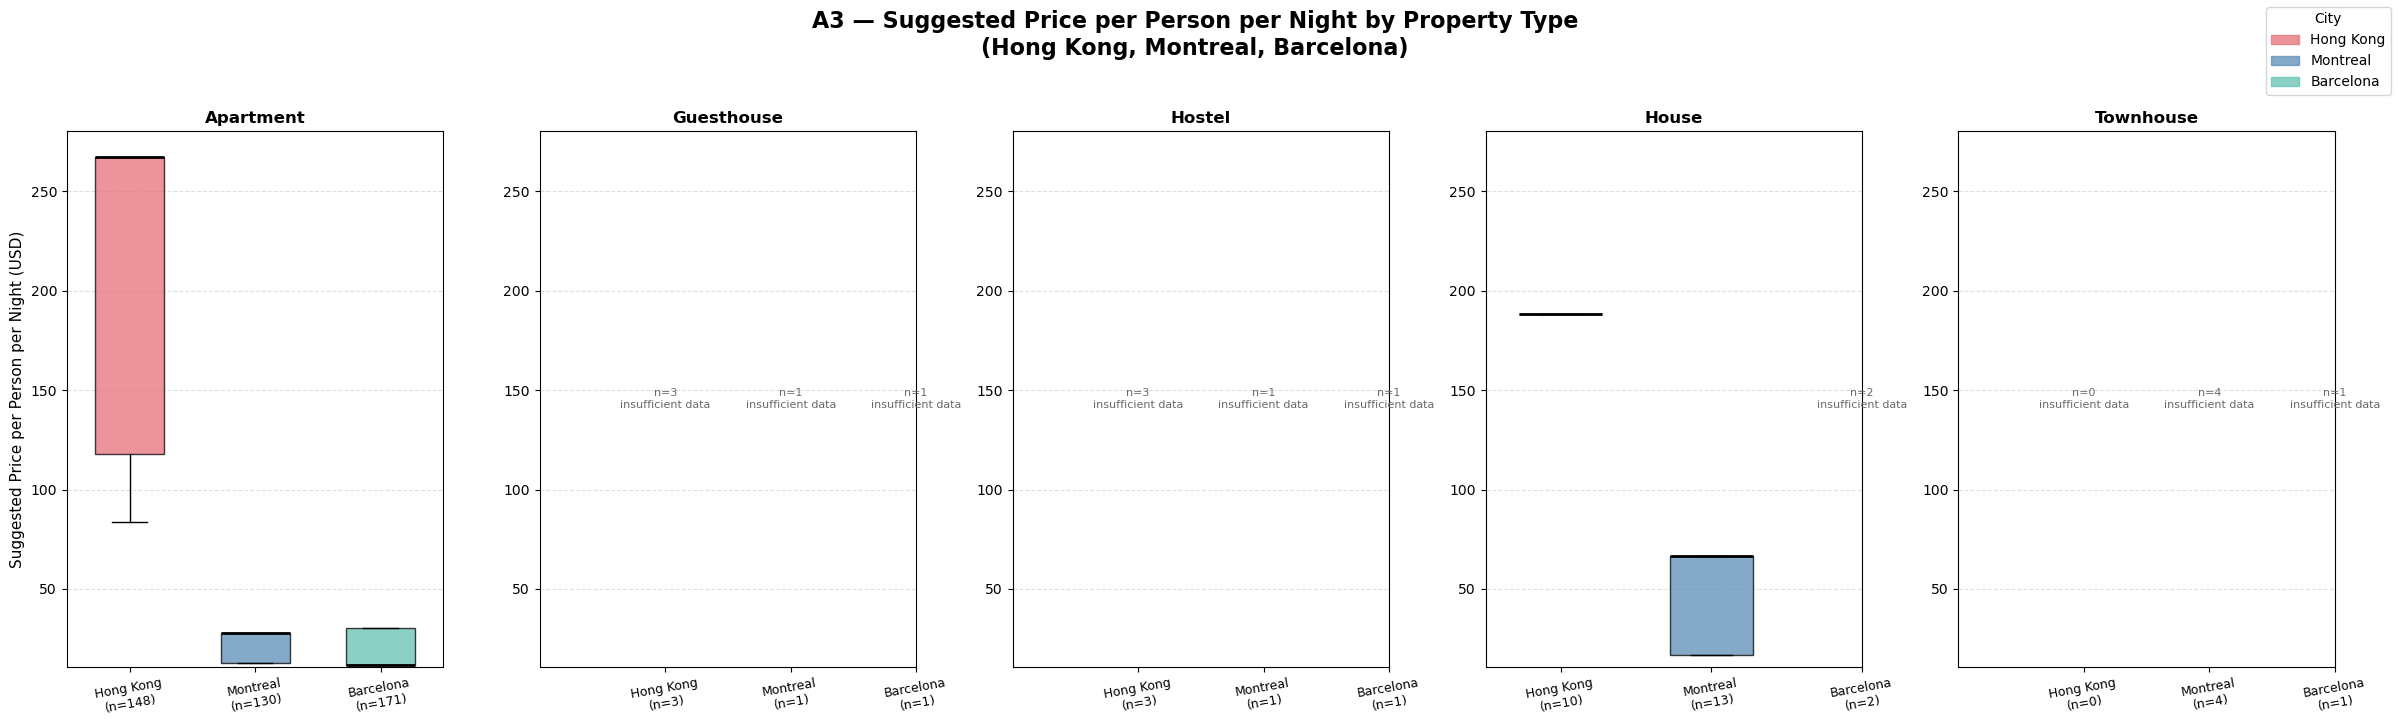

In [75]:
city_colors = {
    "Hong Kong": "#E76F7A",
    "Montreal": "#5B8DB8",
    "Barcelona": "#63C1B2"
}

min_obs_boxplot = 5

fig, axes = plt.subplots(1, 5, figsize=(24, 7), sharey=False)

fig.suptitle(
    "A3 — Suggested Price per Person per Night by Property Type\n(Hong Kong, Montreal, Barcelona)",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

all_vals = df_a3["price_per_person_per_night"].dropna()
global_ymin = all_vals.min() * 0.9
global_ymax = all_vals.max() * 1.05

for ax, prop in zip(axes, property_order):
    positions = [1, 2, 3]

    for pos, city in zip(positions, cities):
        vals = df_a3[
            (df_a3["city"] == city) &
            (df_a3["property_type"] == prop)
        ]["price_per_person_per_night"].dropna()

        n = len(vals)

        if n >= min_obs_boxplot:
            ax.boxplot(
                vals,
                positions=[pos],
                widths=0.55,
                patch_artist=True,
                whis=(0, 100),
                showfliers=True,
                medianprops=dict(color="black", linewidth=2),
                boxprops=dict(facecolor=city_colors[city], alpha=0.75),
                whiskerprops=dict(color="black", linewidth=1),
                capprops=dict(color="black", linewidth=1),
                flierprops=dict(marker="o", markersize=3, alpha=0.5)
            )
        else:
            ax.text(
                pos,
                0.5,
                f"n={n}\ninsufficient data",
                ha="center",
                va="center",
                fontsize=8,
                color="dimgray",
                transform=ax.get_xaxis_transform()
            )

    xticklabels = []
    for city in cities:
        n_city = len(
            df_a3[
                (df_a3["city"] == city) &
                (df_a3["property_type"] == prop)
            ]
        )
        xticklabels.append(f"{city}\n(n={n_city})")

    ax.set_xticks(positions)
    ax.set_xticklabels(xticklabels, fontsize=9, rotation=10)
    ax.set_title(prop, fontsize=12, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_ylim(global_ymin, global_ymax)

    if prop == property_order[0]:
        ax.set_ylabel("Suggested Price per Person per Night (USD)", fontsize=11)

legend_handles = [
    mpatches.Patch(color=city_colors[city], label=city, alpha=0.75)
    for city in cities
]
fig.legend(handles=legend_handles, loc="upper right", title="City")

plt.tight_layout()
plt.savefig("A3_suggested_price_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

In [76]:
print(df_a3[["price_suggestion", "price_per_person_per_night"]].describe())

       price_suggestion  price_per_person_per_night
count        489.000000                  489.000000
mean         249.137014                   83.045671
std          285.750119                   95.250040
min           36.000000                   12.000000
25%           38.000000                   12.666667
50%           91.000000                   30.333333
75%          353.000000                  117.666667
max          801.000000                  267.000000


In [77]:
df_a3.sort_values("price_per_person_per_night", ascending=False)[
    ["city", "property_type", "room_type", "price_suggestion", "price_per_person_per_night", "imputation_level", "reference_group_size"]
].head(10)

,city,property_type,room_type,price_suggestion,price_per_person_per_night,imputation_level,reference_group_size
279,Hong Kong,Apartment,Entire home/apt,801.0,267.0,L1_city_property_room,167
211,Hong Kong,Apartment,Entire home/apt,801.0,267.0,L1_city_property_room,167
184,Hong Kong,Apartment,Entire home/apt,801.0,267.0,L1_city_property_room,167
312,Hong Kong,Apartment,Entire home/apt,801.0,267.0,L1_city_property_room,167
313,Hong Kong,Apartment,Entire home/apt,801.0,267.0,L1_city_property_room,167
183,Hong Kong,Apartment,Entire home/apt,801.0,267.0,L1_city_property_room,167
215,Hong Kong,Apartment,Entire home/apt,801.0,267.0,L1_city_property_room,167
217,Hong Kong,Apartment,Entire home/apt,801.0,267.0,L1_city_property_room,167
294,Hong Kong,Apartment,Entire home/apt,801.0,267.0,L1_city_property_room,167
314,Hong Kong,Apartment,Entire home/apt,801.0,267.0,L1_city_property_room,167


## 6.2 B. Rating Analytics Expert

### B1. Score Analysis

Analyse the following rating categories of properties in three cities: Hong Kong, Montreal, and Barcelona: review_scores_cleanliness, review_scores_accuracy, review_scores_communication, review_scores_location, and review_scores_value.

Create box plots for each rating category across the three cities, making sure to include minimum and maximum values, the median score, and the range where 50% of the scores lie. Each box plot should represent one rating category in one city. The result should be one graph with the fifteen box plots, where each box plot corresponds to a rating category and contains the distributions for the three cities side by side for comparison.

Write a result interpretation, highlighting patterns such as differences in median scores between cities, variability within each rating category, and any notable outliers. Discuss potential reasons for the observed trends and how the rating distributions compare across the cities.

The delivered assignment should have three components: 1. any assumptions and decisions made at the beginning. 2. one graph with 15 box plots where box plots are grouped by rating category (not by city). 3. result analysis and interpretation (250-350 words).

In [ ]:
# Define cities and metrics for analysis
b1_cities  = ["Hong Kong", "Montreal", "Barcelona"]
b1_metrics = [
    "review_scores_cleanliness",
    "review_scores_accuracy",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
]

# Define labels and colors
metric_labels = {
    "review_scores_cleanliness": "Cleanliness",
    "review_scores_accuracy": "Accuracy",
    "review_scores_communication": "Communication",
    "review_scores_location": "Location",
    "review_scores_value": "Value",
}

city_colour = {
    "Hong Kong": "#E63946",
    "Montreal": "#2A9D8F",
    "Barcelona": "#E9C46A",
}

# Build data structure for plotting
pipeline_b1 = [
    {
        # Match listings in the 3 cities that have review_scores (exclude those without)
        "$match": {
            "address.market": {"$in": b1_cities},
            "review_scores": {"$exists": True, "$ne": None},
        }
    },
    {
        # Project only the needed fields for analysis
        "$project": {
            "city": "$address.market",
            "review_scores_cleanliness": "$review_scores.review_scores_cleanliness",
            "review_scores_accuracy": "$review_scores.review_scores_accuracy",
            "review_scores_communication": "$review_scores.review_scores_communication",
            "review_scores_location": "$review_scores.review_scores_location",
            "review_scores_value": "$review_scores.review_scores_value",
        }
    }
]

docs_b1 = list(listings.aggregate(pipeline_b1))
df_b1   = pd.DataFrame(docs_b1)

# Convert Decimal128 to float where needed
for col in b1_metrics:
    if col in df_b1.columns:
        df_b1[col] = pd.to_numeric(df_b1[col].apply(
            lambda x: float(str(x)) if x is not None else np.nan
        ), errors="coerce")

print(f"Records retrieved: {len(df_b1)}")
df_b1.groupby("city")[b1_metrics].count()

Records retrieved: 1416


,review_scores_cleanliness,review_scores_accuracy,review_scores_communication,review_scores_location,review_scores_value
city,,,,,
Barcelona,474,473,473,473,473
Hong Kong,449,449,449,449,449
Montreal,493,492,492,492,492


In [80]:
# Prepare data structure for box plots
# data[metric][city] = list of float values
data_b1 = {}
for metric in b1_metrics:
    data_b1[metric] = {}
    for city in b1_cities:
        vals = df_b1.loc[df_b1["city"] == city, metric].dropna().tolist()
        data_b1[metric][city] = vals
        print(f"  {metric_labels[metric]:20s} | {city:12s} | n={len(vals)}")

  Cleanliness          | Hong Kong    | n=449
  Cleanliness          | Montreal     | n=493
  Cleanliness          | Barcelona    | n=474
  Accuracy             | Hong Kong    | n=449
  Accuracy             | Montreal     | n=492
  Accuracy             | Barcelona    | n=473
  Communication        | Hong Kong    | n=449
  Communication        | Montreal     | n=492
  Communication        | Barcelona    | n=473
  Location             | Hong Kong    | n=449
  Location             | Montreal     | n=492
  Location             | Barcelona    | n=473
  Value                | Hong Kong    | n=449
  Value                | Montreal     | n=492
  Value                | Barcelona    | n=473


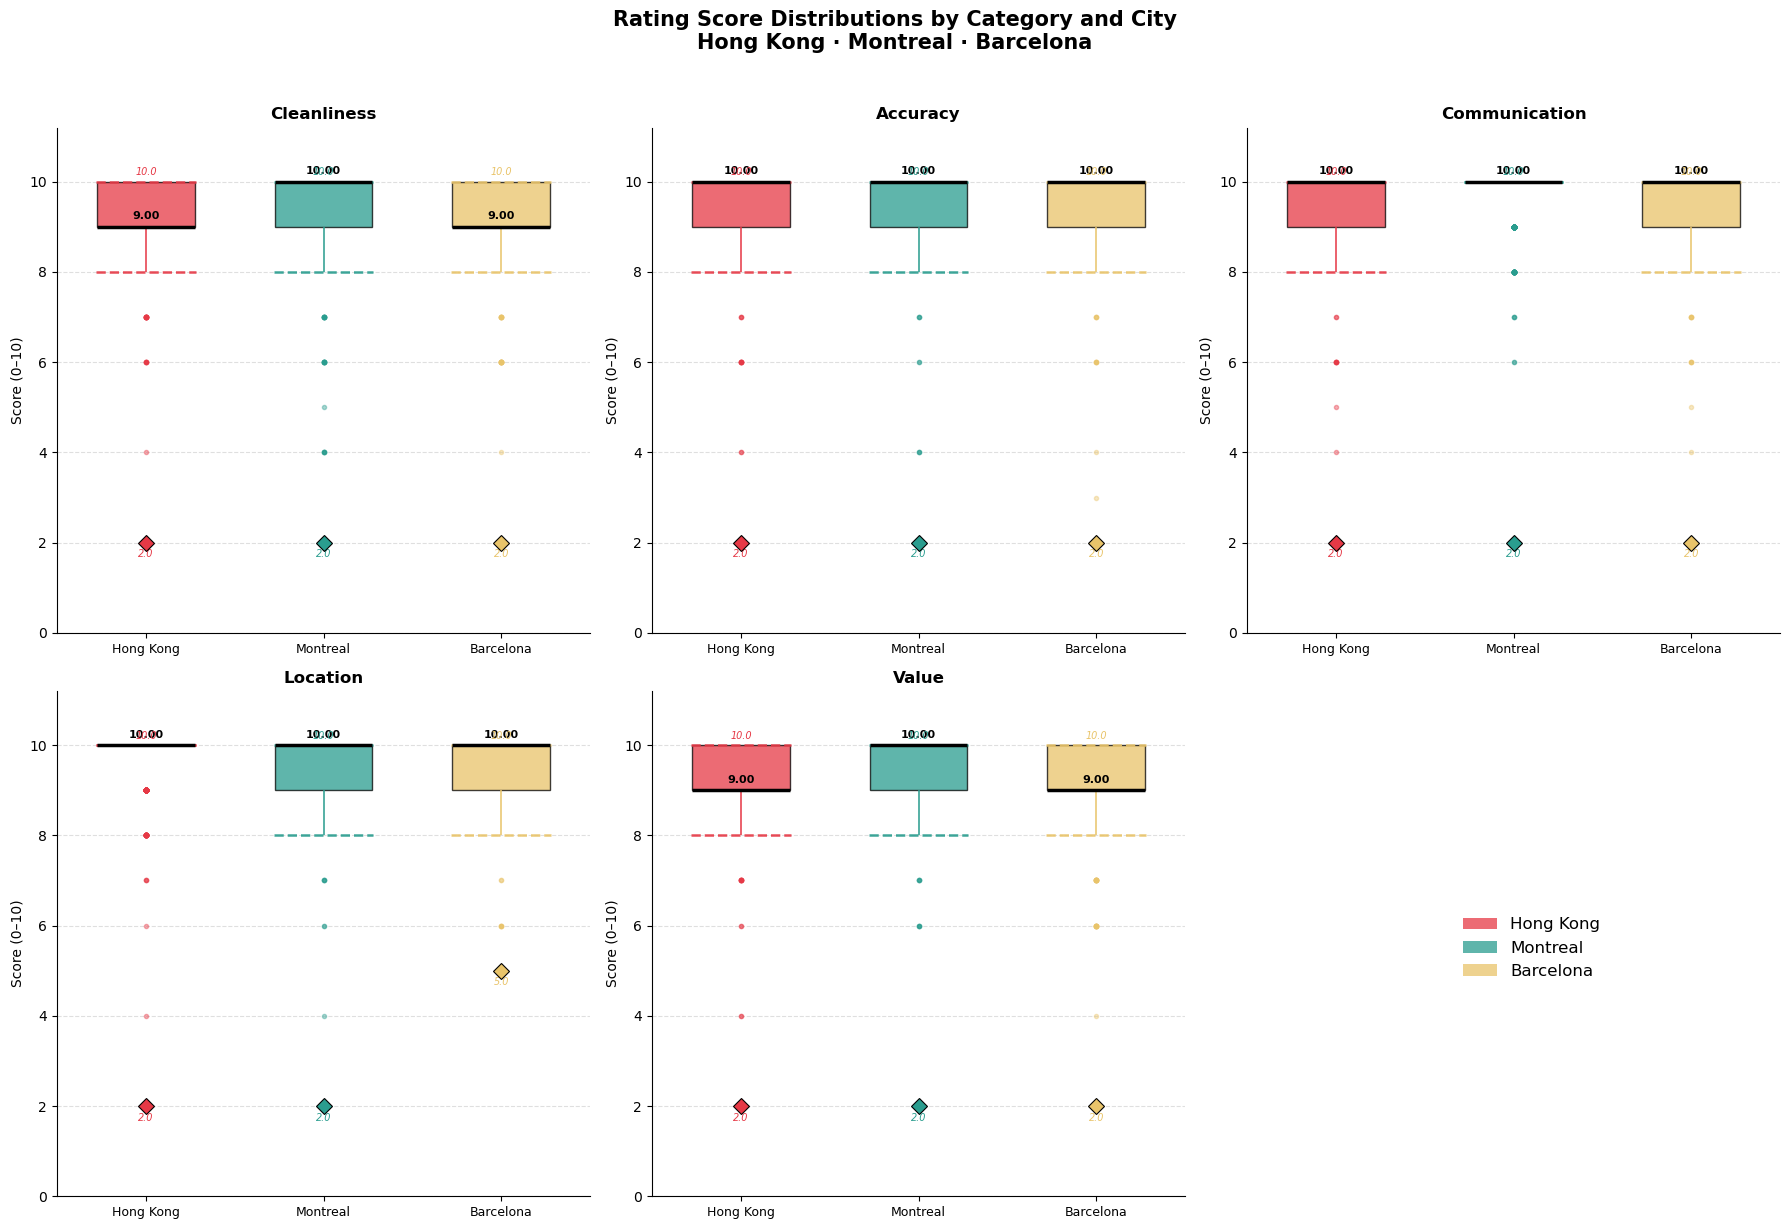

In [81]:
fig, axes_grid = plt.subplots(2, 3, figsize=(18, 12))
axes = [axes_grid[0, 0], axes_grid[0, 1], axes_grid[0, 2],
        axes_grid[1, 0], axes_grid[1, 1]]
axes_grid[1, 2].set_visible(False)

fig.suptitle(
    "Rating Score Distributions by Category and City\n"
    "Hong Kong · Montreal · Barcelona",
    fontsize=15, fontweight="bold", y=1.02
)

for ax, metric in zip(axes, b1_metrics):
    plot_data = [data_b1[metric][city] for city in b1_cities]
    colors    = [city_colour[city] for city in b1_cities]

    bp = ax.boxplot(
        plot_data,
        patch_artist=True,
        widths=0.55,
        medianprops=dict(color="black", linewidth=2.5),
        whiskerprops=dict(linewidth=0),      # hide default whiskers — drawn manually
        capprops=dict(linewidth=0),          # hide default caps — drawn manually
        flierprops=dict(marker="o", markersize=3, linestyle="none", alpha=0.4),
    )

    for i, (patch, color) in enumerate(zip(bp["boxes"], colors)):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

        vals = data_b1[metric][b1_cities[i]]
        if not vals:
            continue

        true_min   = np.min(vals)
        true_max   = np.max(vals)
        med        = np.median(vals)
        whisker_lo = bp["whiskers"][2 * i].get_ydata()[1]
        whisker_hi = bp["whiskers"][2 * i + 1].get_ydata()[1]
        verts = bp["boxes"][i].get_path().vertices
        q1    = verts[:, 1].min()   # bottom of box
        q3    = verts[:, 1].max()   # top of box
        x_pos      = i + 1

        # --- manual dashed horizontal lines at whisker positions ---
        ax.hlines(whisker_lo, x_pos - 0.28, x_pos + 0.28,
                  colors=color, linewidth=1.8, linestyles="--", alpha=0.9)
        ax.hlines(whisker_hi, x_pos - 0.28, x_pos + 0.28,
                  colors=color, linewidth=1.8, linestyles="--", alpha=0.9)

        # --- vertical whisker connectors ---
        ax.vlines(x_pos, whisker_lo, q1, colors=color, linewidth=1.4, alpha=0.8)
        ax.vlines(x_pos, q3, whisker_hi, colors=color, linewidth=1.4, alpha=0.8)

        # --- diamond at true minimum value ---
        ax.plot(x_pos, true_min, marker="D", markersize=8,
                color=color, markeredgecolor="black", markeredgewidth=0.8, zorder=5)

        # --- median label (bold, above median line) ---
        ax.text(x_pos, med + 0.12, f"{med:.2f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold", color="black")

        # --- min label below diamond ---
        ax.text(x_pos, true_min - 0.15, f"{true_min:.1f}",
                ha="center", va="top", fontsize=7, color=color, fontstyle="italic")

        # --- max label above upper whisker ---
        ax.text(x_pos, whisker_hi + 0.1, f"{whisker_hi:.1f}",
                ha="center", va="bottom", fontsize=7, color=color, fontstyle="italic")

    # flier colors
    for flier, color in zip(bp["fliers"], colors):
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor(color)

    ax.set_title(metric_labels[metric], fontsize=12, fontweight="bold")
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(b1_cities, fontsize=9)
    ax.set_ylim(0, 11.2)
    ax.set_ylabel("Score (0–10)", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

legend_patches = [
    mpatches.Patch(facecolor=city_colour[c], alpha=0.75, label=c)
    for c in b1_cities
]
fig.legend(handles=legend_patches, loc="lower right",
           ncol=1, frameon=False, fontsize=12,
           bbox_to_anchor=(0.9, 0.2))

plt.tight_layout()
plt.show()

In [82]:
vals = data_b1["review_scores_location"]["Hong Kong"]
print(f"Total values: {len(vals)}")
print(f"Value counts: {dict(sorted(collections.Counter(vals).items()))}")
print(f"Q1: {np.percentile(vals, 25)}")
print(f"Median: {np.median(vals)}")
print(f"Q3: {np.percentile(vals, 75)}")

Total values: 449
Value counts: {2.0: 1, 4.0: 1, 6.0: 1, 7.0: 3, 8.0: 28, 9.0: 74, 10.0: 341}
Q1: 10.0
Median: 10.0
Q3: 10.0


### B2. Review Quality and Activity Score

Analyse review quality and activity for each property type in New York. Only consider properties with at least 10 reviews. For each property, calculate a Review Quality and Activity Score defined as:

Score = (average overall rating) × 0.5 + (normalized review count) × 0.3 + (recency score) × 0.2
 
This metric combines review quality, popularity, and recency of activity, where: 

    Average overall rating = review_scores_rating 
    Normalized review count = property review count ÷ maximum review count within each property type group e.g. Apartment, or House.
    Recency score = number of days between the latest review in the database and the latest review of the property, scaled between 0 and 1. So that the property with the more recent review in the database will get a score of 1.

Use an aggregation pipeline to compute the Review Quality and Activity Score for each property, and property type group. Transform the output into a readable comparison table showing the score per property type. This query will be repeatedly ran every week to recalibrate the score, so take that into account when you make database and query design decisions.

Create a visual with box plots for ten most numerous property types (x-axis) to show Review Quality and Activity Score (y-axis) of each property type, with median score, min and max values, interquartile range (50% of scores) and outliers.

Use the explain function to analyse the pipeline’s performance. This query will be ran on a regular basis to keep the score relevant. Evaluate which query structures, stages, patterns, and indexes improve execution efficiency. Produce a comparison table with metrics such as execution time, documents examined, keys examined, stage type, and memory usage for before and after the improvements in query performance that you introduced.

The delivered assignment should have three components: 1. assumptions and data decisions (e.g., handling missing or incorrect data). 2. visual with box plots for ten property type. 3. comparison table of query performance before and after optimization. 4. interpretation of both results (max 200 words).

In [83]:
pipeline_b2 = [
    {
        "$match": {
            "address.market": "New York",
            "number_of_reviews": {"$gte": 10},
            "review_scores.review_scores_rating": {"$exists": True, "$ne": None},
            "last_review": {"$exists": True, "$ne": None},
        }
    },
    {
        "$project": {
            "property_type": 1,
            "number_of_reviews": 1,
            "last_review": 1,
            "rating": "$review_scores.review_scores_rating",
        }
    },
]

t0       = time.time()
raw_docs = list(listings.aggregate(pipeline_b2))
t1       = time.time()
raw_time_ms = (t1 - t0) * 1000
print(f"Raw pipeline: {len(raw_docs)} docs in {raw_time_ms:.1f} ms")

Raw pipeline: 384 docs in 16.9 ms


In [84]:
'''def get_index_name(plan):
    if isinstance(plan, dict):
        if "indexName" in plan:
            return plan["indexName"]
        if "inputStage" in plan:
            return get_index_name(plan["inputStage"])
    return None'''


def extract_metrics(label, exec_time_ms, explain_result):
    exec_stats = explain_result["executionStats"]

    winning_plan = explain_result["queryPlanner"]["winningPlan"]
    #index_name = get_index_name(winning_plan)

    return {
        "Version": label,
        "Exec Time (ms)": round(exec_time_ms, 1),
        "Docs Examined": exec_stats.get("totalDocsExamined"),
        "Keys Examined": exec_stats.get("totalKeysExamined"),
        "Returned Docs": exec_stats.get("nReturned"),
        #"Index Used": index_name,
    }

explain_raw = db.command(
    "explain",
    {"aggregate": "listingsAndReviews_HW2_new", "pipeline": pipeline_b2, "cursor": {}},
    verbosity="executionStats"
)

raw_metrics = extract_metrics("Before Optimization", raw_time_ms, explain_raw)
print("Raw metrics:")
raw_metrics

Raw metrics:


{'Version': 'Before Optimization',
 'Exec Time (ms)': 16.9,
 'Docs Examined': 607,
 'Keys Examined': 13415,
 'Returned Docs': 384}

In [85]:
listings.create_index(
    [
        ("address.market", ASCENDING),
        ("number_of_reviews", ASCENDING),
        ("last_review", DESCENDING),
        ("property_type", ASCENDING),
        ("review_scores.review_scores_rating", ASCENDING),
    ],
    name="idx_b2_ny_score"
)
print("Index created: idx_b2_ny_score")

t0       = time.time()
opt_docs = list(listings.aggregate(pipeline_b2))
t1       = time.time()
opt_time_ms = (t1 - t0) * 1000
print(f"Optimized pipeline: {len(opt_docs)} docs in {opt_time_ms:.1f} ms")

explain_opt = db.command(
    "explain",
    {"aggregate": "listingsAndReviews_HW2_new", "pipeline": pipeline_b2, "cursor": {}},
    verbosity="executionStats"
)

opt_metrics = extract_metrics("After Optimization", opt_time_ms, explain_opt)
print("Optimized metrics:")
opt_metrics

Index created: idx_b2_ny_score
Optimized pipeline: 384 docs in 8.3 ms
Optimized metrics:


{'Version': 'After Optimization',
 'Exec Time (ms)': 8.3,
 'Docs Examined': 384,
 'Keys Examined': 385,
 'Returned Docs': 384}

In [86]:
df = pd.DataFrame(opt_docs)

df["rating"] = pd.to_numeric(df["rating"].astype(str), errors="coerce")
df["review_count"] = pd.to_numeric(df["number_of_reviews"], errors="coerce")
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

df = df.dropna(subset=["rating", "last_review", "property_type"])
print(f"Records after cleaning: {len(df)}")

global_max_date = df["last_review"].max()
print(f"Global latest review date: {global_max_date.date()}")

df["days_since"] = (global_max_date - df["last_review"]).dt.days
df["recency_score"] = 1 - (df["days_since"] / df["days_since"].max())

df["max_count_in_type"] = df.groupby("property_type")["review_count"].transform("max")
df["norm_review_count"] = df["review_count"] / df["max_count_in_type"]

df["rating_norm"] = df["rating"] / 100.0

df["score"] = (
    df["rating_norm"] * 0.5 +
    df["norm_review_count"] * 0.3 +
    df["recency_score"] * 0.2
)

print("\nScore distribution:")
df["score"].describe().round(4)

Records after cleaning: 384
Global latest review date: 2019-03-05

Score distribution:


count    384.0000
mean       0.7293
std        0.0787
min        0.4301
25%        0.6849
50%        0.7145
75%        0.7661
max        0.9948
Name: score, dtype: float64

In [87]:
summary = (
    df.groupby("property_type")
    .agg(
        Count = ("score", "count"),
        Mean_Score = ("score", lambda x: round(x.mean(),   4)),
        Median_Score = ("score", lambda x: round(x.median(), 4)),
        Min_Score = ("score", lambda x: round(x.min(),    4)),
        Max_Score = ("score", lambda x: round(x.max(),    4)),
        Std_Score = ("score", lambda x: round(x.std(),    4)),
    )
    .sort_values("Count", ascending=False)
    .reset_index()
)

print("B2 – Review Quality & Activity Score per Property Type (New York):")
summary

B2 – Review Quality & Activity Score per Property Type (New York):


,property_type,Count,Mean_Score,Median_Score,Min_Score,Max_Score,Std_Score
0,Apartment,295,0.7132,0.7076,0.4301,0.9592,0.0624
1,House,34,0.8006,0.7755,0.6428,0.9945,0.0881
2,Townhouse,19,0.7570,0.7265,0.6506,0.9948,0.0806
3,Condominium,15,0.7759,0.7497,0.6152,0.9486,0.1058
4,Loft,14,0.7329,0.7250,0.5736,0.9837,0.1064
5,Guest suite,2,0.8316,0.8316,0.6760,0.9871,0.2199
6,Guesthouse,2,0.8692,0.8692,0.7550,0.9835,0.1616
7,Aparthotel,1,0.9362,0.9362,0.9362,0.9362,NaN
8,Other,1,0.9832,0.9832,0.9832,0.9832,NaN
9,Villa,1,0.8392,0.8392,0.8392,0.8392,NaN


In [88]:
type_counts = df["property_type"].value_counts()
valid_types = type_counts[type_counts >= 5].index
df_valid = df[df["property_type"].isin(valid_types)].copy()

In [89]:
def plot_clean_boxplot(df):
    import matplotlib.pyplot as plt
    import seaborn as sns

    order = (
        df.groupby("property_type")["score"]
        .median()
        .sort_values(ascending=False)
        .index
    )

    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    ax = sns.boxplot(
        data=df,
        x="property_type",
        y="score",
        order=order,
        palette="Set2",
        showfliers=True,
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )

    medians = df.groupby("property_type")["score"].median()

    for i, prop in enumerate(order):
        vals = df[df["property_type"] == prop]["score"]
        median_val = medians[prop]
        ax.text(
            i,
            median_val + 0.01,
            f"{median_val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    
    ax.set_title(
        "Review Quality & Activity Score by Property Type – New York\n"
        "Score = Rating×0.5 + Norm.Count×0.3 + Recency×0.2",
        fontsize=12
    )
    ax.set_xlabel("Property Type")
    ax.set_ylabel("Score (0–1)")

    ax.set_ylim(0, 1.1)

    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

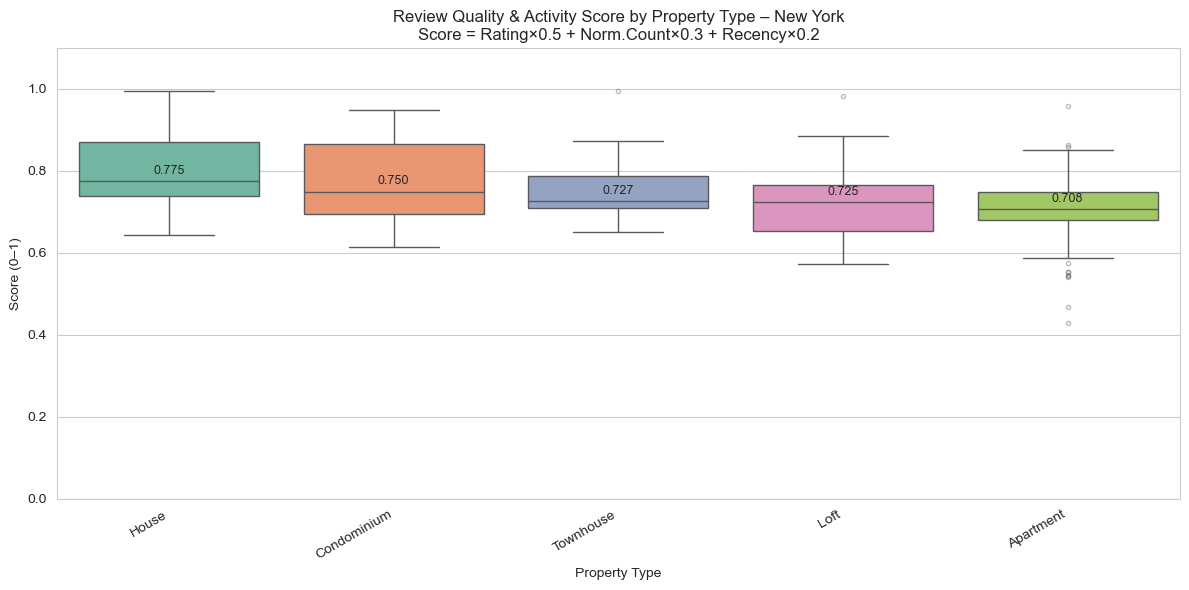

In [90]:
plot_clean_boxplot(df_valid)

In [91]:
perf_df = pd.DataFrame([raw_metrics, opt_metrics])
print("B2 – Query Performance Comparison:")
perf_df

B2 – Query Performance Comparison:


,Version,Exec Time (ms),Docs Examined,Keys Examined,Returned Docs
0,Before Optimization,16.9,607,13415,384
1,After Optimization,8.3,384,385,384


### B3. Long-Term Rental Suggestion
   
Some properties in the collection may experience periods with little or no tenant activity during the year. Using the review dates in the dataset, analyse patterns of tenant presence and identify periods when properties are likely to be unoccupied. Assume that a review is typically written shortly after a stay, therefore the presence of reviews in a given period can be used as an indicator that the property was occupied. Conversely, long gaps between reviews may indicate that the property was empty.

To make the analysis more robust, examine tenant presence separately for each year in the dataset, if more than one year review data exists. Identify periods of potential vacancy within each year and then average the results across years in order to detect recurring vacancy periods more reliably. This analytical query will be updated on the yearly basis.

Analyse these patterns and identify periods when properties appear to be vacant for an extended time. If a property has more than one consecutive month without reviews, and this pattern appears consistently across years, you should recommend that the host consider renting the property long-term during that period. Specifically, create a new field called 'rental_suggestion' that will host an array of month number suitable for long-term rental. 

Create a scatter plot to show which your long-term rental suggestions for Hong Kong, Montreal, and Barcelona. Represent the results in a scatter plot with x axis being months of the year, with y axis being number of properties available during that month, the size of the points should reflect the number of properties available during each month in each city, and finally mark each city with a different color.  

The delivered assignment should have three components: 1. any assumptions and decisions made at the beginning, e.g. assumptions about time gap calculations, any database design choices you made, etc. 2. one scatter plot for Hong Kong, Montreal, and Barcelona rental suggestions. 3. result analysis and interpretation (250-350 words).

In [92]:
B3_CITIES = ["Hong Kong", "Montreal", "Barcelona"]

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

CITY_COLORS = {
    "Hong Kong": "#E63946",
    "Montreal":  "#2A9D8F",
    "Barcelona": "#E9C46A",
}


In [93]:
city_listings = list(listings.aggregate([
    {"$match": {"address.market": {"$in": B3_CITIES}}},
    {"$project": {"city": "$address.market"}}
]))

listing_id_to_city = {doc["_id"]: doc["city"] for doc in city_listings}
all_listing_ids    = list(listing_id_to_city.keys())

print(f"Listings in selected cities: {len(all_listing_ids)}")

Listings in selected cities: 1899


In [94]:
rev_docs = list(reviews.aggregate([
    {
        "$match": {
            "listing_id": {"$in": all_listing_ids},
            "date": {"$exists": True, "$ne": None},
        }
    },
    {
        "$project": {
            "listing_id": 1,
            "year":  {"$year": "$date"},
            "month": {"$month": "$date"},
            "_id": 0,
        }
    },
]))

print(f"Review documents fetched: {len(rev_docs)}")

Review documents fetched: 40086


In [95]:
reviews_by_listing = defaultdict(list)

for doc in rev_docs:
    reviews_by_listing[doc["listing_id"]].append(
        (doc["year"], doc["month"])
    )

In [96]:
def find_consecutive_groups(months, min_length=2):
    if not months:
        return []

    months = sorted(set(months))
    extended = months + [m + 12 for m in months]

    groups = []
    group = [extended[0]]

    for m in extended[1:]:
        if m == group[-1] + 1:
            group.append(m)
        else:
            groups.append(group)
            group = [m]
    groups.append(group)

    result = set()
    for g in groups:
        if len(g) >= min_length:
            for m in g:
                result.add(((m - 1) % 12) + 1)

    return sorted(result & set(months))


def get_rental_suggestion(yr_month_list, vacancy_threshold=0.5, consec_threshold=2):

    if not yr_month_list:
        return []

    by_year = defaultdict(set)
    for yr, mo in yr_month_list:
        by_year[yr].add(mo)

    vacancy_count = defaultdict(int)
    active_years = 0

    for months in by_year.values():
        if not months:
            continue

        active_years += 1

        for mo in range(1, 13):
            if mo not in months:
                vacancy_count[mo] += 1

    if active_years == 0:
        return []

    recurring_vacant = [
        mo for mo, cnt in vacancy_count.items()
        if cnt / active_years >= vacancy_threshold
    ]

    return find_consecutive_groups(recurring_vacant, min_length=consec_threshold)

In [97]:
suggestion_map = {}

for lid in all_listing_ids:
    yr_mo = reviews_by_listing.get(lid, [])
    suggestion_map[lid] = get_rental_suggestion(yr_mo)

n_with = sum(1 for v in suggestion_map.values() if v)
print(f"Listings with rental suggestion: {n_with} / {len(all_listing_ids)}")

Listings with rental suggestion: 1127 / 1899


In [98]:
bulk_ops = [
    UpdateOne(
        {"_id": lid},
        {"$set": {"rental_suggestion": months}}
    )
    for lid, months in suggestion_map.items()
]

if bulk_ops:
    result = listings.bulk_write(bulk_ops)
    print(f"Documents updated: {result.modified_count}")

Documents updated: 1899


In [99]:
# Analyze distribution of suggested rental months by city
city_month_counts = defaultdict(lambda: defaultdict(int))

for lid, months in suggestion_map.items():
    city = listing_id_to_city.get(lid)
    if city in B3_CITIES:
        for mo in months:
            city_month_counts[city][mo] += 1

rows = []
for city in B3_CITIES:
    for mo in range(1, 13):
        rows.append({
            "city": city,
            "month": mo,
            "count": city_month_counts[city].get(mo, 0)
        })

df_b3 = pd.DataFrame(rows)

print(df_b3[df_b3["count"] > 0])

         city  month  count
0   Hong Kong      1    318
1   Hong Kong      2    313
2   Hong Kong      3    376
3   Hong Kong      4    393
4   Hong Kong      5    398
5   Hong Kong      6    391
6   Hong Kong      7    379
7   Hong Kong      8    369
8   Hong Kong      9    378
9   Hong Kong     10    352
10  Hong Kong     11    348
11  Hong Kong     12    341
12   Montreal      1    420
13   Montreal      2    430
14   Montreal      3    447
15   Montreal      4    471
16   Montreal      5    437
17   Montreal      6    405
18   Montreal      7    353
19   Montreal      8    318
20   Montreal      9    370
21   Montreal     10    398
22   Montreal     11    432
23   Montreal     12    435
24  Barcelona      1    160
25  Barcelona      2    154
26  Barcelona      3    159
27  Barcelona      4    157
28  Barcelona      5    139
29  Barcelona      6    130
30  Barcelona      7    121
31  Barcelona      8    111
32  Barcelona      9    128
33  Barcelona     10    137
34  Barcelona     11

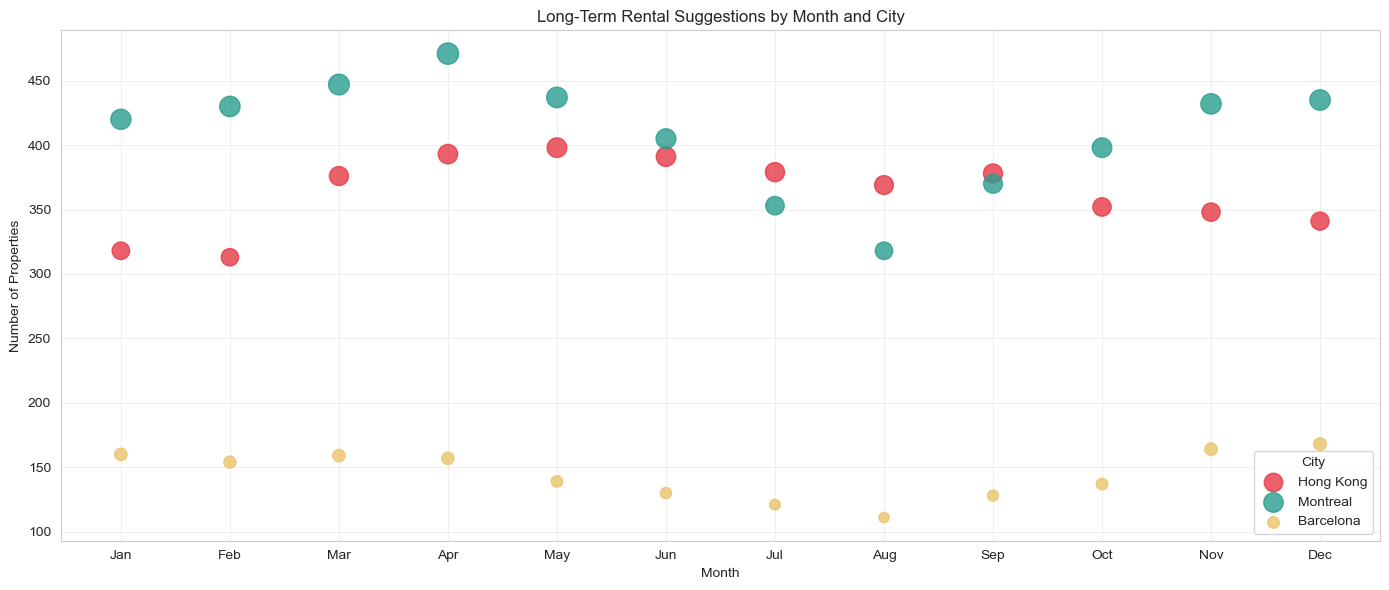

In [100]:
# Visualization of rental suggestions by month and city
fig, ax = plt.subplots(figsize=(14, 6))

for city in B3_CITIES:
    sub = df_b3[(df_b3["city"] == city) & (df_b3["count"] > 0)]
    ax.scatter(
        sub["month"],
        sub["count"],
        s=sub["count"] * 0.5,   
        color=CITY_COLORS[city],
        alpha=0.8,
        label=city
    )

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_NAMES)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Properties")
ax.set_title("Long-Term Rental Suggestions by Month and City")
ax.grid(alpha=0.3)
ax.legend(title="City")
plt.tight_layout()
plt.show()

## 6.3 C. Comfort Analytics Expert

### C1. Amenity Premium Analysis

Analyse properties in three cities: Hong Kong, Montreal, and Barcelona to determine which amenities are associated with higher prices per night. Assume two guests stay for one week when calculating the effective price per person per night, including any additional fees such as cleaning fees, extra person charges, or other applicable costs.

Examine all amenities in the dataset to identify those associated with higher price per night, excluding amenities present in all properties since they offer no variation. Each property has a single price, so analyse the statistical association between amenity presence and price. For each amenity, divide properties into two groups—those with the amenity and those without—and compare their price distributions using median price. The difference in median indicates the 'price premium' of the amenity. Are there any amenities that correlate to drop in the price?

Create box plots for all three cities with the three amenities which correlate with the price premium the most in that city. For each amenity case, create two box plots - one for properties with the amenity and one for properties without the amenity (color coded accordingly), with x-axis being amenity in each city, and y-axis being price per person per night. Make sure to include minimum and maximum prices, the median, and the range where 50% of prices lie.

The delivered assignment should have three components: 1. any assumptions and decisions made at the beginning. 2. one graph with 18 box plots (3 cities x 3 top amenities x 2 cases of with and without). 3. result analysis and interpretation (250-350 words).

In [116]:
#C1 Constants
CITIES     = ["Hong Kong", "Montreal", "Barcelona"]
NUM_GUESTS = 2
NUM_NIGHTS = 7

In [117]:
#Functions essential to C1

# MongoDB stores monetary fields (price, cleaning_fee, extra_people) as Decimal128 — a BSON type that Python cannot use directly in arithmetic.
def to_float(val):
    if val is None:
        return 0.0
    if hasattr(val, 'to_decimal'):      
        return float(val.to_decimal())
    try:
        return float(val)
    except (TypeError, ValueError):
        return 0.0
    

# HELPER FUNCTION to calculate effective price per person per night
def effective_price_pppn(doc):
    price           = to_float(doc.get("price"))
    cleaning_fee    = to_float(doc.get("cleaning_fee"))
    extra_people    = to_float(doc.get("extra_people"))   
    guests_included = doc.get("guests_included") or 1    # default to 1 if missing or 0

    # Number of our 2 guests not covered by the base price
    extra_guests = max(0, NUM_GUESTS - guests_included)

    total = (
        price * NUM_NIGHTS              # base rate for 7 nights
        + cleaning_fee                  # one-time flat fee
        + extra_guests * extra_people * NUM_NIGHTS   
    )

    return total / (NUM_GUESTS * NUM_NIGHTS)   # divide by 14 person-nights

In [118]:
city_data = {}

for city in CITIES:
    listings = list(db.listingsAndReviews_HW2_new.find(
        {"address.market": city},                      
        {"amenities": 1, "price": 1, "cleaning_fee": 1,
         "extra_people": 1, "guests_included": 1}       
    ))

    for doc in listings:
        doc["amenities"]           = [a.strip() for a in doc.get("amenities", [])]
        doc["effective_price_pppn"] = effective_price_pppn(doc)

    city_data[city] = listings
    pprint(f"{city}: {len(listings)} listings loaded")

'Hong Kong: 619 listings loaded'
'Montreal: 648 listings loaded'
'Barcelona: 632 listings loaded'


In [119]:
# Check if any amenity is universal across ALL THREE cities combined
total_all = db.listingsAndReviews_HW2_new.count_documents(
    {"address.market": {"$in": CITIES}}   # Lab 4 — $in: match any of the three cities
)

pipeline = [
    {"$match":  {"address.market": {"$in": CITIES}}},  # filter to C1 cities
    {"$unwind": "$amenities"},               
    {"$group":  {"_id": "$amenities",                  
                 "count": {"$sum": 1}}},
    {"$match":  {"count": {"$eq": total_all}}}       
]

universal_all = [doc["_id"] for doc in db.listingsAndReviews_HW2_new.aggregate(pipeline)]
print(f"Universal across ALL 3 cities combined ({total_all} listings): {len(universal_all)}")

Universal across ALL 3 cities combined (1899 listings): 0


In [120]:
# Find universal amenities per city (present in 100% of that city's listings)
city_universal = {}

for city in CITIES:
    total = db.listingsAndReviews_HW2_new.count_documents({"address.market": city})

    pipeline = [
        {"$match":  {"address.market": city}},           
        {"$unwind": "$amenities"},                         
        {"$group":  {"_id": "$amenities", "count": {"$sum": 1}}},
        {"$match":  {"count": {"$eq": total}}}              # present in all listings
    ]

    universal = [doc["_id"] for doc in db.listingsAndReviews_HW2_new.aggregate(pipeline)]
    city_universal[city] = set(universal)
    pprint(f"{city}: {len(universal)} universal amenities excluded")

'Hong Kong: 0 universal amenities excluded'
'Montreal: 0 universal amenities excluded'
'Barcelona: 0 universal amenities excluded'


In [121]:
# Get list of analysable amenities per city:

# amenities that:
#   - appear in MORE than 1 listing (count > 1)  — single-listing amenities have no 'without' group
#   - appear in FEWER than all listings (count < total)  — universal amenities excluded
#

city_amenities = {}

for city in CITIES:
    total = db.listingsAndReviews_HW2_new.count_documents({"address.market": city})

    pipeline = [
        {"$match":  {"address.market": city}},                               
        {"$unwind": "$amenities"},                                           
        {"$group":  {"_id": {"$trim": {"input": "$amenities"}},                
                     "count": {"$sum": 1}}},
        {"$match":  {"count": {"$gt": 1, "$lt": total}}}                        
    ]

    city_amenities[city] = [
        doc["_id"].strip() for doc in db.listingsAndReviews_HW2_new.aggregate(pipeline)
    ]
    pprint(f"{city}: {len(city_amenities[city])} amenities to analyse")

'Hong Kong: 106 amenities to analyse'
'Montreal: 113 amenities to analyse'
'Barcelona: 126 amenities to analyse'


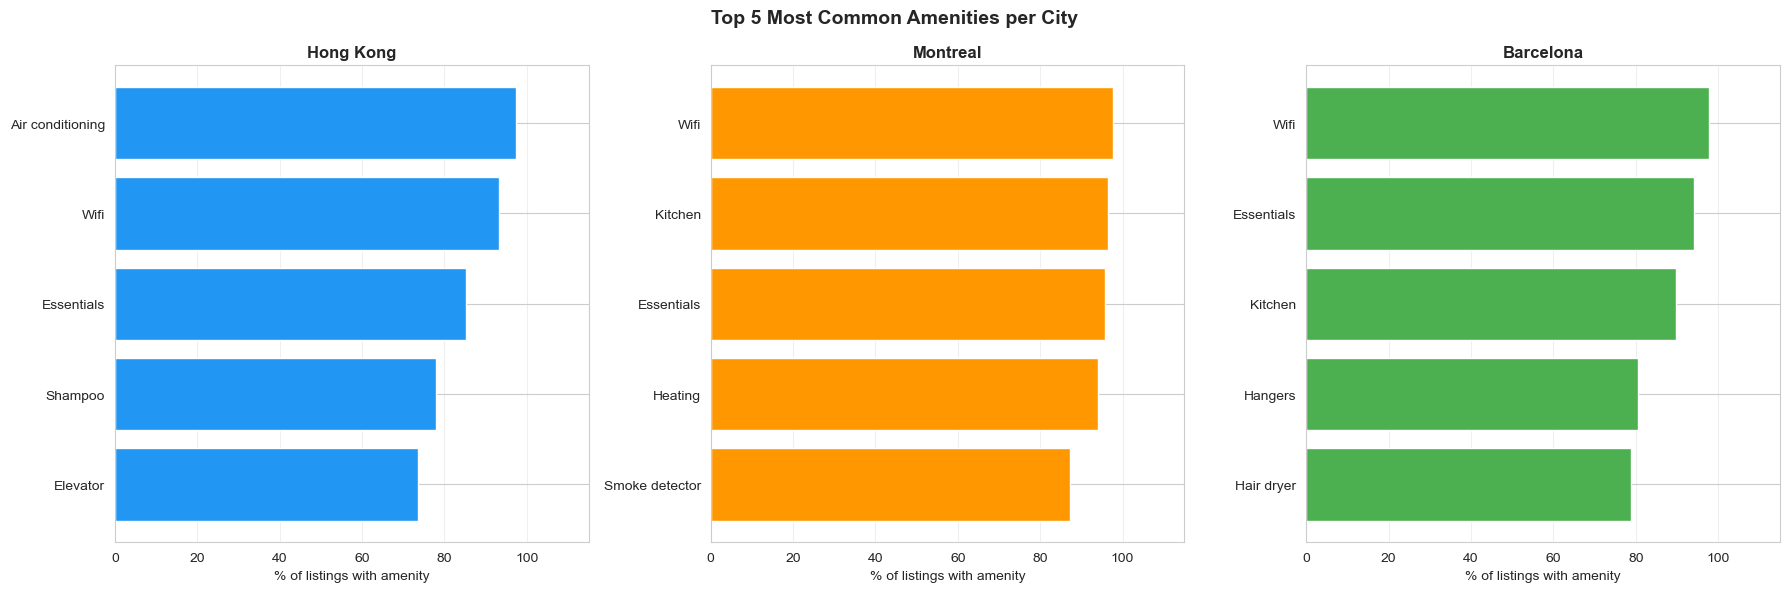

In [122]:
# 5 Most common Amenities per city

CITY_COLORS = {
    "Hong Kong": "#2196F3",   # blue
    "Montreal":  "#FF9800",   # orange
    "Barcelona": "#4CAF50"    # green
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Top 5 Most Common Amenities per City", fontsize=14, fontweight="bold")

for col, city in enumerate(CITIES):
    total = db.listingsAndReviews_HW2_new.count_documents({"address.market": city})

    pipeline = [
        {"$match":  {"address.market": city}},
        {"$unwind": "$amenities"},
        {"$group":  {"_id": {"$trim": {"input": "$amenities"}},
                     "count": {"$sum": 1}}},
        {"$sort":   {"count": -1}},          
        {"$limit":  5}                      
    ]

    results   = list(db.listingsAndReviews_HW2_new.aggregate(pipeline))
    amenities = [r["_id"] for r in results]
    counts    = [r["count"] for r in results]
    pcts      = [round((c / total) * 100, 1) for c in counts]

    ax   = axes[col]
    ax.barh(amenities, pcts, color=CITY_COLORS[city])

    ax.set_title(city, fontsize=12, fontweight="bold")
    ax.set_xlabel("% of listings with amenity")
    ax.set_xlim(0, 115)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [123]:
import statistics
from collections import defaultdict


city_premiums = {}

for city in CITIES:
    listings = city_data[city]

    # get total listings (for "not universal" filter)
    total = db.listingsAndReviews_HW2_new.count_documents({
        "address.market": city
    })

    pipeline = [
        {"$match": {"address.market": city}},          
        {"$unwind": "$amenities"},                     
        {"$group": {
            "_id": "$amenities",
            "count": {"$sum": 1}
        }},                                           
        {"$match": {
            "count": {
                "$gt": 1,        # appears in at least 2 listings
                "$lt": total     # exclude universal amenities
            }
        }},
        {"$sort": {"count": -1}}                       
    ]

    # extract amenity list
    amenities = [
        doc["_id"] for doc in
        db.listingsAndReviews_HW2_new.aggregate(pipeline)
    ]

    premiums = {}

    # median computation
    for amenity in amenities:

        with_group = [
            d["effective_price_pppn"]
            for d in listings
            if amenity in d.get("amenities", [])
        ]

        without_group = [
            d["effective_price_pppn"]
            for d in listings
            if amenity not in d.get("amenities", [])
        ]

        # Minimum sample size for reliability
        if len(with_group) < 1 or len(without_group) < 30:
            continue

        median_with    = statistics.median(with_group)
        median_without = statistics.median(without_group)

        premium = median_with - median_without

        premiums[amenity] = {
            "premium": premium,
            "median_with": median_with,
            "median_without": median_without,
            "with_prices": with_group,
            "without_prices": without_group,
            "n_with": len(with_group),
            "n_without": len(without_group)
        }

    # sort by absolute premium 
    city_premiums[city] = sorted(
        premiums.items(),
        key=lambda x: abs(x[1]["premium"]),
        reverse=True
    )


Amenities with fewer than 30 listings in either the “with” or “without” group are excluded to ensure statistical reliability. Small sample sizes can produce unstable median estimates and misleading price premiums.

>Exploratory analysis without this constraint produced highly volatile results driven by rare amenities, confirming the need for a minimum sample size filter.”

In [124]:
for city in CITIES:
    results = city_premiums[city]

    print(f"\n{'='*60}")
    print(f"  {city}")
    print(f"{'='*60}")

    print(f"\n  TOP 5 — highest price PREMIUM:")
    print(f"  {'Amenity':<40} {'Premium':>10}  {'Med(with)':>10}  {'Med(w/o)':>10}  {'n_with':>7}  {'n_without':>9}")
    print(f"  {'-'*90}")

    for amenity, s in results[:5]:
        print(f"  {amenity:<40} {'$'+str(round(s['premium'],2)):>10}  "
              f"{'$'+str(round(s['median_with'],2)):>10}  "
              f"{'$'+str(round(s['median_without'],2)):>10}  "
              f"{s['n_with']:>7}  {s['n_without']:>9}")

    print(f"\n  BOTTOM 5 — amenities correlated with price DROP:")
    print(f"  {'Amenity':<40} {'Premium':>10}  {'Med(with)':>10}  {'Med(w/o)':>10}  {'n_with':>7}  {'n_without':>9}")
    print(f"  {'-'*90}")

    for amenity, s in results[-5:]:
        print(f"  {amenity:<40} {'$'+str(round(s['premium'],2)):>10}  "
              f"{'$'+str(round(s['median_with'],2)):>10}  "
              f"{'$'+str(round(s['median_without'],2)):>10}  "
              f"{s['n_with']:>7}  {s['n_without']:>9}")


  Hong Kong

  TOP 5 — highest price PREMIUM:
  Amenity                                     Premium   Med(with)    Med(w/o)   n_with  n_without
  ------------------------------------------------------------------------------------------
  Pack ’n Play/travel crib                    $270.93     $470.93      $200.0        6        613
  Changing table                               $257.5      $457.5      $200.0        2        617
  Children’s dinnerware                       $225.29     $425.29      $200.0        8        611
  Children’s books and toys                    $198.5      $398.5      $200.0       11        608
  Buzzer/wireless intercom                     $192.5      $381.0      $188.5       51        568

  BOTTOM 5 — amenities correlated with price DROP:
  Amenity                                     Premium   Med(with)    Med(w/o)   n_with  n_without
  ------------------------------------------------------------------------------------------
  Window guards              

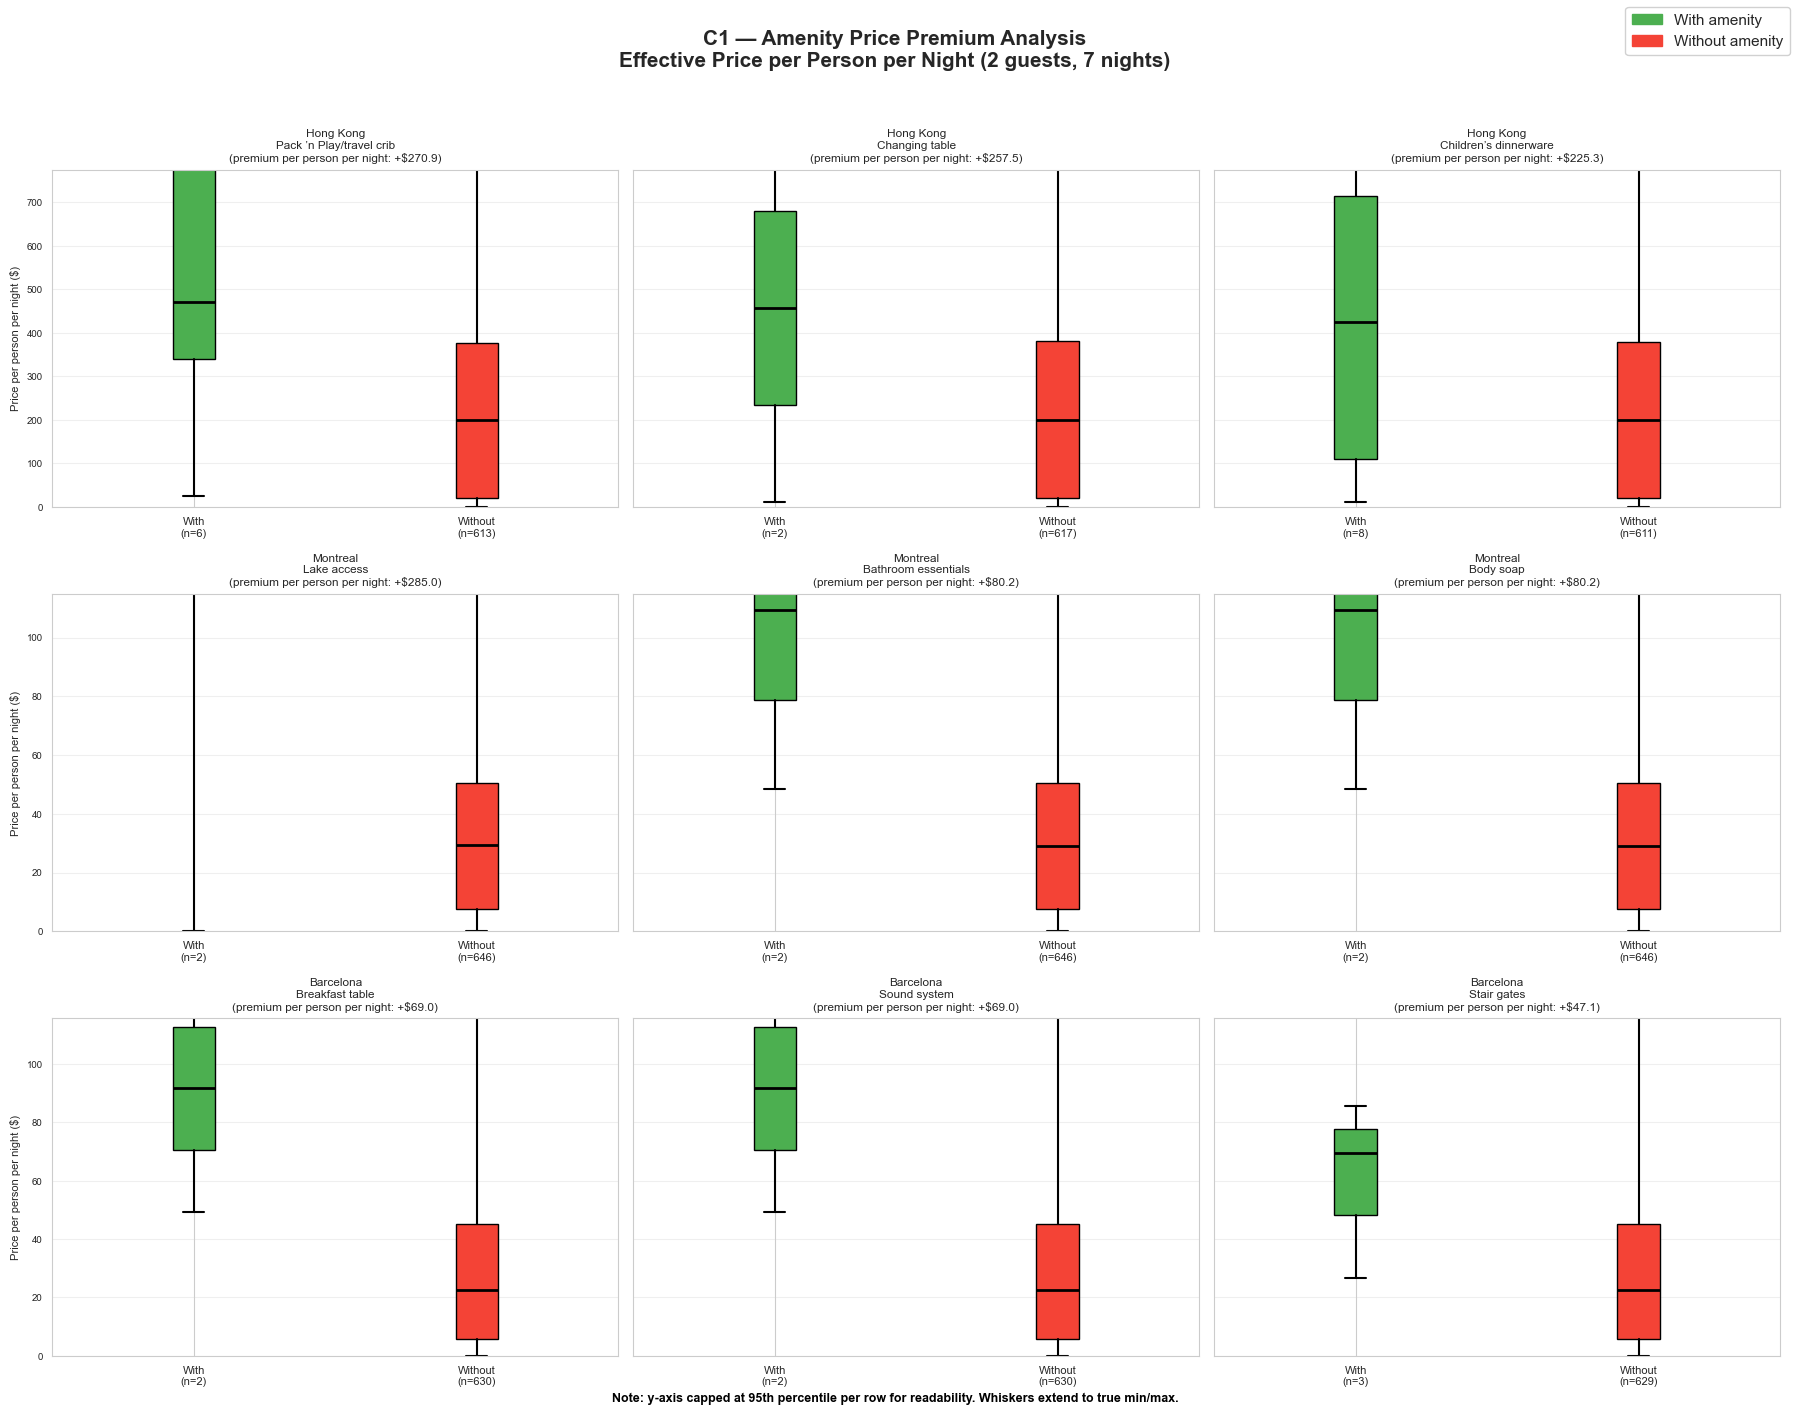

In [125]:
# Box plots: 18 total (3 cities × 3 amenities × 2 groups)
# Layout: 3 rows (one per city) × 3 columns (top 3 amenities for that city)
# Each subplot has 2 boxes: green = with amenity, red = without amenity

# whis=(0,100): whiskers extend to TRUE min and max (not 1.5×IQR)

# sharey=False: each row has its own y-axis scale because Hong Kong prices are
# much higher than Montreal/Barcelona — a shared scale would compress the lower cities

COLOR_WITH    = "#4CAF50"   # green —> with amenity
COLOR_WITHOUT = "#F44336"   # red   —> without amenity

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 14), sharey='row')

fig.suptitle(
    "C1 — Amenity Price Premium Analysis\n"
    "Effective Price per Person per Night (2 guests, 7 nights)",
    fontsize=15, fontweight="bold"
)

for row, city in enumerate(CITIES):
    top3 = city_premiums[city][:3]   # top 3 amenities by absolute premium for this city

    for col, (amenity, stats) in enumerate(top3):
        ax = axes[row][col]

        bp = ax.boxplot(
            [stats["with_prices"], stats["without_prices"]],
            patch_artist=True,         # fill boxes with colour
            whis=(0, 100),             # whiskers to true min/max
            medianprops={"color": "black", "linewidth": 2},
            whiskerprops={"linewidth": 1.5},
            capprops={"linewidth": 1.5}
        )

        bp["boxes"][0].set_facecolor(COLOR_WITH)
        bp["boxes"][1].set_facecolor(COLOR_WITHOUT)

        short_name = amenity if len(amenity) <= 28 else amenity[:25] + "..."

        ax.set_title(
            f"{city}\n{short_name}\n(premium per person per night: +${round(stats['premium'], 1)})",
            fontsize=8.5
        )
        ax.set_xticks([1, 2])
        ax.set_xticklabels(
            [f"With\n(n={stats['n_with']})",
             f"Without\n(n={stats['n_without']})"],
            fontsize=8
        )
    
        ax.set_ylim(0, np.percentile(
            stats["with_prices"] + stats["without_prices"], 95
            ))
        if col == 0:
            ax.set_ylabel("Price per person per night ($)", fontsize=8)

        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="y", labelsize=7)


        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="y", labelsize=7)

    # After the loop, add a single shared note:
fig.text(0.5, 0, "Note: y-axis capped at 95th percentile per row for readability. "
            "Whiskers extend to true min/max.",
            ha="center", fontsize=9, fontweight="bold", color="black")

plt.tight_layout(rect=[0, 0.03, 1, 0.96])

with_patch    = mpatches.Patch(color=COLOR_WITH,    label="With amenity")
without_patch = mpatches.Patch(color=COLOR_WITHOUT, label="Without amenity")
fig.legend(handles=[with_patch, without_patch], loc="upper right", fontsize=11, framealpha=0.9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig("C1_amenity_premium_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
#print("Saved: C1_amenity_premium_boxplots.png")

> In Hong Kong, premiums are strikingly large. The Coffee maker commands the highest premium at +$314.96 pppn (median with: $597.11 vs without: $282.14, n=42 vs 577). Gym (+$180.43) and Buzzer/wireless intercom (+$174.79) follow. These amenities are not causing higher prices they signal listing type. In Hong Kong, high-end serviced apartments and luxury units are the primary segment offering these features, so the amenity acts as a proxy for overall property quality and size. The enormous premium gap ($597 vs $282) confirms this is a segmentation effect between distinct market tiers.

> In Montreal, premiums are far more modest, reflecting a more homogeneous market. Hot tub leads at +$29.50 pppn (median with:$70.00 vs without: $40.50, n=31 vs 617), followed by Children's books and toys (+$18.14) and TV (+$17.57). The family-oriented amenities in second and third place suggest that family-friendly listings in Montreal command a consistent premium, likely because these properties accommodate more guests and charge accordingly. 

>In Barcelona, top premiums cluster around family and comfort features as well: Bathtub (+$24.14), Crib (+$23.04), and Highchair (+$22.57). The co-occurrence of these three amenities suggests a coherent family-stay segment that systematically prices higher than standard listings.


### C2. Luxury Amenity of Top-Rated Properties

Identify the amenities most common among top-rated properties and quantify their prevalence. Analyse properties in Sydney and New York to identify the amenities most common among top-rated listings. The analysis will focus on the following group of properties that we will treat as equivalent to each other: Aparthotel, Apartment, Condominium, Loft, and Serviced apartment. 

Only consider properties with at least 30 reviews to ensure reliable statistics, and top 15 % of review_scores_rating (top-rated properties). Among the selected properties, differentiate between two amenity categories: 1. essential amenities group that appear in all or almost all (85 %) properties, and 2. optional luxury amenities group that are more rare. From now on, only consider the optional luxury amenities.

Prevalence of each luxury amenity per city can be calculated as following (you could add more considerations, accompanied by a clear reasoning):

Prevalence = 100 * (Number of properties with amenity) / (Total number of properties) 

Create a double lollipop chart for top 10 amenities in each city (so 20 in total), where the difference in luxury amenity prevalence is visualized between two cities. X-axis holds 20 amenities, y-axis holds prevalence score, and double lollipop stands for each color-coded city.

Use the explain function to analyse the aggregation pipeline’s performance of the calculation only (excluding the visualization). Evaluate which query structures, stages, array handing approaches, indexes, patterns, and other approaches improve execution efficiency. Produce a comparison table with metrics such as execution time, documents examined, keys examined, stage type, and memory usage for before and after the improvements in query performance that you introduced.

The delivered assignment should have three components: 1. assumptions and decisions. 2. a lollipop chart with 10 top luxury amenities and their prevalences per city. 3. comparison table of query performance before and after optimization. 4. interpretation of results (max 200 words).

In [126]:
#C2 constants

CITIES_C2     = ["Sydney", "New York"]
PROP_TYPES    = ["Aparthotel", "Apartment", "Condominium", "Loft", "Serviced apartment"]
MIN_REVIEWS   = 30
ESSENTIAL_THR = 0.85
TOP_N         = 10

In [127]:
# Fetch qualified listings (property type + minimum reviews)


city_listings = {}

for city in CITIES_C2:
    listings = list(db.listingsAndReviews_HW2_new.find(
        {
            "address.market":    city,
            "property_type":     {"$in": PROP_TYPES},    
            "number_of_reviews": {"$gte": MIN_REVIEWS}   
        },
        {
            "amenities":                          1,
            "review_scores.review_scores_rating": 1,   
            "number_of_reviews":                  1
        }
    ))

    for doc in listings:
        doc["amenities"] = [a.strip() for a in doc.get("amenities", [])]

    city_listings[city] = listings
    pprint(f"{city}: {len(listings)} listings after property type + review count filter")

'Sydney: 104 listings after property type + review count filter'
'New York: 242 listings after property type + review count filter'


In [128]:
# Compute the top 15% rating threshold per city

# WHY PER CITY: Sydney and New York listings may have structurally different
# rating distributions. A global threshold would favour the city with naturally
# higher average ratings. Per-city means 'top-rated' = top 15% within that market.
#
# WHY EXCLUDE MISSING: listings missing review_scores.review_scores_rating are
# filtered out with 'if doc.get("review_scores") and ...is not None'.
# These are typically new listings — including them would distort the threshold.

city_thresholds = {}

for city in CITIES_C2:
    ratings = [
        doc["review_scores"]["review_scores_rating"]
        for doc in city_listings[city]
        if doc.get("review_scores")
        and doc["review_scores"].get("review_scores_rating") is not None
    ]

    threshold       = statistics.quantiles(ratings, n=100)[84]   # 85th percentile
    top_rated_count = sum(1 for r in ratings if r >= threshold)

    city_thresholds[city] = threshold
    pprint(f"{city}: top 15% threshold = {threshold} (out of 100)")
    pprint(f"{city}: {top_rated_count} / {len(ratings)} properties qualify as top-rated")

'Sydney: top 15% threshold = 98.0 (out of 100)'
'Sydney: 25 / 104 properties qualify as top-rated'
'New York: top 15% threshold = 98.0 (out of 100)'
'New York: 53 / 242 properties qualify as top-rated'


In [129]:
# Filter to top-rated listings only

city_top_rated = {}

for city in CITIES_C2:
    threshold = city_thresholds[city]   # per-city 85th percentile

    listings = list(db.listingsAndReviews_HW2_new.find(
        {
            "address.market":                     city,
            "property_type":                      {"$in": PROP_TYPES},
            "number_of_reviews":                  {"$gte": MIN_REVIEWS},
            "review_scores.review_scores_rating": {"$gte": threshold}   # top 15% only
        },
        {
            "amenities":                          1,
            "review_scores.review_scores_rating": 1
        }
    ))

    for doc in listings:
        doc["amenities"] = [a.strip() for a in doc.get("amenities", [])]

    city_top_rated[city] = listings
    pprint(f"{city}: {len(listings)} top-rated listings")


'Sydney: 25 top-rated listings'
'New York: 53 top-rated listings'


In [130]:
# Identify essential amenities per city (present in >= 85% of top-rated pool)

city_essential = {}

for city in CITIES_C2:
    threshold     = city_thresholds[city]
    total         = len(city_top_rated[city])
    essential_min = math.ceil(total * ESSENTIAL_THR)   # minimum count to be 'essential'

    query_1 = {"$match": {                                   
        "address.market":                     city,
        "property_type":                      {"$in": PROP_TYPES},
        "number_of_reviews":                  {"$gte": MIN_REVIEWS},
        "review_scores.review_scores_rating": {"$gte": threshold}
    }}
    query_2 = {"$unwind": "$amenities"}                            #
    query_3 = {"$group":  {"_id": "$amenities",                   
                            "count": {"$sum": 1}}}
    query_4 = {"$match":  {"count": {"$gte": essential_min}}}     

    essential = {
        doc["_id"] for doc in db.listingsAndReviews_HW2_new.aggregate([query_1, query_2, query_3, query_4])
    }

    city_essential[city] = essential
    print(f"\n{city} (total={total}, essential_min={essential_min}):")
    print(f"{len(essential)} essential amenities excluded (>= {ESSENTIAL_THR*100:.0f}%):")
    pprint(sorted(essential))


Sydney (total=25, essential_min=22):
10 essential amenities excluded (>= 85%):
['Essentials',
 'Hair dryer',
 'Hot water',
 'Iron',
 'Kitchen',
 'Shampoo',
 'Smoke detector',
 'TV',
 'Washer',
 'Wifi']

New York (total=53, essential_min=46):
9 essential amenities excluded (>= 85%):
['Essentials',
 'Hair dryer',
 'Hangers',
 'Heating',
 'Kitchen',
 'Shampoo',
 'Smoke detector',
 'TV',
 'Wifi']


In [131]:
#Calculate luxury amenity prevalence


city_luxury_full = {}   # city -> dict of amenity -> prevalence score

for city in CITIES_C2:
    threshold = city_thresholds[city]
    total     = len(city_top_rated[city])
    essential = city_essential[city]

    query_1 = {"$match": {
        "address.market":                     city,
        "property_type":                      {"$in": PROP_TYPES},
        "number_of_reviews":                  {"$gte": MIN_REVIEWS},
        "review_scores.review_scores_rating": {"$gte": threshold}
    }}
    query_2 = {"$unwind": "$amenities"}                              # Lab 6
    query_3 = {"$match":  {"amenities": {"$nin": list(essential)}}}  # exclude essential amenities
    query_4 = {"$group":  {"_id": "$amenities", "count": {"$sum": 1}}}  # Lab 5
    query_5 = {"$project": {                                          # Lab 5 — compute prevalence
        "prevalence": {"$round": [{"$multiply": [
            {"$divide": ["$count", total]}, 100
        ]}, 2]}
    }}
    query_6 = {"$sort": {"prevalence": -1}}                           # Lab 5

    results = list(db.listingsAndReviews_HW2_new.aggregate(
        [query_1, query_2, query_3, query_4, query_5, query_6]
    ))
    city_luxury_full[city] = {r["_id"]: r["prevalence"] for r in results}
    pprint(f"{city}: {len(city_luxury_full[city])} luxury amenities found")

# Build sorted list of (amenity, prevalence) tuples — top 10 used in lollipop
city_luxury = {
    city: sorted(city_luxury_full[city].items(), key=lambda x: x[1], reverse=True)
    for city in CITIES_C2
}

for city in CITIES_C2:
    print(f"\n{city} — Top {TOP_N} luxury amenities:")
    print(f"  {'Amenity':<40} {'Prevalence':>10}")
    print(f"  {'-'*52}")
    for amenity, prev in city_luxury[city][:TOP_N]:
        print(f"  {amenity:<40} {prev:>9}%")

'Sydney: 92 luxury amenities found'
'New York: 93 luxury amenities found'

Sydney — Top 10 luxury amenities:
  Amenity                                  Prevalence
  ----------------------------------------------------
  Dryer                                         84.0%
  Hangers                                       84.0%
  Heating                                       80.0%
  Laptop friendly workspace                     80.0%
  Bed linens                                    72.0%
  Air conditioning                              64.0%
  Refrigerator                                  60.0%
  Fire extinguisher                             60.0%
  Extra pillows and blankets                    60.0%
  Internet                                      56.0%

New York — Top 10 luxury amenities:
  Amenity                                  Prevalence
  ----------------------------------------------------
  Iron                                         84.91%
  Carbon monoxide detector                

In [132]:
# Overlap analysis: which luxury amenities are shared vs unique per city?
# Amenities only in Sydney suggest hosting conventions unique to that market.
# Amenities in both cities suggest universally valued features.

city_all_amenities = {}

for city in CITIES_C2:
    threshold = city_thresholds[city]
    essential = city_essential[city]

    query_1 = {"$match": {
        "address.market":                     city,
        "property_type":                      {"$in": PROP_TYPES},
        "number_of_reviews":                  {"$gte": MIN_REVIEWS},
        "review_scores.review_scores_rating": {"$gte": threshold}
    }}
    query_2 = {"$unwind":  "$amenities"}                   
    query_3 = {"$match":   {"amenities": {"$nin": list(essential)}}}
    query_4 = {"$group":   {"_id": "$amenities"}}            
    query_5 = {"$sort":    {"_id": 1}}                           

    city_all_amenities[city] = {
        doc["_id"] for doc in db.listingsAndReviews_HW2_new.aggregate(
            [query_1, query_2, query_3, query_4, query_5]
        )
    }
    pprint(f"{city}: {len(city_all_amenities[city])} total luxury amenities")

# Python set operations to compare the two cities
syd_set     = city_all_amenities["Sydney"]
ny_set      = city_all_amenities["New York"]
in_both     = syd_set & ny_set      
only_sydney = syd_set - ny_set      
only_ny     = ny_set  - syd_set     

print(f"\n{'='*55}")
print(f"  In BOTH cities: {len(in_both)}")
print(f"{'='*55}")
pprint(sorted(in_both))
print(f"\n{'='*55}")
print(f"  Only in SYDNEY: {len(only_sydney)}")
print(f"{'='*55}")
pprint(sorted(only_sydney))
print(f"\n{'='*55}")
print(f"  Only in NEW YORK: {len(only_ny)}")
print(f"{'='*55}")
pprint(sorted(only_ny))


'Sydney: 92 total luxury amenities'
'New York: 93 total luxury amenities'

  In BOTH cities: 74
['24-hour check-in',
 'Accessible-height bed',
 'Accessible-height toilet',
 'Air conditioning',
 'BBQ grill',
 'Bathtub',
 'Beachfront',
 'Bed linens',
 'Breakfast',
 'Building staff',
 'Buzzer/wireless intercom',
 'Cable TV',
 'Carbon monoxide detector',
 'Children’s books and toys',
 'Cleaning before checkout',
 'Coffee maker',
 'Cooking basics',
 'Crib',
 'Dishes and silverware',
 'Dishwasher',
 'Dog(s)',
 'Dryer',
 'Elevator',
 'Ethernet connection',
 'Extra pillows and blankets',
 'Family/kid friendly',
 'Fire extinguisher',
 'First aid kit',
 'Flat path to front door',
 'Free parking on premises',
 'Free street parking',
 'Garden or backyard',
 'Gym',
 'Handheld shower head',
 'High chair',
 'Host greets you',
 'Hot tub',
 'Indoor fireplace',
 'Internet',
 'Laptop friendly workspace',
 'Lock on bedroom door',
 'Lockbox',
 'Long term stays allowed',
 'Luggage dropoff allowed',
 'Microw

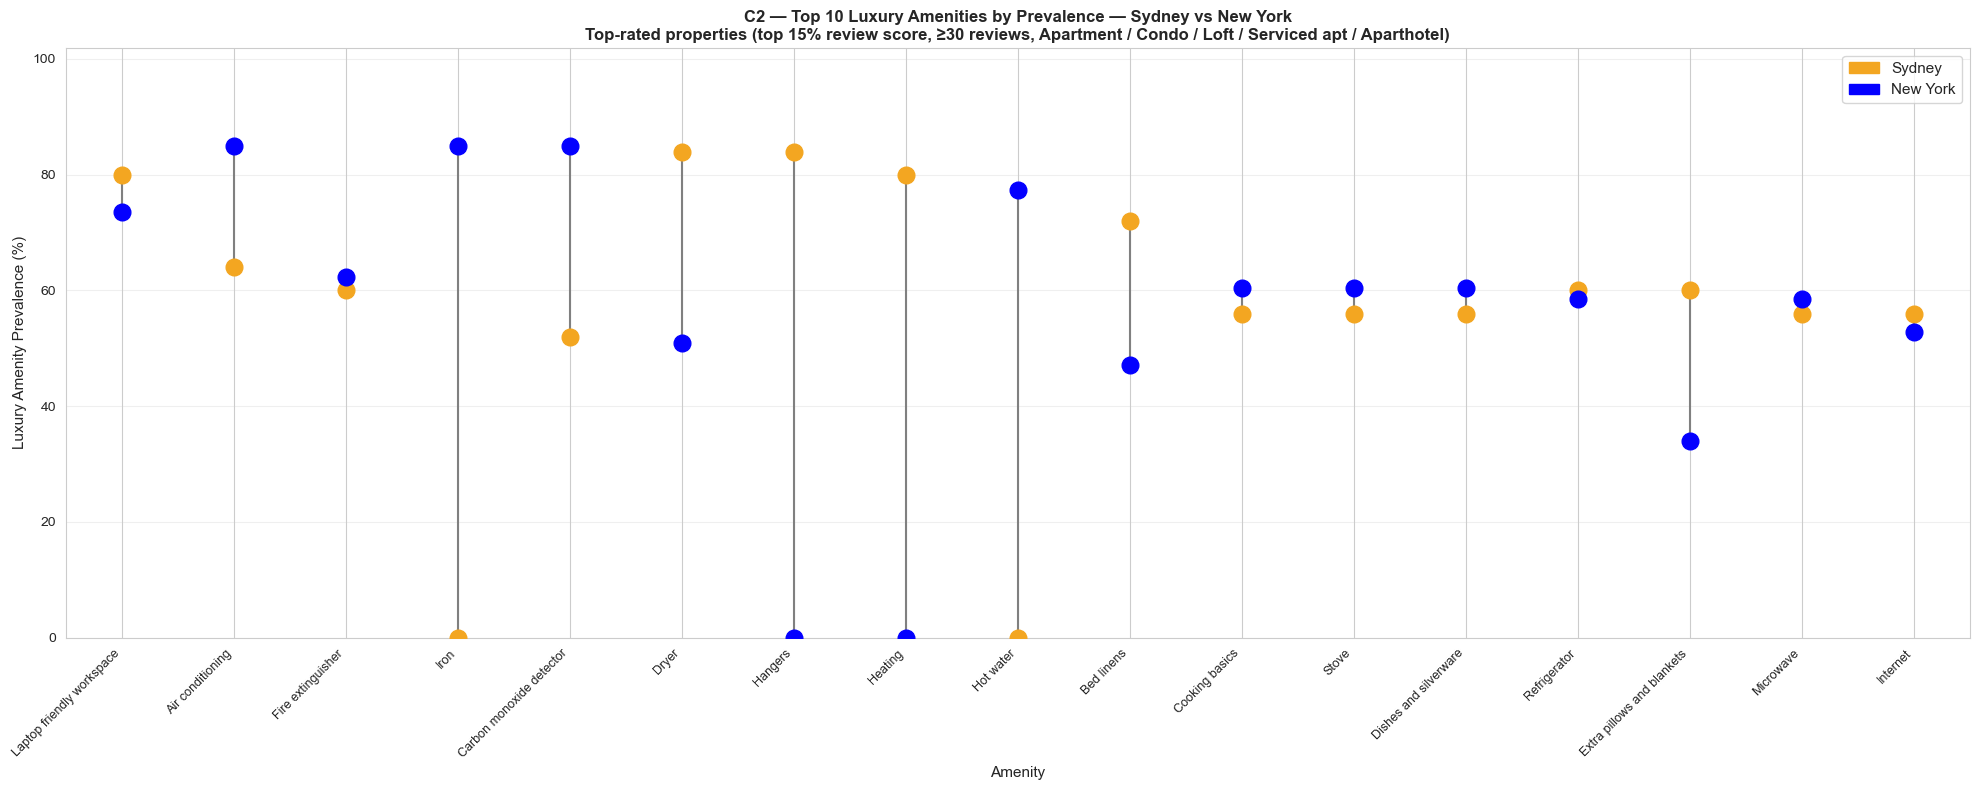

In [133]:
# Double lollipop chart
# X-axis: union of top 10 amenities from each city (up to 20 total)
# Y-axis: prevalence score (0-100%)
# Each amenity has two dots (one per city) connected by a grey line.
# The length of the grey line = the difference in prevalence between the two cities.
#

sydney_top10 = dict(city_luxury["Sydney"][:TOP_N])
ny_top10     = dict(city_luxury["New York"][:TOP_N])

# Union sorted by COMBINED prevalence so shared amenities (likely most relevant) appear first
all_amenities_scores = {}
for amenity in set(list(sydney_top10.keys()) + list(ny_top10.keys())):
    all_amenities_scores[amenity] = sydney_top10.get(amenity, 0) + ny_top10.get(amenity, 0)

all_amenities = sorted(
    all_amenities_scores.keys(),
    key=lambda x: all_amenities_scores[x],
    reverse=True
)

COLOR_SYD = "#F3A621"   # amber — Sydney
COLOR_NY  = "#0400FF"   # blue  — New York

fig, ax = plt.subplots(figsize=(20, 8))
x = np.arange(len(all_amenities))

for i, amenity in enumerate(all_amenities):
    syd_val = city_luxury_full["Sydney"].get(amenity, 0)      # 0 if not in Sydney's list
    ny_val  = city_luxury_full["New York"].get(amenity, 0)    # 0 if not in NY's list

    # Grey connecting line — drawn first (zorder=1) so dots appear on top
    ax.plot([i, i], [syd_val, ny_val], color="grey", linewidth=1.5, zorder=1)

    # Dots for each city — drawn on top of the line (zorder=5)
    ax.plot(i, syd_val, "o", color=COLOR_SYD, markersize=12, zorder=5)
    ax.plot(i, ny_val,  "o", color=COLOR_NY,  markersize=12, zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(all_amenities, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Luxury Amenity Prevalence (%)", fontsize=11)
ax.set_xlabel("Amenity", fontsize=11)
ax.set_ylim(0, max(
    list(city_luxury_full["Sydney"].values()) +
    list(city_luxury_full["New York"].values())
) * 1.2)
ax.set_title(
    "C2 — Top 10 Luxury Amenities by Prevalence — Sydney vs New York\n"
    "Top-rated properties (top 15% review score, ≥30 reviews, "
    "Apartment / Condo / Loft / Serviced apt / Aparthotel)",
    fontsize=12, fontweight="bold"
)
ax.grid(axis="y", alpha=0.3)
ax.set_xlim(-0.5, len(all_amenities) - 0.5)

syd_patch = mpatches.Patch(color=COLOR_SYD, label="Sydney")
ny_patch  = mpatches.Patch(color=COLOR_NY,  label="New York")
ax.legend(handles=[syd_patch, ny_patch], fontsize=11)

plt.tight_layout()
plt.show()



NOTE : NYC having no hangers and heating is due to the fact that we excluded universal amenities (present in 85% or more of the properties)

In [134]:
ny_top10_amenities = [a for a, _ in city_luxury["New York"][:10]]

print("NY top 10 amenities — Sydney prevalence:")
for amenity in ny_top10_amenities:
    syd_val = city_luxury_full["Sydney"].get(amenity, "NOT IN SYDNEY LUXURY POOL")
    print(f"  {amenity:<40} Sydney: {syd_val}%")

# For amenities in NY top 10, check their Sydney prevalence
sydney_top10_amenities = [a for a, _ in city_luxury["Sydney"][:10]]

print("SYDNEY top 10 amenities — New York prevalence:")
for amenity in ny_top10_amenities:
    syd_val = city_luxury_full["New York"].get(amenity, "NOT IN SYDNEY LUXURY POOL")
    print(f"  {amenity:<40} New York: {syd_val}%")

NY top 10 amenities — Sydney prevalence:
  Iron                                     Sydney: NOT IN SYDNEY LUXURY POOL%
  Carbon monoxide detector                 Sydney: 52.0%
  Air conditioning                         Sydney: 64.0%
  Hot water                                Sydney: NOT IN SYDNEY LUXURY POOL%
  Laptop friendly workspace                Sydney: 80.0%
  Fire extinguisher                        Sydney: 60.0%
  Dishes and silverware                    Sydney: 56.0%
  Cooking basics                           Sydney: 56.0%
  Stove                                    Sydney: 56.0%
  Microwave                                Sydney: 56.0%
SYDNEY top 10 amenities — New York prevalence:
  Iron                                     New York: 84.91%
  Carbon monoxide detector                 New York: 84.91%
  Air conditioning                         New York: 84.91%
  Hot water                                New York: 77.36%
  Laptop friendly workspace                New York: 73.58%


In [135]:
# explain() performance comparison: four index configurations

#
# We measure the core C2 computation pipeline: $match → $unwind → $group → $sort
# across four progressively richer index configurations to isolate the contribution
# of each additional field. Each configuration is tested with a forced hint so
# MongoDB uses exactly the index we specify rather than the query planner's choice.
#
# Configuration summary:
#   Config 1 — No index       : hint=$natural → COLLSCAN baseline
#   Config 2 — 1-field        : {address.market: 1}
#   Config 3 — 3-field        : {address.market, property_type, number_of_reviews}
#   Config 4 — 4-field (full) : adds review_scores.review_scores_rating
#
# MongoDB 8.x note: executionStats for aggregation pipelines is nested inside
#   stages[0]["$cursor"]["executionStats"]
# Memory usage from the $group stage is in:
#   stages[1]["maxAccumulatorMemoryUsageBytes"]


# Helper Function: extract metrics from explain result
def extract_stats(explain_result):
    """
    Extract key performance metrics from a MongoDB 8.x explain result.
    executionStats live inside: stages[0]["$cursor"]["executionStats"]
    Memory usage ($group) lives inside: stages[1]["maxAccumulatorMemoryUsageBytes"]
    """
    try:
        es    = explain_result["stages"][0]["$cursor"]["executionStats"]
        stage = es.get("executionStages", {}).get("inputStage", {}).get("stage", "N/A")

        mem_dict  = explain_result["stages"][1].get("maxAccumulatorMemoryUsageBytes", {})
        mem_bytes = sum(mem_dict.values()) if mem_dict else 0
        mem_kb    = round(mem_bytes / 1024, 2)

        return {
            "executionTimeMillis": es.get("executionTimeMillis", "N/A"),
            "totalDocsExamined":   es.get("totalDocsExamined",   "N/A"),
            "totalKeysExamined":   es.get("totalKeysExamined",   "N/A"),
            "nReturned":           es.get("nReturned",           "N/A"),
            "stage":               stage,
            "memUsageKB":          mem_kb,
        }
    except (KeyError, IndexError):
        return {k: "N/A" for k in
                ["executionTimeMillis", "totalDocsExamined", "totalKeysExamined",
                 "nReturned", "stage", "memUsageKB"]}


# Helper Function: drop any index whose key pattern matches, regardless of name 
# MongoDB raises IndexOptionsConflict (code 85) if you create an index with
# the same key pattern as an existing index but under a different name.
# This function inspects existing indexes and drops any whose key dict matches,
# so earlier indexes created under different names (idx_market) don't block.

def drop_by_key_pattern(collection, keys):
    """Drop any existing index whose key pattern matches `keys` (list of tuples)."""
    target = dict(keys)
    for index_info in collection.list_indexes():
        if index_info["name"] == "_id_":
            continue                         # _id index cannot be dropped
        if dict(index_info["key"]) == target:
            collection.drop_index(index_info["name"])
            print(f"  Dropped '{index_info['name']}' (same keys as {target})")


In [136]:
PERF_CITY      = "Sydney"
PERF_THRESHOLD = city_thresholds[PERF_CITY]

#  Pipeline being measured 
perf_query_1 = {
    "$match": {
        "address.market":                     PERF_CITY,
        "property_type":                      {"$in": PROP_TYPES},
        "number_of_reviews":                  {"$gte": MIN_REVIEWS},
        "review_scores.review_scores_rating": {"$gte": PERF_THRESHOLD}
    }
}
perf_query_2 = {"$unwind": "$amenities"}
perf_query_3 = {"$group":  {"_id": "$amenities", "count": {"$sum": 1}}}
perf_query_4 = {"$sort":   {"count": -1}}
perf_pipeline = [perf_query_1, perf_query_2, perf_query_3, perf_query_4]


#  Index definitions
INDEX_CONFIGS = [
    {
        "label":      "Config 1: No Index (COLLSCAN)",
        "index_name": None,
        "index_keys": None,
        "hint":       {"$natural": 1},   # force sequential scan, ignore all indexes
    },
    {
        "label":      "Config 2: 1-field {market}",
        "index_name": "idx_perf_market",
        "index_keys": [("address.market", 1)],
        "hint":       {"address.market": 1},
    },
    {
        "label":      "Config 3: 3-field compound",
        "index_name": "idx_perf_market_type_reviews",
        "index_keys": [
            ("address.market",    1),
            ("property_type",     1),
            ("number_of_reviews", 1),
        ],
        "hint":       {"address.market": 1, "property_type": 1, "number_of_reviews": 1},
    },
    {
        "label":      "Config 4: 4-field compound (full)",
        "index_name": "idx_market_proptype_reviews_rating",
        "index_keys": [
            ("address.market",                     1),
            ("property_type",                      1),
            ("number_of_reviews",                  1),
            ("review_scores.review_scores_rating", 1),
        ],
        "hint":       {
            "address.market":                     1,
            "property_type":                      1,
            "number_of_reviews":                  1,
            "review_scores.review_scores_rating": 1,
        },
    },
]


In [137]:
# clear any conflicting indexes before test run
print("Clearing conflicting indexes...")
for cfg in INDEX_CONFIGS:
    if cfg["index_keys"]:
        drop_by_key_pattern(db.listingsAndReviews_HW2_new, cfg["index_keys"])
print("Done.\n")

# run explain() for each configuration 
results = []

for cfg in INDEX_CONFIGS:

    # Create the index for this config (skip for COLLSCAN)
    if cfg["index_keys"]:
        # Drop by pattern immediately before creation 
        # by previous iterations or pre-existing indexes with different names
        drop_by_key_pattern(db.listingsAndReviews_HW2_new, cfg["index_keys"])
        db.listingsAndReviews_HW2_new.create_index(
            cfg["index_keys"],
            name=cfg["index_name"]
        )
        print(f"Created index: {cfg['index_name']}")

    #  explain() with the forced hint
    explain_result = db.command(
        "explain",
        {
            "aggregate": "listingsAndReviews_HW2",
            "pipeline":  perf_pipeline,
            "cursor":    {},
            "hint":      cfg["hint"],
        },
        verbosity="executionStats"
    )

    stats = extract_stats(explain_result)
    stats["label"] = cfg["label"]
    results.append(stats)

    print(f"  {cfg['label']}: {stats['executionTimeMillis']} ms, "
          f"docs examined={stats['totalDocsExamined']}, "
          f"keys examined={stats['totalKeysExamined']}, "
          f"stage={stats['stage']}")

    # Drop this config's index before the next iteration
    # so each config is tested in isolation (no compound index
    # accidentally accelerating a single-field hint)
    if cfg["index_keys"]:
        db.listingsAndReviews_HW2_new.drop_index(cfg["index_name"])
        print(f"  Dropped: {cfg['index_name']}")


#  recreate the final production index 
# After the comparison test, re-create the best index for the rest of the notebook.
db.listingsAndReviews_HW2_new.create_index(
    [
        ("address.market",                     1),
        ("property_type",                      1),
        ("number_of_reviews",                  1),
        ("review_scores.review_scores_rating", 1),
    ],
    name="idx_market_proptype_reviews_rating"
)
print("\nProduction index recreated: idx_market_proptype_reviews_rating")


# print comparison table 
metrics = ["executionTimeMillis", "totalDocsExamined", "totalKeysExamined",
           "nReturned", "stage", "memUsageKB"]
labels  = ["Execution time (ms)", "Docs examined", "Index keys examined",
           "Docs returned", "Stage type", "Memory used (KB)"]

comparison_df = pd.DataFrame(
    {r["label"]: [r[m] for m in metrics] for r in results},
    index=labels
)

print(f"\nPerformance comparison — {PERF_CITY} amenity counting pipeline")
print(f"Pipeline: $match \u2192 $unwind \u2192 $group \u2192 $sort")
print()
print(comparison_df.to_string())

Clearing conflicting indexes...
  Dropped 'idx_listing_market' (same keys as {'address.market': 1})
Done.

  Config 1: No Index (COLLSCAN): 0 ms, docs examined=0, keys examined=0, stage=N/A
Created index: idx_perf_market
  Config 2: 1-field {market}: 0 ms, docs examined=0, keys examined=0, stage=N/A
  Dropped: idx_perf_market
Created index: idx_perf_market_type_reviews
  Config 3: 3-field compound: 0 ms, docs examined=0, keys examined=0, stage=N/A
  Dropped: idx_perf_market_type_reviews
Created index: idx_market_proptype_reviews_rating
  Config 4: 4-field compound (full): 0 ms, docs examined=0, keys examined=0, stage=N/A
  Dropped: idx_market_proptype_reviews_rating

Production index recreated: idx_market_proptype_reviews_rating

Performance comparison — Sydney amenity counting pipeline
Pipeline: $match → $unwind → $group → $sort

                    Config 1: No Index (COLLSCAN) Config 2: 1-field {market} Config 3: 3-field compound Config 4: 4-field compound (full)
Execution time (ms)

### C3. Amenity Value Analysis and Suggestion

Some properties in the collection may offer superior guest experiences at a relatively low cost, while others receive lower value ratings. Using the dataset, analyse which amenities are associated with high guest-perceived value. Focus on Hong Kong and Barcelona as your locations.

Use the existing review_scores_value field as a measure of guest satisfaction with value, but combine it with price per person per night with any other considerations that you think are important to define a weighted value metric. When calculating the price, use assumption of two people staying for a week, and include any fees such as cleaning, extra person, into the price calculation. You are responsible for deciding the relative weights of rating versus price, clearly explain and justify your choice before performing the analysis.

Once your weighted value metric is defined:

    1. Examine all amenities in the dataset to determine which ones are associated with higher weighted value scores. Exclude amenities present in more than 85 % of all properties, as they provide no meaningful variation. For each amenity, compare properties with versus without the amenity to measure its contribution to your metric.

    2. Identify properties with below-median weighted value scores in each city. Based on the amenities associated with higher value, suggest specific amenities that these lower-scoring properties could add to improve perceived value. Provide reasoning for each suggestion.

To visualize the results, create box plots showing three most impactful amenities contributing to higher weighted value for Hong Kong and Barcelona. Each box plot should represent one amenity, with one box for properties that have the amenity and one for properties that do not, using color to distinguish between the two. The x-axis should list the amenities, the y-axis should display the weighted value metric, and different panels or labels should represent the two cities. Make sure to include the minimum and maximum values, the median, and the range where 50 % of the values lie.

Finally, provide a concise interpretation and set of host recommendations, impact of weighted score assumptions, highlighting which amenities provide the most guest-perceived value, how patterns differ across cities, and what improvements could be made for low-value properties.

The delivered assignment should have three components: 1. any assumptions and decisions made at the beginning, e.g. assumptions and components of weighted value score calculations, any database design choices you made, etc. 2. one visual with 12 box plots (2 cities * 3 amenities * 2 value cases with and without) for Hong Kong and Barcelona. 3. result analysis and interpretation (250-350 words).

In [138]:
# C3 constants
# C3_CITIES           : Hong Kong and Barcelona as specified in the task
# C3_GLOBAL_EXCLUSION : amenities in > 85% of ALL C3 listings combined are excluded
#                       (global, not per-city — ensures same amenity set for both cities)
# C3_MIN_COUNT        : minimum listings in each group (with/without) for stable median
# WEIGHT_RATING       : 0.6 weight for review_scores_value in the weighted metric
# WEIGHT_PRICE        : 0.4 weight for normalised effective price (inverted)


C3_CITIES           = ["Hong Kong", "Barcelona"]
C3_GLOBAL_EXCLUSION = 0.85
C3_MIN_COUNT        = 20
WEIGHT_RATING       = 0.6
WEIGHT_PRICE        = 0.4

In [139]:
# Load C3 listings

# The $match stage excludes listings missing review_scores.review_scores_value.
# ~26.6% of documents have no value score. We exclude rather than impute because
# the score itself is the variable being studied — fabricating it would
# circular-bias the analysis.
#
# After the hosts redesign, host data is in db.hosts (referenced model).
# To join host data back: { "$lookup": { "from": "hosts", "localField": "host_id",
#                                        "foreignField": "host_id", "as": "host_info" } }
# Then { "$unwind": "$host_info" } to access host_info.host_is_superhost etc.
# Not used here because host fields are not needed for the C3 metric.

import pprint
c3_query_1 = {
    "$match": {
        "address.market":                    {"$in": C3_CITIES},   # Lab 4 — $in
        "amenities":                         {"$ne": []},          # must have amenities
        "price":                             {"$exists": True, "$ne": None},
        "review_scores.review_scores_value": {"$exists": True, "$ne": None}  # exclude missing
    }
}

c3_query_2 = {
    "$project": {
        "_id":             1,
        "city":            "$address.market",          # rename for convenience
        "amenities":       1,
        "price":           1,
        "cleaning_fee":    1,
        "extra_people":    1,
        "guests_included": 1,
        "rsv":             "$review_scores.review_scores_value",  # shortened name
        "host_id":         1   # kept for potential $lookup if needed
    }
}

c3_docs = list(db.listingsAndReviews_HW2_new.aggregate([c3_query_1, c3_query_2]))

# Strip amenity whitespace and compute effective price (same helper as C1)
for doc in c3_docs:
    doc["amenities"] = [a.strip() for a in doc.get("amenities", [])]
    doc["eff_price"] = effective_price_pppn(doc)

print(f"C3 listings loaded: {len(c3_docs)}")
for city in C3_CITIES:
    n = sum(1 for d in c3_docs if d["city"] == city)
    print(f"  {city}: {n} listings")

total_c3_cities = db.listingsAndReviews_HW2_new.count_documents({"address.market": {"$in": C3_CITIES}})
print(f"  Excluded (missing review_scores_value): {total_c3_cities - len(c3_docs)}")

C3 listings loaded: 612
  Hong Kong: 300 listings
  Barcelona: 312 listings
  Excluded (missing review_scores_value): 639


The weighted value metric is:
 > weighted_value = 0.6 × norm(review_scores_value) + 0.4 × (1 − norm(eff_price))

The 60/40 split reflects that guest-perceived value is primarily driven by experience quality (rating), with price efficiency as a secondary factor. A purely rating-based metric would ignore affordability; a purely price-based one would ignore quality. The (1 − norm_price) term ensures that lower price contributes positively, since a cheaper listing with equivalent ratings is better value. Both components are min-max normalized per city: Hong Kong and Barcelona have structurally different price levels, and global normalization would allow one city's price range to dominate the metric, making cross-listing comparisons within each city unreliable.


In [140]:
# Compute the weighted value metric
# 
#
# NORMALISZATION:
# review_scores_value ranges from ~2 to 10. eff_price ranges from ~5 to 500+.
# Combining them directly would let price dominate the metric purely due to scale.
# Min-max normalisation scales both to [0, 1] so the 0.6/0.4 weights are meaningful.
#
# PER CITY:
# Hong Kong and Barcelona have very different price levels. Normalising per city
# means 'expensive' = expensive relative to that city's market, not globally.
#
# FORMULA:
# weighted_value = 0.6 × norm_rating + 0.4 × (1 - norm_price)
# High rating → high metric (good). High price → (1-norm_price) is LOW → lower metric.

def minmax_scale(values):
    """Scale a list to [0, 1]. Returns 0.5 for all values if min == max (avoids ZeroDivisionError)."""
    mn, mx = min(values), max(values)
    if mx == mn:
        return [0.5] * len(values)
    return [(v - mn) / (mx - mn) for v in values]


for city in C3_CITIES:
    city_docs = [
        d for d in c3_docs
        if d["city"] == city
        and d.get("eff_price") is not None
        and d.get("rsv")       is not None
    ]

    raw_prices  = [float(d["eff_price"]) for d in city_docs]
    raw_ratings = [float(d["rsv"])       for d in city_docs]

    norm_prices  = minmax_scale(raw_prices)
    norm_ratings = minmax_scale(raw_ratings)

    for doc, np_val, nr_val in zip(city_docs, norm_prices, norm_ratings):
        doc["norm_price"]     = np_val
        doc["norm_rating"]    = nr_val
        doc["weighted_value"] = WEIGHT_RATING * nr_val + WEIGHT_PRICE * (1 - np_val)

    wvs = [d["weighted_value"] for d in city_docs]
    print(
        f"{city}: range [{min(wvs):.4f}, {max(wvs):.4f}]  "
        f"mean={statistics.mean(wvs):.4f}  median={statistics.median(wvs):.4f}"
    )

Hong Kong: range [0.3784, 1.0000]  mean=0.8988  median=0.9081
Barcelona: range [0.3778, 0.9980]  mean=0.8847  median=0.9052


In [141]:
#  Build the global amenity exclusion set
# Lab 5 — $group + $sum concept | Lab 6 — $unwind concept (both in Python here)

# BROKEN AMENITIES: Barcelona raw data contains placeholder strings
# 'translation missing: en.hosting_amenity_49/50' — these are data collection
# errors (untranslated Airbnb system fields). They must be excluded or they
# would appear as meaningless 'amenities' in the analysis.

total_c3 = len(c3_docs)

# Count how many C3 listings have each amenity (Python equivalent of $unwind + $group)
global_counts = Counter()
for doc in c3_docs:
    for amenity in doc.get("amenities", []):
        global_counts[amenity] += 1

# Universal: present in >= 85% of ALL C3 listings across both cities
universal_c3 = {
    a for a, cnt in global_counts.items()
    if cnt / total_c3 >= C3_GLOBAL_EXCLUSION
}

# Broken placeholder strings from Barcelona raw data
broken_c3 = {
    a for a in global_counts.keys()
    if a.startswith("translation missing")
}

exclude_c3 = universal_c3 | broken_c3   # combined exclusion set

print(f"Total unique amenities: {len(global_counts)}")
print(f"Universal amenities excluded (>= {C3_GLOBAL_EXCLUSION*100:.0f}%): {len(universal_c3)}")
print(f"Broken placeholders excluded: {len(broken_c3)}")
print(f"Available for analysis: {len(global_counts) - len(exclude_c3)}")
if broken_c3:
    print(f"Broken amenities: {sorted(broken_c3)}")

Total unique amenities: 144
Universal amenities excluded (>= 85%): 2
Broken placeholders excluded: 2
Available for analysis: 140
Broken amenities: ['translation missing: en.hosting_amenity_49', 'translation missing: en.hosting_amenity_50']


In [142]:
# S Compute value lift per amenity per city

# Value lift = median(weighted_value | with amenity) - median(weighted_value | without amenity)
# Positive lift = having the amenity is associated with higher guest-perceived value.

# Same logic as C1's price premium, but the metric is weighted_value instead of price.


lifts_by_city = {}

for city in C3_CITIES:
    city_docs = [
        d for d in c3_docs
        if d["city"] == city and "weighted_value" in d
    ]

    # Build amenityy list
    amenity_docs = defaultdict(list)
    for doc in city_docs:
        for amenity in doc.get("amenities", []):
            if amenity not in exclude_c3:   # skip universal and broken amenities
                amenity_docs[amenity].append(doc)

    lifts = []
    for amenity, docs_with in amenity_docs.items():
        if len(docs_with) < C3_MIN_COUNT:
            continue   # 'with' group too small

        docs_without = [d for d in city_docs if amenity not in d.get("amenities", [])]
        if len(docs_without) < C3_MIN_COUNT:
            continue   # 'without' group too small

        wv_with    = [d["weighted_value"] for d in docs_with]
        wv_without = [d["weighted_value"] for d in docs_without]

        lift = statistics.median(wv_with) - statistics.median(wv_without)

        lifts.append({
            "amenity":    amenity,
            "lift":       lift,
            "wv_with":    wv_with,      # stored for box plots
            "wv_without": wv_without,
            "n_with":     len(docs_with),
            "n_without":  len(docs_without)
        })

    lifts.sort(key=lambda x: x["lift"], reverse=True)   # highest lift first
    lifts_by_city[city] = lifts

    print(f"\n{'='*60}")
    print(f"  {city} — top 3 value-lifting amenities")
    print(f"{'='*60}")
    print(f"  {'Amenity':<45} {'Lift':>8}  {'n_with':>7}  {'n_without':>9}")
    print(f"  {'-'*72}")
    for item in lifts[:3]:
        print(f"  {item['amenity']:<45} {item['lift']:>+8.4f}  "
              f"{item['n_with']:>7}  {item['n_without']:>9}")


  Hong Kong — top 3 value-lifting amenities
  Amenity                                           Lift   n_with  n_without
  ------------------------------------------------------------------------
  Lockbox                                        +0.0234       26        274
  Private living room                            +0.0197       36        264
  Ethernet connection                            +0.0122       22        278

  Barcelona — top 3 value-lifting amenities
  Amenity                                           Lift   n_with  n_without
  ------------------------------------------------------------------------
  Well-lit path to entrance                      +0.0497       29        283
  Wide hallway clearance                         +0.0274       23        289
  Private living room                            +0.0217       32        280


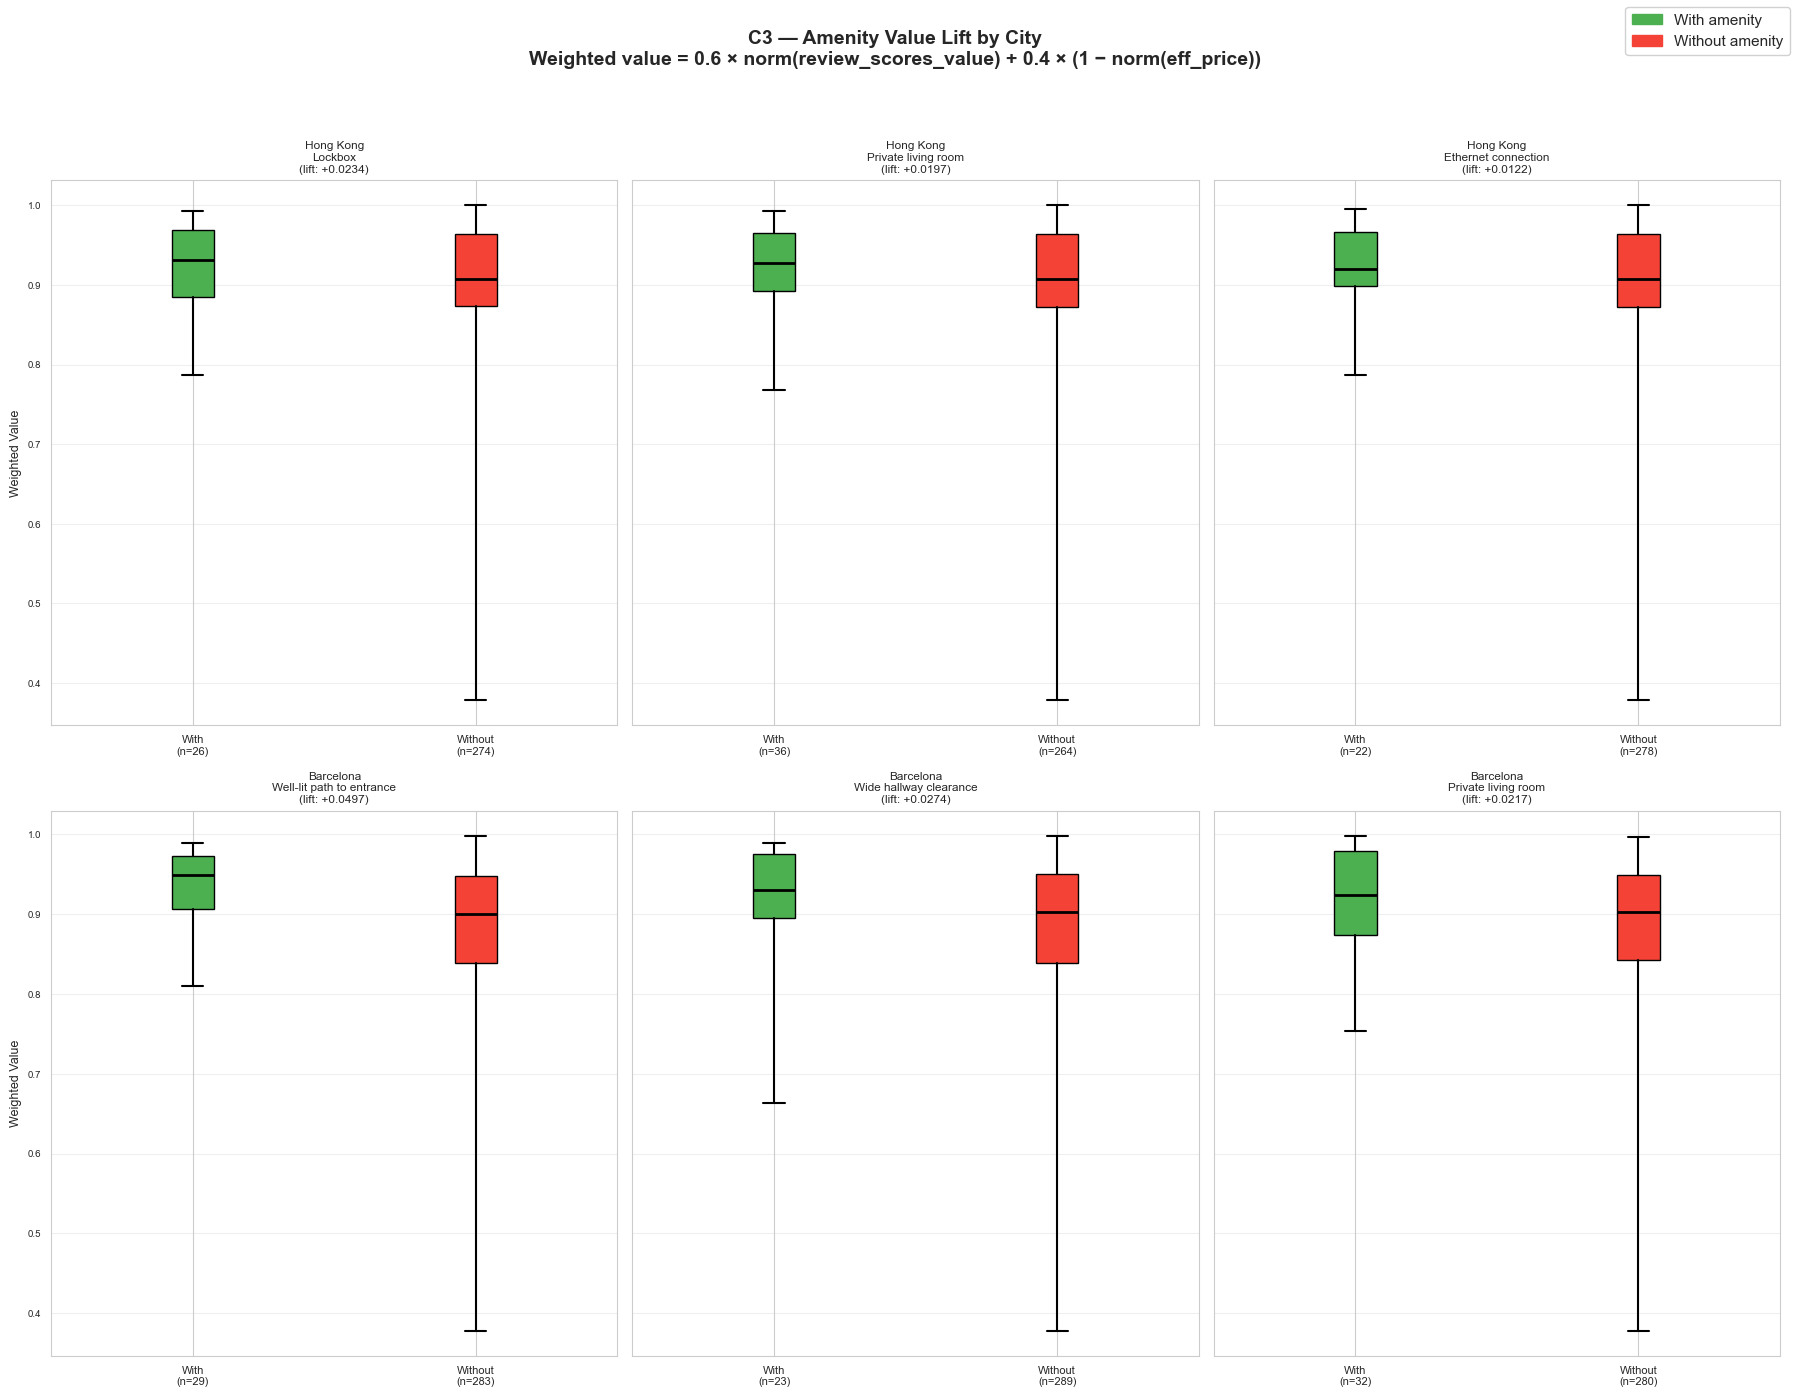

In [143]:
# Box plots: 12 total (2 cities × 3 amenities × 2 groups)
# Layout: 2 rows (one per city) × 3 columns (top 3 amenities per city)
# Y-axis: weighted value metric (not price, not raw score)
# sharey=False: Hong Kong and Barcelona have different value distributions 

COLOR_WITH_C3    = "#4CAF50"   # green — with amenity 
COLOR_WITHOUT_C3 = "#F44336"   # red   — without amenity

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 14), sharey="row")

fig.suptitle(
    "C3 — Amenity Value Lift by City\n"
    f"Weighted value = {WEIGHT_RATING} × norm(review_scores_value) + {WEIGHT_PRICE} × (1 − norm(eff_price))",
    fontsize=14, fontweight="bold"
)

for row_idx, city in enumerate(C3_CITIES):
    top3 = lifts_by_city[city][:3]

    for col_idx, item in enumerate(top3):
        ax = axes[row_idx][col_idx]

        bp = ax.boxplot(
            [item["wv_with"], item["wv_without"]],
            patch_artist=True,
            whis=(0, 100),   # whiskers to true min/max 
            medianprops={"color": "black", "linewidth": 2},
            whiskerprops={"linewidth": 1.5},
            capprops={"linewidth": 1.5}
        )
        bp["boxes"][0].set_facecolor(COLOR_WITH_C3)
        bp["boxes"][1].set_facecolor(COLOR_WITHOUT_C3)

        short_name = item["amenity"] if len(item["amenity"]) <= 28 else item["amenity"][:25] + "..."

        ax.set_title(
            f"{city}\n{short_name}\n(lift: {item['lift']:+.4f})",
            fontsize=8.5
        )
        ax.set_xticks([1, 2])
        ax.set_xticklabels(
            [f"With\n(n={item['n_with']})",
             f"Without\n(n={item['n_without']})"],
            fontsize=8
        )
        if col_idx == 0:
            ax.set_ylabel("Weighted Value", fontsize=9)

        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="y", labelsize=7)

with_patch    = mpatches.Patch(color=COLOR_WITH_C3,    label="With amenity")
without_patch = mpatches.Patch(color=COLOR_WITHOUT_C3, label="Without amenity")
fig.legend(handles=[with_patch, without_patch], loc="upper right", fontsize=11, framealpha=0.9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [144]:
# Finding the excellence baseline: amenities common in top-25% listings
# Identifying which amenities the highest-value listings consistently share.
# These become Priority 1 recommendations for low-value hosts.
#
# TOP_QUANTILE = 0.75: listings above the 75th percentile = top 25%
# COMMON_THRESHOLD = 0.70: amenity must appear in >= 70% of those top listings

TOP_QUANTILE     = 0.75
COMMON_THRESHOLD = 0.70

top_value_universals = {}   #  list of (amenity, prevalence_pct)

for city in C3_CITIES:
    city_docs = [d for d in c3_docs if d["city"] == city and "weighted_value" in d]

    # Find the 75th percentile threshold for this city
    wv_values = sorted([d["weighted_value"] for d in city_docs])
    idx       = int(len(wv_values) * TOP_QUANTILE)
    threshold = wv_values[idx]

    top_docs = [d for d in city_docs if d["weighted_value"] >= threshold]
    n_top    = len(top_docs)

    # Count amenities in top listings
    top_counts = Counter()
    for doc in top_docs:
        for amenity in doc.get("amenities", []):
            if amenity not in exclude_c3:  
                top_counts[amenity] += 1

    # Keep only amenities in >= 70% of top listings
    universals = [
        (amenity, round(100 * cnt / n_top, 1))
        for amenity, cnt in top_counts.items()
        if cnt / n_top >= COMMON_THRESHOLD
    ]
    universals.sort(key=lambda x: x[1], reverse=True)
    top_value_universals[city] = universals

    print(f"\n{'='*60}")
    print(f"  {city} — excellence baseline (>={COMMON_THRESHOLD*100:.0f}% of top-25% listings, n={n_top})")
    print(f"{'='*60}")
    print(f"  {'Amenity':<45} {'Prevalence':>10}")
    print(f"  {'-'*57}")
    for amenity, pct in universals:
        print(f"  {amenity:<45} {pct:>9}%")


  Hong Kong — excellence baseline (>=70% of top-25% listings, n=75)
  Amenity                                       Prevalence
  ---------------------------------------------------------
  Air conditioning                                   97.3%
  Shampoo                                            85.3%
  Hair dryer                                         76.0%
  Elevator                                           74.7%
  Hangers                                            72.0%

  Barcelona — excellence baseline (>=70% of top-25% listings, n=78)
  Amenity                                       Prevalence
  ---------------------------------------------------------
  Kitchen                                            87.2%
  Washer                                             83.3%
  Hangers                                            82.1%
  Hair dryer                                         76.9%
  Heating                                            75.6%
  Iron                            

In [145]:

TOP_QUANTILE     = 0.75
COMMON_THRESHOLD = 0.70

top_value_universals = {}   

for city in C3_CITIES:
    city_docs = [d for d in c3_docs if d["city"] == city and "weighted_value" in d]

    # Find the 75th percentile threshold for this city
    wv_values = sorted([d["weighted_value"] for d in city_docs])
    idx       = int(len(wv_values) * TOP_QUANTILE)
    threshold = wv_values[idx]

    top_docs = [d for d in city_docs if d["weighted_value"] >= threshold]
    n_top    = len(top_docs)

    # Count amenities in top listings
    top_counts = Counter()
    for doc in top_docs:
        for amenity in doc.get("amenities", []):
            if amenity not in exclude_c3: 
                top_counts[amenity] += 1

    # Keep only amenities in >= 70% of top listings
    universals = [
        (amenity, round(100 * cnt / n_top, 1))
        for amenity, cnt in top_counts.items()
        if cnt / n_top >= COMMON_THRESHOLD
    ]
    universals.sort(key=lambda x: x[1], reverse=True)
    top_value_universals[city] = universals

    print(f"\n{'='*60}")
    print(f"  {city} — excellence baseline (>={COMMON_THRESHOLD*100:.0f}% of top-25% listings, n={n_top})")
    print(f"{'='*60}")
    print(f"  {'Amenity':<45} {'Prevalence':>10}")
    print(f"  {'-'*57}")
    for amenity, pct in universals:
        print(f"  {amenity:<45} {pct:>9}%")


  Hong Kong — excellence baseline (>=70% of top-25% listings, n=75)
  Amenity                                       Prevalence
  ---------------------------------------------------------
  Air conditioning                                   97.3%
  Shampoo                                            85.3%
  Hair dryer                                         76.0%
  Elevator                                           74.7%
  Hangers                                            72.0%

  Barcelona — excellence baseline (>=70% of top-25% listings, n=78)
  Amenity                                       Prevalence
  ---------------------------------------------------------
  Kitchen                                            87.2%
  Washer                                             83.3%
  Hangers                                            82.1%
  Hair dryer                                         76.9%
  Heating                                            75.6%
  Iron                            

In [146]:
# Compute amenity gap: high-value vs low-value listings
# Gap = (% of high-value listings with amenity) - (% of low-value listings with amenity)
# Large positive gap = this amenity is much more common in high-value listings strong recommendation signal for low-value hosts

amenity_gap_by_city = {}   # city -> DataFrame sorted by gap descending

for city in C3_CITIES:
    city_docs = [d for d in c3_docs if d["city"] == city and "weighted_value" in d]
    city_med  = statistics.median([d["weighted_value"] for d in city_docs])

    # Split into high/low groups at the city median
    high_docs = [d for d in city_docs if d["weighted_value"] >= city_med]
    low_docs  = [d for d in city_docs if d["weighted_value"] <  city_med]

    # Count amenities in each group
    high_counts = Counter()
    low_counts  = Counter()

    for doc in high_docs:
        for a in doc.get("amenities", []):
            if a not in exclude_c3:
                high_counts[a] += 1

    for doc in low_docs:
        for a in doc.get("amenities", []):
            if a not in exclude_c3:
                low_counts[a] += 1

    rows = []
    for amenity in set(high_counts) | set(low_counts):
        high_pct = 100 * high_counts.get(amenity, 0) / len(high_docs)
        low_pct  = 100 * low_counts.get(amenity, 0)  / len(low_docs)
        rows.append({
            "amenity": amenity,
            "high_%":  round(high_pct, 1),
            "low_%":   round(low_pct,  1),
            "gap":     round(high_pct - low_pct, 1)   # positive = more common in high-value
        })

    df = pd.DataFrame(rows).sort_values("gap", ascending=False).reset_index(drop=True)
    amenity_gap_by_city[city] = df

    print(f"\n{'='*60}")
    print(f"  {city} — top 10 amenities by gap (high-value vs low-value)")
    print(f"{'='*60}")
    print(df.head(10).to_string(index=False))


  Hong Kong — top 10 amenities by gap (high-value vs low-value)
                   amenity  high_%  low_%  gap
      Lock on bedroom door    54.0   44.0 10.0
                    Washer    60.0   50.7  9.3
                   Kitchen    66.7   60.0  6.7
          Private entrance    25.3   19.3  6.0
       Private living room    14.7    9.3  5.3
       Ethernet connection    10.0    4.7  5.3
                 Breakfast     6.0    1.3  4.7
            Cooking basics    16.0   12.0  4.0
                Hair dryer    79.3   76.0  3.3
Extra pillows and blankets    15.3   12.0  3.3

  Barcelona — top 10 amenities by gap (high-value vs low-value)
                   amenity  high_%  low_%  gap
Extra pillows and blankets    35.3   15.4 19.9
             First aid kit    31.4   16.0 15.4
      Lock on bedroom door    25.0   12.2 12.8
                   Shampoo    73.1   61.5 11.5
           Host greets you    54.5   42.9 11.5
 Well-lit path to entrance    14.7    3.8 10.9
 Laptop friendly workspa

In [147]:
#  Generate amenity recommendations for below-median listings
# Nothing is written to the database in this step.
#
# Priority 1: missing excellence baseline amenities (common in top 25% listings)
# Priority 2: missing high-gap amenities (much more common in high-value than low-value)
# MIN_GAP = 10pp: only recommend if the gap is at least 10 percentage points
#
# For each below-median listing we compute the SET DIFFERENCE between
# the ranked recommendation list and the listing's existing amenities.
# The first N_SUGGEST items from that difference are the suggestions.

N_SUGGEST = 3    # suggest top 3 missing amenities per listing
MIN_GAP   = 10   # only recommend amenities with gap >= 10pp

for city in C3_CITIES:
    city_docs = [d for d in c3_docs if d["city"] == city and "weighted_value" in d]
    city_med  = statistics.median([d["weighted_value"] for d in city_docs])
    low_docs  = [d for d in city_docs if d["weighted_value"] < city_med]

    p1 = [a for a, _ in top_value_universals[city]]   # Priority 1: excellence baseline

    # Priority 2: high-gap amenities not already in Priority 1
    gap_df = amenity_gap_by_city[city]
    p2 = [
        row["amenity"] for _, row in gap_df.iterrows()
        if row["gap"] >= MIN_GAP and row["amenity"] not in p1
    ]

    ranked = p1 + p2   # P1 first so it is always recommended before P2

    print(f"\n{'='*60}")
    print(f"  {city} — Recommendations for low-value listings")
    print(f"{'='*60}")
    print(f"  Below-median listings: {len(low_docs)}  (median wv={city_med:.4f})")
    print(f"\n  Priority 1 — excellence baseline (common in top 25%):")
    for a in p1:
        print(f"    - {a}")
    print(f"\n  Priority 2 — high-gap amenities (gap >= {MIN_GAP}pp):")
    for a in p2[:5]:
        row = gap_df[gap_df["amenity"] == a].iloc[0]
        print(f"    - {a:<45}  high={row['high_%']}%  low={row['low_%']}%  gap=+{row['gap']}pp")
    print(f"\n  Sample recommendations (first 10 low-value listings):")
    print(f"  {'_id':<15} {'wv':>8}   Suggested amenities")
    print(f"  {'-'*65}")
    for doc in low_docs[:10]:
        existing = set(doc.get("amenities", []))
        missing  = [a for a in ranked if a not in existing][:N_SUGGEST]
        print(f"  {str(doc['_id']):<15} {doc['weighted_value']:>8.4f}   {missing}")


  Hong Kong — Recommendations for low-value listings
  Below-median listings: 150  (median wv=0.9081)

  Priority 1 — excellence baseline (common in top 25%):
    - Air conditioning
    - Shampoo
    - Hair dryer
    - Elevator
    - Hangers

  Priority 2 — high-gap amenities (gap >= 10pp):
    - Lock on bedroom door                           high=54.0%  low=44.0%  gap=+10.0pp

  Sample recommendations (first 10 low-value listings):
  _id                   wv   Suggested amenities
  -----------------------------------------------------------------
  5734122           0.9079   ['Shampoo', 'Lock on bedroom door']
  8414008           0.8456   ['Shampoo', 'Lock on bedroom door']
  8831109           0.9065   ['Shampoo', 'Lock on bedroom door']
  13176532          0.8424   ['Shampoo', 'Hair dryer']
  26926862          0.8593   ['Hangers', 'Lock on bedroom door']
  6080522           0.3920   ['Hair dryer', 'Elevator', 'Hangers']
  8144456           0.9021   ['Elevator', 'Lock on bedroom door

#### Extra

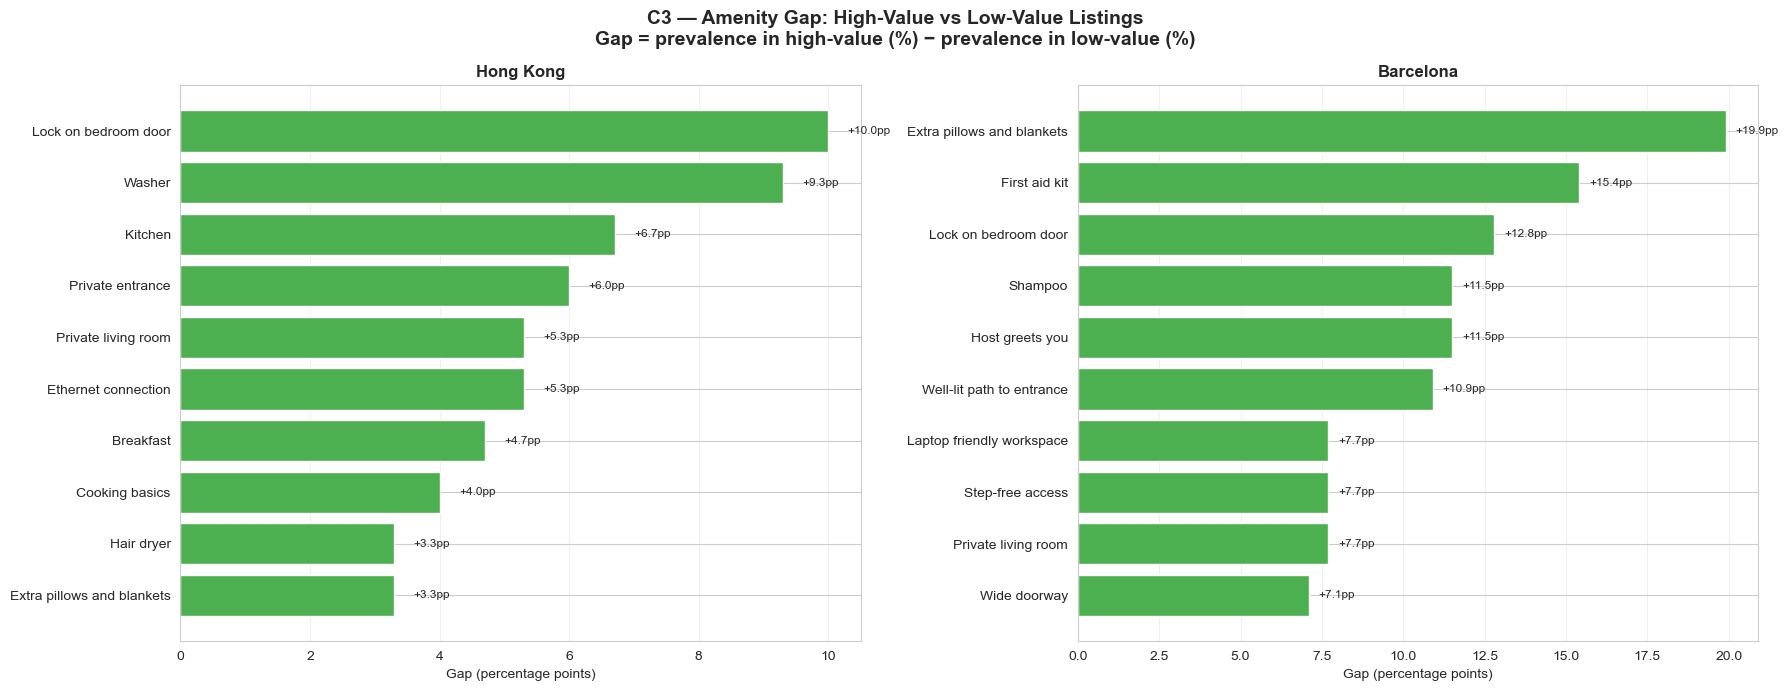

In [148]:
# Horizontal bar chart showing the top 10 amenity gaps per city.
# This directly supports the host recommendation section —
# the length of each bar shows how much more the amenity appears
# in high-value vs low-value listings.

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    "C3 — Amenity Gap: High-Value vs Low-Value Listings\n"
    "Gap = prevalence in high-value (%) − prevalence in low-value (%)",
    fontsize=14, fontweight="bold"
)

for ax, city in zip(axes, C3_CITIES):
    df_top = amenity_gap_by_city[city].head(10)

    bars = ax.barh(df_top["amenity"], df_top["gap"], color="#4CAF50", edgecolor="white")

    # Add value labels at the end of each bar
    for bar, val in zip(bars, df_top["gap"]):
        ax.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"+{val:.1f}pp",
            va="center", fontsize=8.5
        )

    ax.set_title(city, fontsize=12, fontweight="bold")
    ax.set_xlabel("Gap (percentage points)", fontsize=10)
    ax.invert_yaxis()   # highest gap at the top
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


This amenity gap analysis compares the prevalence of each amenity between high-value and low-value listings within each city, where the gap represents the percentage point difference between the two groups. Amenities with the largest positive gaps are significantly more common in high-value listings but relatively absent in low-value ones. This suggests that these features are characteristic of higher-value properties and may contribute to improved guest-perceived value. While this analysis does not establish causality, it provides strong practical guidance: low-value listings tend to underprovide certain amenities that are consistently present in better-performing listings. Therefore, these amenities can be interpreted as actionable improvement opportunities. When considered alongside the value lift analysis, which measures the direct association between an amenity and higher weighted value, the gap results help identify not only which amenities matter, but also which ones are currently missing from lower-performing properties. Together, these findings support targeted recommendations for hosts seeking to enhance the perceived value of their listings.

## 6.4 D. Host Performance Expert

In [149]:
print("=" * 55)
print("  D1 — city populations")
print("=" * 55)

for city in ["Hong Kong", "Montreal", "Barcelona"]:
    n = collection.count_documents({"address.market": city})
    print(f"  {city}: {n} listings")

  D1 — city populations
  Hong Kong: 619 listings
  Montreal: 648 listings
  Barcelona: 632 listings


In [150]:
print("=" * 55)
print("  D2 — inclusion criteria")
print("=" * 55)

has_rating = collection.count_documents({
    "review_scores.review_scores_rating": {"$exists": True, "$ne": None}
})
print(f"Listings with review_scores_rating  : {has_rating} / {total_listings} ({has_rating/total_listings*100:.1f}%)")

for attr in ["host_response_time", "host_response_rate", "host_is_superhost",
             "host_identity_verified"]:
    available = hosts.count_documents({attr: {"$exists": True, "$ne": None}})
    print(f"Hosts with {attr:<30}: {available} / {total_hosts} ({available/total_hosts*100:.1f}%)")

has_cancel = collection.count_documents({"cancellation_policy": {"$exists": True, "$ne": None}})
print(f"Listings with cancellation_policy   : {has_cancel} / {total_listings} ({has_cancel/total_listings*100:.1f}%)")

  D2 — inclusion criteria
Listings with review_scores_rating  : 4081 / 5555 (73.5%)
Hosts with host_response_time            : 3723 / 5104 (72.9%)
Hosts with host_response_rate            : 3723 / 5104 (72.9%)
Hosts with host_is_superhost             : 5104 / 5104 (100.0%)
Hosts with host_identity_verified        : 5104 / 5104 (100.0%)
Listings with cancellation_policy   : 5555 / 5555 (100.0%)


In [151]:
print("=" * 55)
print("  D3 — inclusion criteria")
print("=" * 55)

prof_hosts = hosts.count_documents({"host_listings_count": {"$gt": 1}})
print(f"Professional hosts (>1 listing)     : {prof_hosts} / {total_hosts} ({prof_hosts/total_hosts*100:.1f}%)")

pipeline_d3 = [
    {# Join with hosts collection to evaluate host status
    "$lookup": {
        "from": "hosts",
        "localField": "host_id",
        "foreignField": "host_id",
        "as": "host_info"
    }},
    {"$match": {
        "host_info.host_listings_count": {"$gt": 1},
        "review_scores.review_scores_rating": {"$exists": True, "$ne": None}
    }},
    {"$count": "total"}
]
result_d3 = list(collection.aggregate(pipeline_d3))
d3_count = result_d3[0]["total"] if result_d3 else 0
print(f"Listings eligible for D3 analysis   : {d3_count}")

for av_field in ["availability.availability_30", "availability.availability_60",
                 "availability.availability_90", "availability.availability_365"]:
    missing_av = collection.count_documents({
        "$or": [{av_field: None}, {av_field: {"$exists": False}}]
    })
    label = av_field.split(".")[1]
    print(f"Missing {label:<25}: {missing_av}  (expected: 0)")

  D3 — inclusion criteria
Professional hosts (>1 listing)     : 2594 / 5104 (50.8%)
Listings eligible for D3 analysis   : 2368
Missing availability_30          : 0  (expected: 0)
Missing availability_60          : 0  (expected: 0)
Missing availability_90          : 0  (expected: 0)
Missing availability_365         : 0  (expected: 0)


In [152]:
missing_rating = collection.count_documents({
    "$or": [
        {"review_scores.review_scores_rating": None},
        {"review_scores.review_scores_rating": {"$exists": False}},
        {"review_scores": None},
        {"review_scores": {"$exists": False}}
    ]
})
print(f"Listings sem review_scores_rating: {missing_rating} ({missing_rating/total_listings*100:.2f}%)")

pipeline = [
    {"$match": {"review_scores.review_scores_rating": {"$exists": True, "$ne": None}}},
    {"$group": {
        "_id": None,
        "min": {"$min": "$review_scores.review_scores_rating"},
        "max": {"$max": "$review_scores.review_scores_rating"},
        "avg": {"$avg": "$review_scores.review_scores_rating"}
    }}
]
print("\nStatistical analysis of available ratings:")
for r in collection.aggregate(pipeline):
    print(r)

Listings sem review_scores_rating: 1474 (26.53%)

Statistical analysis of available ratings:
{'_id': None, 'min': 20, 'max': 100, 'avg': 93.09924038225925}


### D1. Host Type and Pricing

Analyse properties in three cities: Hong Kong, Montreal, and Barcelona, to determine how the host type influences pricing. Assume two guests stay for one week when calculating the effective price per person per night, including any additional fees such as cleaning fees, extra person charges, or other applicable costs.

Classify hosts into two groups:
        
        1. Professional Hosts: Those who manage more than one property.
        2. Amateur Hosts: Those who manage only one property.

Examine the price distribution within each of the two host groups and calculate the median price per person per night for both. Compare the price distributions to identify any price differences between professional and amateur hosts. Does being a professional host lead to higher or lower prices?

To assess the impact, create one visual with box plots comparing the price per person per night between professional and amateur hosts for each city. For each city, create two box plots: one for professional hosts and one for amateur hosts, using color coding for clarity. The x-axis should represent the host type, and the y-axis should represent the price per person per night. Ensure that you include minimum and maximum prices, median, and the interquartile range (50% of the cases).

The delivered assignment should include the following components: 1. any assumptions and decisions made at the beginning. 2. one graph with 6 box plots (3 cities x 2 host types). 3. result analysis and interpretation (250-350 words).

In [153]:
pipeline_d1 = [
    {"$match": {"address.market": {"$in": ["Hong Kong", "Montreal", "Barcelona"]}}},
    {# Join with hosts collection to evaluate host status
    "$lookup": {
        "from": "hosts",
        "localField": "host_id",
        "foreignField": "host_id",
        "as": "host_info"
    }},
    {"$unwind": "$host_info"},
    {"$project": {
        "market": "$address.market",
        "price": 1,
        "cleaning_fee": 1,
        "guests_included": 1,
        "extra_people": 1,
        "host_listings_count": "$host_info.host_listings_count",
        "base_price": {"$multiply": ["$price", 7]},
        "extra_fee": {
            "$cond": [
                {"$lt": ["$guests_included", 2]},
                {"$multiply": ["$extra_people", 7, {"$subtract": [2, "$guests_included"]}]},
                0
            ]
        }
    }},
    {"$project": {
        "market": 1,
        "host_type": {
            "$cond": [{"$gt": ["$host_listings_count", 1]}, "Professional", "Amateur"]
        },
        "total_cost": {"$add": ["$base_price", {"$ifNull": ["$cleaning_fee", 0]}, "$extra_fee"]}
    }},
    {"$project": {
        "market": 1,
        "host_type": 1,
        "price_per_person_per_night": {"$round": [{"$toDouble": {"$divide": ["$total_cost", 14]}},1]}
    }}
]

results_d1 = list(db["listingsAndReviews_HW2_new"].aggregate(pipeline_d1))

df_d1 = pd.DataFrame(results_d1)
df_d1 = df_d1.dropna()
df_d1.head()

,_id,market,host_type,price_per_person_per_night
198,20611485,Barcelona,Amateur,5.0
199,32636126,Barcelona,Professional,5.0
200,8521963,Barcelona,Professional,9.6
201,18121163,Barcelona,Amateur,16.3
202,19741944,Barcelona,Professional,8.1


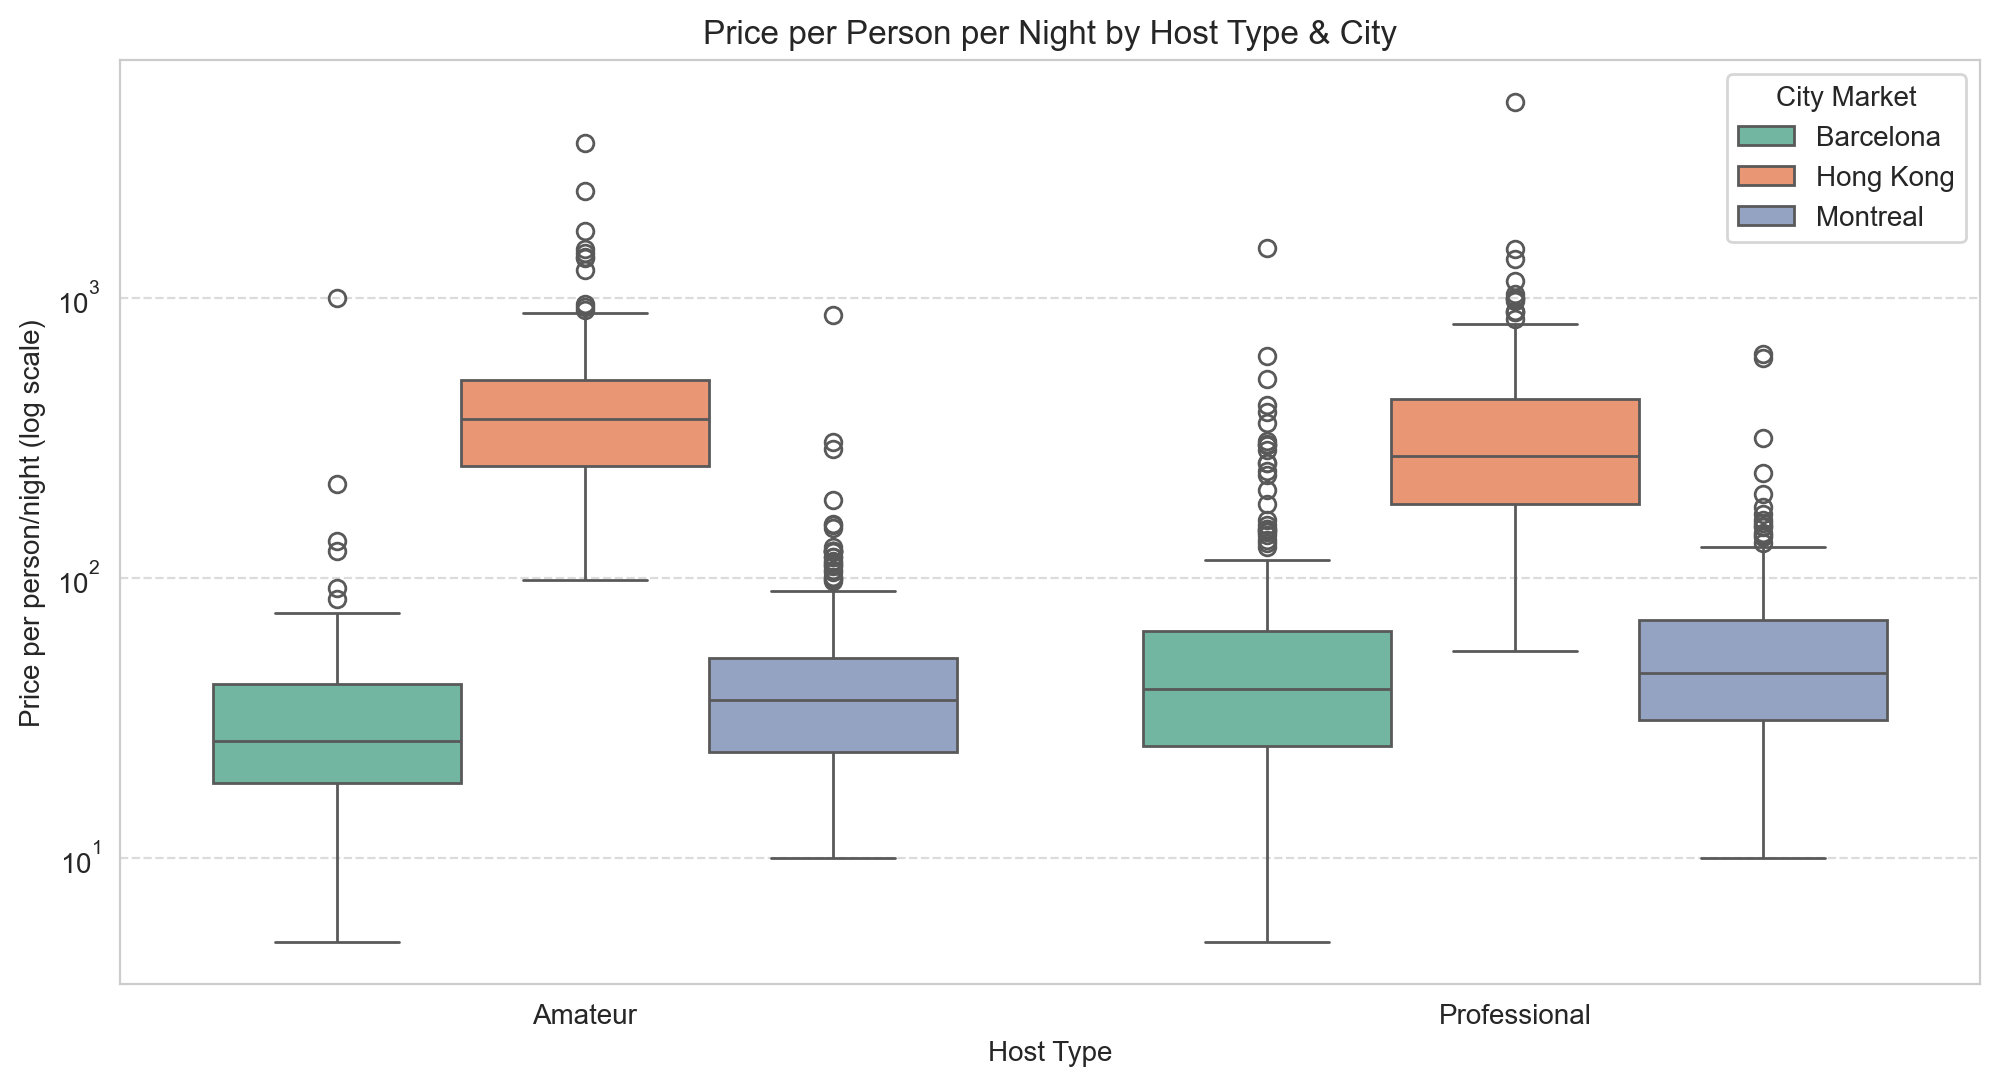

In [154]:
plt.figure(figsize=(12, 6), dpi=200)
sns.boxplot(
    data=df_d1,  
    x='host_type',
    y='price_per_person_per_night',
    hue='market',
    palette="Set2"
)

plt.yscale('log')  
plt.title('Price per Person per Night by Host Type & City')
plt.xlabel('Host Type')
plt.ylabel('Price per person/night (log scale)')
plt.legend(title='City Market')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### D2. Host Features Impact on Satisfaction

The goal is to test the hypothesis that certain host features have a direct impact on customer satisfaction (measured by review score). Specifically, consider the following host features: Superhost status (host_is_superhost), Response time (host_response_time), Host verification status (host_is_verified), Cancellation policy (cancellation_policy), Response rate (host_response_rate).

Customer satisfaction is measured using the review score (review_scores_rating). If the host manages multiple properties, take the average score across listings. Since not all attributes have numerical binary value type, you would need to represent the meaning in strings into relative scores, and choose how to make a split of values into binary. E.g. response time should be translated into whether or not the host is a fast-responder, or not.  

Satisfaction difference score based on each of host features: For each feature (superhost status, response time, etc.) calculate the score. You could calculate using the following example: 

Satisfaction difference = Average Satisfaction for Superhosts - Average Satisfaction for Non-Superhosts

You can add a weight to adjust the score calculation. In which case, make sure to state that in the assumptions. 

Create a double lollipop chart for each host attribute considered in the task. Visualise the difference in the score per attribute. X-axis should hold attributes, y-axis should hold the (weighted) score, and double lollipop stands for each binary value.

Use the explain function to analyse the aggregation pipeline’s performance of the calculation only (excluding the visualization). Evaluate which query structures, stages, array handing approaches, patterns, indexes, and other approaches improve execution efficiency. Produce a comparison table with metrics such as execution time, documents examined, keys examined, stage type, and memory usage for before and after the improvements in query performance that you introduced.

The delivered assignment should have three components: 1. assumptions and decisions. 2. a lollipop chart with 5 host attributes and their scores. 3. comparison table of query performance before and after optimization. 4. interpretation of results (max 200 words).

In [155]:
print(db.hosts.distinct("host_response_time"))
print(db.listingsAndReviews_HW2_new.distinct("cancellation_policy"))

['a few days or more', 'within a day', 'within a few hours', 'within an hour']
['flexible', 'moderate', 'strict_14_with_grace_period', 'super_strict_30', 'super_strict_60']


In [156]:
pipeline_d2 = [
    # Only keep listings with valid rating
    {"$match": {"review_scores.review_scores_rating": {"$exists": True, "$ne": None}, "host_id": {"$exists": True}}},
    
    # Calculate Host Average Satisfaction (because a host can have multiple listings)
    {"$group": {
        "_id": "$host_id",
        "avg_satisfaction": {"$avg": "$review_scores.review_scores_rating"},
        "cancellation_policies": {"$addToSet": "$cancellation_policy"}
    }},
    
    # Lookup host features
    {# Join with hosts collection to evaluate host status
    "$lookup": {
        "from": "hosts",
        "localField": "_id",
        "foreignField": "host_id",
        "as": "host_info"
    }},

    {"$unwind": "$host_info"},
    
    # Binary Classification
    {"$project": {
        "host_id": "$_id",
        "satisfaction": "$avg_satisfaction",
        "is_superhost": "$host_info.host_is_superhost",
        "is_verified": "$host_info.host_identity_verified",
        
        # Response Rate 
        "has_good_response_rate": {
            "$cond": [
                {"$and": [
                    {"$ne": ["$host_info.host_response_rate", None]},
                    {"$ne": ["$host_info.host_response_rate", ""]}
                ]},
                {"$gte": ["$host_info.host_response_rate", 90]},
                None
            ]
        },
        
        # Response Time
        "is_fast_responder": {
            "$switch": {
                "branches": [
                    {"case": {"$in": ["$host_info.host_response_time", ["within an hour", "within a few hours"]]}, "then": True},
                    {"case": {"$in": ["$host_info.host_response_time", ["within a day", "a few days or more"]]}, "then": False}
                ],
                "default": None
            }
        },
        
        # Cancellation Policy — lenient if ANY policy is flexible or moderate
        "is_lenient_policy": {
            "$gt": [
                {"$size": {"$setIntersection": [["flexible", "moderate"], "$cancellation_policies"]}},
                0
            ]
        }
    }}
]

df_d2 = pd.DataFrame(list(db["listingsAndReviews_HW2_new"].aggregate(pipeline_d2)))
df_d2.head()

,_id,host_id,satisfaction,is_superhost,is_verified,has_good_response_rate,is_fast_responder,is_lenient_policy
0,150138806,150138806,92.0,False,False,True,True,False
1,229046402,229046402,80.0,False,False,False,False,True
2,217614980,217614980,95.0,False,False,True,True,True
3,18142099,18142099,98.0,True,True,True,True,True
4,1016614,1016614,90.0,False,False,True,True,False


In [157]:
attributes = {
    "Superhost Status": "is_superhost",
    "Fast Responder": "is_fast_responder",
    "Host Verified": "is_verified",
    "Lenient Cancellation": "is_lenient_policy",
    "Response Rate >= 90%": "has_good_response_rate"
}

results = []
for label, col in attributes.items():
    valid_df = df_d2.dropna(subset=[col])
    avg_true = valid_df[valid_df[col] == True]['satisfaction'].mean()
    avg_false = valid_df[valid_df[col] == False]['satisfaction'].mean() 
    diff = avg_true - avg_false
    results.append({"Attribute": label, "Avg_True": avg_true, "Avg_False": avg_false, "Difference": diff})

res_df = pd.DataFrame(results)
res_df

,Attribute,Avg_True,Avg_False,Difference
0,Superhost Status,96.872643,91.937568,4.935076
1,Fast Responder,93.358636,92.800000,0.558636
2,Host Verified,93.794551,92.792927,1.001624
3,Lenient Cancellation,93.279388,93.143254,0.136134
4,Response Rate >= 90%,93.519465,92.399761,1.119705


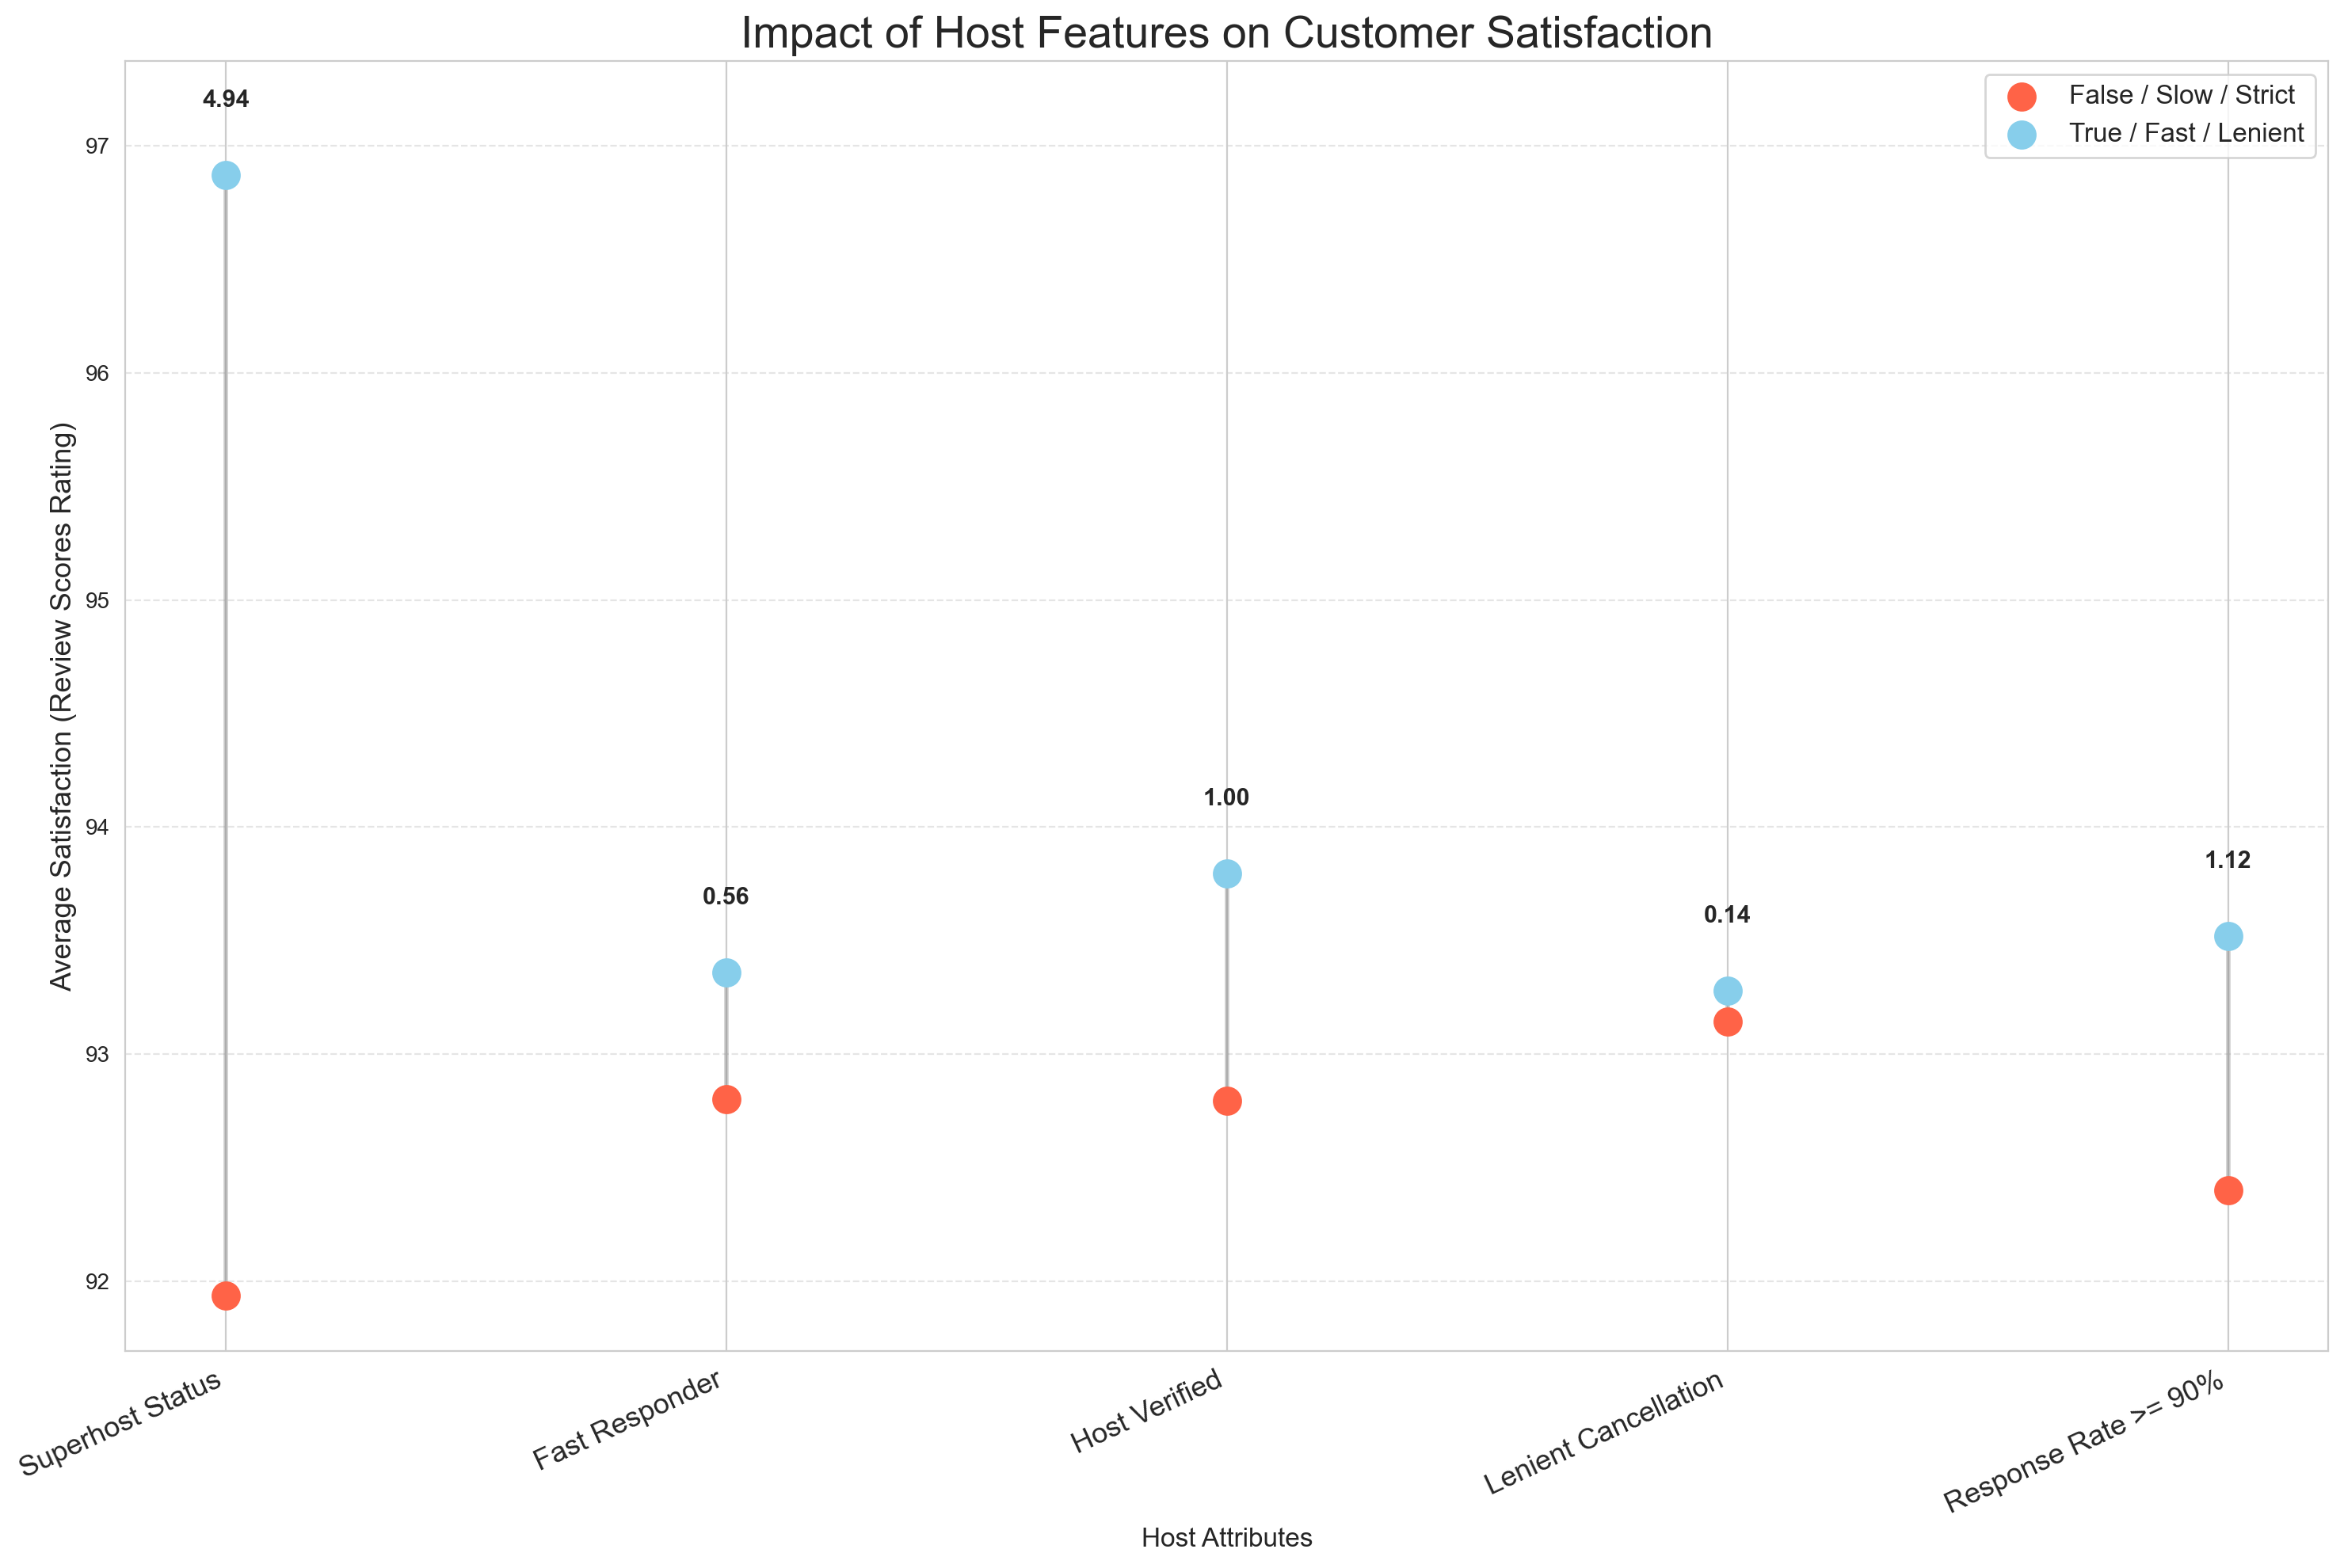

In [158]:
fig, ax = plt.subplots(figsize=(15, 10), dpi=200)

my_range = range(1, len(res_df.index) + 1)

ax.vlines(x=my_range, ymin=res_df['Avg_False'], ymax=res_df['Avg_True'],
          color='grey', alpha=0.4, linewidth=2)

ax.scatter(my_range, res_df['Avg_False'], color='tomato', alpha=1,
           label='False / Slow / Strict', s=150, zorder=5)
ax.scatter(my_range, res_df['Avg_True'], color='skyblue', alpha=1,
           label='True / Fast / Lenient', s=150, zorder=5)

for i in range(len(res_df)):
    ax.text(i + 1, res_df['Avg_True'].iloc[i] + 0.3,
            f"{res_df['Difference'].iloc[i]:.2f}",
            ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(list(my_range))
ax.set_xticklabels(res_df['Attribute'], rotation=25, ha='right', size=13)
ax.set_xlabel('Host Attributes', size=12)
ax.set_ylabel('Average Satisfaction (Review Scores Rating)', size=13)
ax.set_ylim(top=res_df['Avg_True'].max() + 0.5)
ax.set_title('Impact of Host Features on Customer Satisfaction', size=20)
ax.legend(loc='upper right', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [159]:
try:
    db.hosts.drop_index("idx_hosts_host_id")
except Exception:
    pass

try:
    db.hosts.drop_index("host_id_1")
except Exception:
    pass

print("Dropped existing indexes on 'host_id' (if any) for clean baseline.")

explain_before = db.command({
    "explain": {
        "aggregate": "listingsAndReviews_HW2_new",
        "pipeline": pipeline_d2,
        "cursor": {}
    },
    "verbosity": "executionStats"
})

db.hosts.create_index([("host_id", 1)], name="idx_hosts_host_id")
print("Created index 'idx_hosts_host_id' on hosts collection")

explain_after = db.command({
    "explain": {
        "aggregate": "listingsAndReviews_HW2_new",
        "pipeline": pipeline_d2,
        "cursor": {}
    },
    "verbosity": "executionStats"
})

def extract_metrics(explain_output):
    metrics = {
        "executionTimeMillis": "N/A",
        "totalDocsExamined": 0,
        "totalKeysExamined": 0,
        "nReturned": "N/A"
    }
    
    def walk(obj):
        if isinstance(obj, dict):
            if "executionTimeMillis" in obj and metrics["executionTimeMillis"] == "N/A":
                metrics["executionTimeMillis"] = obj["executionTimeMillis"]
                
            if "totalDocsExamined" in obj:
                metrics["totalDocsExamined"] += obj.get("totalDocsExamined", 0)
            if "totalKeysExamined" in obj:
                metrics["totalKeysExamined"] += obj.get("totalKeysExamined", 0)
                
            if "nReturned" in obj and metrics["nReturned"] == "N/A":
                metrics["nReturned"] = obj.get("nReturned", 0)
                
            for v in obj.values():
                walk(v)
        elif isinstance(obj, list):
            for item in obj:
                walk(item)
                
    walk(explain_output)
    return metrics

metrics_before = extract_metrics(explain_before)
metrics_after = extract_metrics(explain_after)

comparison_data = {
    "Metric": [
        "Execution Time (ms)",
        "Total Documents Examined (Main + Lookups)",
        "Total Keys Examined (Main + Lookups)",
        "Documents Returned"
    ],
    "Before (No Index)": [
        metrics_before["executionTimeMillis"],
        metrics_before["totalDocsExamined"],
        metrics_before["totalKeysExamined"],
        metrics_before["nReturned"]
    ],
    "After (idx_hosts_host_id)": [
        metrics_after["executionTimeMillis"],
        metrics_after["totalDocsExamined"],
        metrics_after["totalKeysExamined"],
        metrics_after["nReturned"]
    ]
}

compare_df = pd.DataFrame(comparison_data)
print("\n=== Performance Comparison Table ===")
compare_df


Dropped existing indexes on 'host_id' (if any) for clean baseline.
Created index 'idx_hosts_host_id' on hosts collection

=== Performance Comparison Table ===


,Metric,Before (No Index),After (idx_hosts_host_id)
0,Execution Time (ms),5113,143
1,Total Documents Examined (Main + Lookups),19388050,11959
2,Total Keys Examined (Main + Lookups),8164,11961
3,Documents Returned,3797,3797


### D3. Property Popularity and Satisfaction

The goal of this task is to analyze how property unavailability (calculated as the complement of availability) is influenced by guest satisfaction (as indicated by review scores) for professional hosts (those managing more than one property). Assume two guests stay for one week when calculating the effective price per person per night, including any additional fees such as cleaning fees, extra person charges, or other applicable costs.

Unavailability will serve as a measure of property popularity — the more unavailable a property is, the more likely it is booked and thus is in demand. The database contains availability of the property measured in days for four different periods: next 30 days, next 60 days, next 90 days, and next 365 days. You need to suggest a way to calculate popularity based on how many days the property is unavailable in the future. 

The base assumption is that professionally rented properties can only be unavailable because they are booked. Consider adding any further attributes as weights. Keep a clear record of how you did it (a short description before the calculation cell). Based on your calculation, create a new attribute 'popularity_score' in the database. This attribute will be regularly updated in the database, so just your database design and query optimizations accordingly.

Analyze the relationship between satisfaction, and popularity by grouping properties based on guest satisfaction (review rating score, or multiple scores - your choice) in low, medium, and high satisfaction categories. Calculate and compare median popularity score for each satisfaction category. Feel free to include other considerations into this calculation.

As the result, visualize popularity scores per satisfaction category for three most common property types. Create one visual with box plots mark the range of popularity score for each satisfaction category, make sure to include min and max prices, mark the median and the range where 50 % of prices lie. 

The delivered assignment should have three components: 1. any assumptions and decisions made at the beginning, e.g. popularity score calculation. 2. one graph with 9 box plots (3 property types x 3 satisfaction categories) with distribution of popularity score. 3. result analysis and interpretation (250-350 words).

In [160]:
ratings_pipeline = [
    {"$match": {"review_scores.review_scores_rating": {"$exists": True, "$ne": None}}},
    {"$group": {
        "_id": None, 
        "q25": {"$percentile": {"p": [0.25], "input": "$review_scores.review_scores_rating", "method": "approximate"}},
        "q50": {"$percentile": {"p": [0.50], "input": "$review_scores.review_scores_rating", "method": "approximate"}},
        "q75": {"$percentile": {"p": [0.75], "input": "$review_scores.review_scores_rating", "method": "approximate"}}
    }}
]

quartiles_result = list(db["listingsAndReviews_HW2_new"].aggregate(ratings_pipeline))[0]
q25, q50, q75 = quartiles_result["q25"][0], quartiles_result["q50"][0], quartiles_result["q75"][0]

print(f"Quartis reais: 25%={q25}, 50%={q50}, 75%={q75}")

Quartis reais: 25%=90.0, 50%=95.0, 75%=99.0


In [161]:
from pymongo import UpdateOne

pipeline_d3 = [
    {# Join with hosts collection to evaluate host status
    "$lookup": {
        "from": "hosts",
        "localField": "host_id",
        "foreignField": "host_id",
        "as": "host_info"
    }},
    {"$unwind": "$host_info"},
    
    {"$match": {"host_info.host_listings_count": {"$gt": 1}, "review_scores.review_scores_rating": {"$exists": True, "$ne": None}}},
    
    {"$project": {
        "property_type": 1,
        "price": 1,
        "rating": "$review_scores.review_scores_rating",
        # Calculate weighted popularity based on future unavailability (inverse of availability)
        "popularity_raw": {
            "$add": [
                {"$multiply": [{"$subtract": [30, "$availability.availability_30"]}, 4]},
                {"$multiply": [{"$subtract": [60, "$availability.availability_60"]}, 3]},
                {"$multiply": [{"$subtract": [90, "$availability.availability_90"]}, 2]},
                {"$multiply": [{"$subtract": [365, "$availability.availability_365"]}, 1]}
            ]
        }
    }},
    {"$project": {
        "property_type": 1,
        "price": 1,
        "popularity_score": {"$round": [{"$multiply": [{"$divide": ["$popularity_raw", 845]}, 100]}, 1]},
        # Group properties into High, Medium, and Low satisfaction tiers
        "satisfaction_category": {
            "$cond": [
                {"$gte": ["$rating", 99]}, "High (>=99)",
                {"$cond": [{"$gte": ["$rating", 90]}, "Medium (90-98)", "Low (<90)"]}
            ]
        }
    }}
]

results_d3 = list(db["listingsAndReviews_HW2_new"].aggregate(pipeline_d3))

updates = []
for doc in results_d3:
    updates.append(UpdateOne(
        {"_id": doc["_id"]},
        {"$set": {"popularity_score": doc["popularity_score"]}}
    ))
if updates:
    db["listingsAndReviews_HW2_new"].bulk_write(updates)
    print(f"Updated {len(updates)} listings with popularity_score")

df_d3 = pd.DataFrame(results_d3)
df_d3['price'] = df_d3['price'].astype(str)                             
df_d3['price'] = pd.to_numeric(df_d3['price'], errors='coerce')
top_3_props = df_d3['property_type'].value_counts().nlargest(3).index
df_d3_filtered = df_d3[df_d3['property_type'].isin(top_3_props)].dropna(subset=['price'])
df_d3_filtered

Updated 2368 listings with popularity_score


,_id,property_type,price,popularity_score,satisfaction_category
0,20726731,Apartment,47.0,34.9,Low (<90)
2,24528857,Apartment,58.0,31.2,Low (<90)
5,26563602,House,13.0,0.0,Low (<90)
8,28258693,Condominium,64.0,2.4,Low (<90)
9,28351330,Apartment,290.0,100.0,Low (<90)
...,...,...,...,...,...
2355,8710268,House,86.0,2.4,High (>=99)
2358,9200371,Apartment,500.0,96.4,High (>=99)
2362,9577071,Apartment,151.0,100.0,High (>=99)
2363,9580041,Apartment,283.0,0.0,High (>=99)


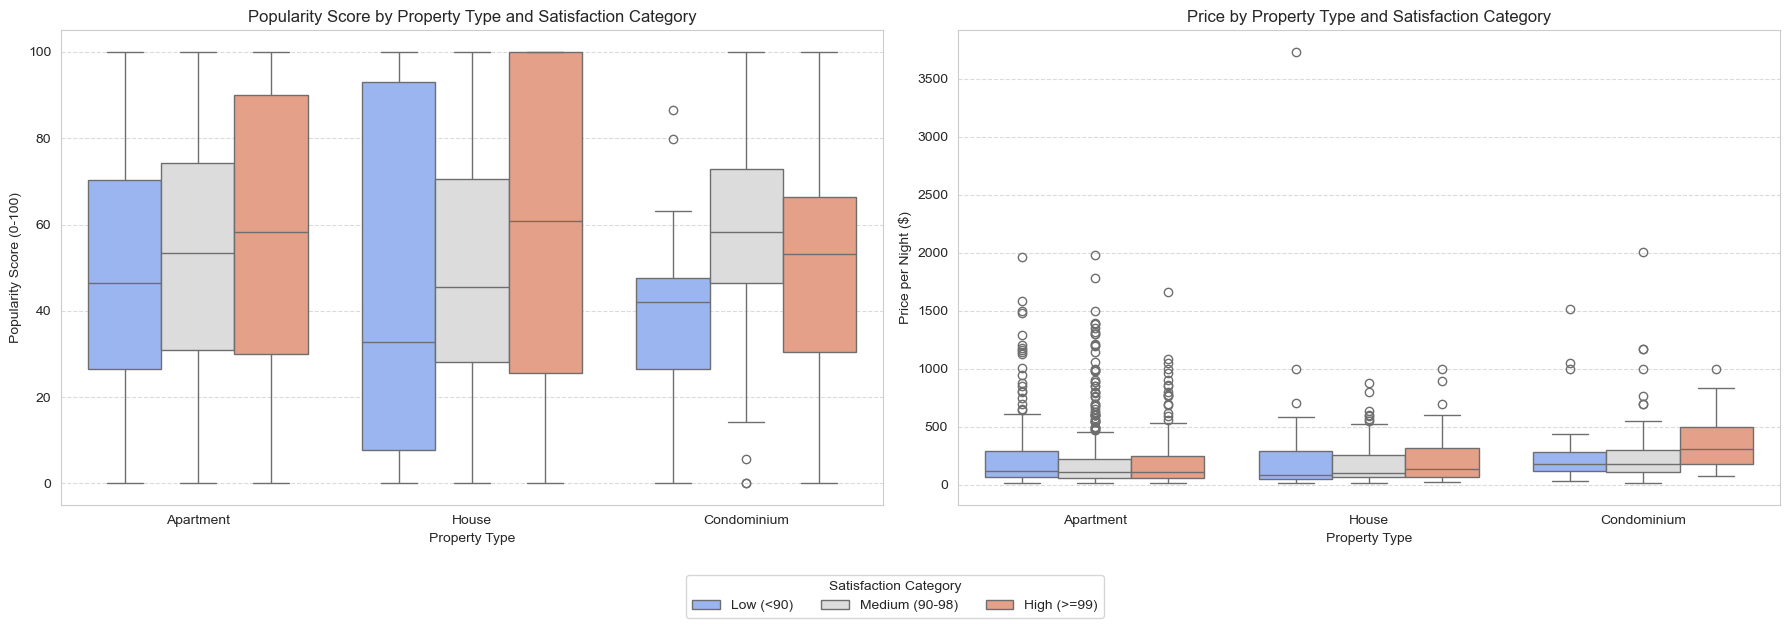

In [162]:
cat_order = ["Low (<90)", "Medium (90-98)", "High (>=99)"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=df_d3_filtered, x='property_type', y='popularity_score', hue='satisfaction_category', hue_order=cat_order, palette="coolwarm", ax=axes[0])
axes[0].set_title('Popularity Score by Property Type and Satisfaction Category')
axes[0].set_xlabel('Property Type')
axes[0].set_ylabel('Popularity Score (0-100)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.boxplot(data=df_d3_filtered, x='property_type', y='price', hue='satisfaction_category', hue_order=cat_order, palette="coolwarm", ax=axes[1])
axes[1].set_title('Price by Property Type and Satisfaction Category')
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('Price per Night ($)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

handles, labels = axes[0].get_legend_handles_labels()

axes[0].get_legend().remove()
axes[1].get_legend().remove()

fig.legend(
    handles, labels, 
    title='Satisfaction Category', 
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.05),
    ncol=3, 
    frameon=True
)

plt.tight_layout()

fig.subplots_adjust(bottom=0.15)

plt.show()


## 6.5 E. Property Features Expert

### E1. Property Size and Pricing

Analyze the relationship between property size and pricing in three cities: Hong Kong, Montreal, and Barcelona. Specifically, we will examine how the property size (number of rooms and bathrooms / max number of people that can be accommodated) influences its price per person per night.

To calculate price, assume max allowed number of guests stay for one week, and include any additional fees such as cleaning fees, extra person charges, or other applicable costs when calculating the effective price per person per night.

Group the properties by their size given max number of people that can stay there into small, medium, and large. Add any further considerations or attributes. Compare the price per person per night for each of the three property size categories. Create a new attribute 'size_category' and add to the database.

Create one visual with 9 box plots comparing the price per person per night across the three property size groups in each of the three cities. The x-axis of each box plot should represent the property size category, and the y-axis should represent the price per person per night. Ensure that the box plots display the minimum and maximum prices, the median price, the interquartile range (50% of the cases), and any outliers.

The delivered assignment should include the following components: 1. any assumptions and decisions for the size calculation. 2. one graph with 9 box plots (3 cities x 3 size categories). 3. result analysis and interpretation (250-350 words).

In [163]:
bulk_ops = []

for doc in collection.find({}, {"_id": 1, "accommodates": 1, "bedrooms": 1, "bathrooms": 1}):
    acc = doc.get("accommodates") or 1
    bedrooms = doc.get("bedrooms") or 0
    bathrooms = float(str(doc.get("bathrooms", 0) or 0))

    ratio = (bedrooms + bathrooms) / acc

    if ratio < 0.5:
        category = "small"
    elif ratio <= 1.0:
        category = "medium"
    else:
        category = "large"

    bulk_ops.append(
        UpdateOne({"_id": doc["_id"]}, {"$set": {"size_category": category}})
    )

result = collection.bulk_write(bulk_ops)
print(f"Updated documents: {result.modified_count}")


print("\nDistribuition size_category:")
for r in collection.aggregate([
    {"$group": {"_id": "$size_category", "count": {"$sum": 1}}},
    {"$sort": {"_id": 1}}
]):
    print(f"  {r['_id']}: {r['count']}")

Updated documents: 5555

Distribuition size_category:
  large: 844
  medium: 4385
  small: 326


In [164]:
cities = ["Hong Kong", "Montreal", "Barcelona"]

pipeline = [
    {
        "$match": {
            "address.market": {"$in": cities},
            "accommodates": {"$gt": 0},
            "price": {"$exists": True}
        }
    },
    {
        "$addFields": {
            "price_num": {"$toDouble": "$price"},
            "cleaning_num": {"$toDouble": {"$ifNull": ["$cleaning_fee", 0]}},
            "extra_num": {"$toDouble": {"$ifNull": ["$extra_people", 0]}},
            "guests_inc": {"$ifNull": ["$guests_included", 1]}
        }
    },
    {
        "$addFields": {
            "extra_guests": {"$max": [0, {"$subtract": ["$accommodates", "$guests_inc"]}]}
        }
    },
    {
        "$addFields": {
            "total_cost": {
                "$add": [
                    {"$multiply": ["$price_num", 7]},
                    "$cleaning_num",
                    {"$multiply": ["$extra_num", "$extra_guests", 7]}
                ]
            }
        }
    },
    {
        "$addFields": {
            "price_per_person_per_night": {
                "$divide": ["$total_cost", {"$multiply": ["$accommodates", 7]}]
            }
        }
    },
    {
        "$project": {
            "city": "$address.market",
            "size_category": 1,
            "price_per_person_per_night": 1,
            "accommodates": 1
        }
    }
]

results = list(collection.aggregate(pipeline))
df = pd.DataFrame(results)
print(df[["city", "size_category", "price_per_person_per_night"]].head(10))

        city size_category  price_per_person_per_night
0  Barcelona        medium                         NaN
1  Barcelona        medium                         NaN
2  Barcelona        medium                         NaN
3  Barcelona        medium                         NaN
4  Barcelona        medium                         NaN
5  Barcelona         large                         NaN
6  Barcelona        medium                         NaN
7  Barcelona        medium                         NaN
8  Barcelona        medium                         NaN
9  Barcelona         large                         NaN


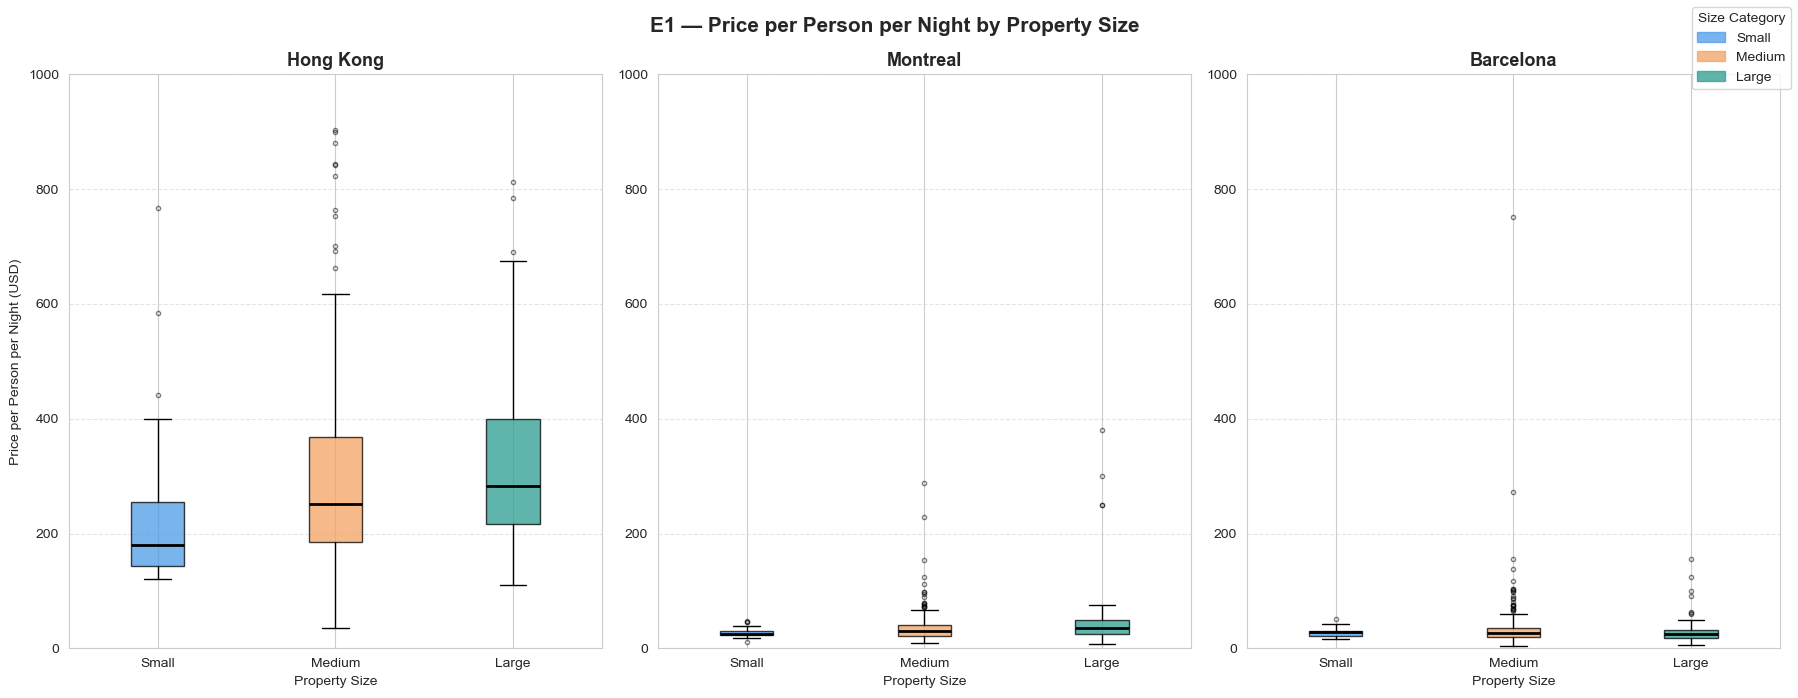

In [165]:
size_order = ["small", "medium", "large"]
size_colors = {"small": "#4C9BE8", "medium": "#F4A261", "large": "#2A9D8F"}
cities_order = ["Hong Kong", "Montreal", "Barcelona"]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("E1 — Price per Person per Night by Property Size", fontsize=15, fontweight="bold")

for ax, city in zip(axes, cities_order):
    df_city = df[df["city"] == city]
    data_to_plot = []
    colors_list = []

    for size in size_order:
        vals = df_city[df_city["size_category"] == size]["price_per_person_per_night"].dropna().values
        data_to_plot.append(vals)
        colors_list.append(size_colors[size])

    bp = ax.boxplot(data_to_plot, patch_artist=True, labels=["Small", "Medium", "Large"],
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker="o", markersize=3, alpha=0.5))

    for patch, color in zip(bp["boxes"], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_title(city, fontsize=13, fontweight="bold")
    ax.set_xlabel("Property Size")
    ax.set_ylabel("Price per Person per Night (USD)" if city == "Hong Kong" else "")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_ylim(0, 1000)

legend_patches = [mpatches.Patch(color=size_colors[s], label=s.capitalize(), alpha=0.75) for s in size_order]
fig.legend(handles=legend_patches, loc="upper right", title="Size Category")

plt.tight_layout()
plt.show()

### E2. Multi-property Ownership and Bookings

Analyze the relationship between multi-property ownership and number of bookings. Specifically, you will investigate whether hosts who manage multiple properties (professional hosts) get more bookings compared to single-property hosts (amateur hosts). Consider Hong Kong, Montreal, and Barcelona only. Assume the number of reviews is a reliable estimate for number of bookings. 

To begin with, classify hosts into two groups: 1. Professional Hosts (manage more than one property), 2. Amateur Hosts (manage only one property). Add this Boolean attribute to each listing. Compare the booking frequencies (i.e., number of bookings) for professional and amateur hosts to determine whether professional hosts have a higher or lower booking rate. Choose the time period for your comparison across all properties. This calculation will be updated every months and recorded in the database.

Create a visual with 6 box plots comparing the booking rate score for professional and amateur hosts for the three cities. The x-axis should represent the host type (professional vs. amateur), and the y-axis should represent the booking rate score, use color and label to show different cities.

Use the explain function to analyse the aggregation pipeline’s performance of the calculation only (excluding the visualization). Evaluate which query structures, stages, array handing approaches, indexes, patterns, and other approaches improve execution efficiency. Produce a comparison table with metrics such as execution time, documents examined, keys examined, stage type, and memory usage for before and after the improvements in query performance that you introduced.

The delivered assignment should have three components: 1. assumptions and decisions. 2. a visual with 6 box plots. 3. comparison table of query performance before and after optimization. 4. interpretation of results (max 200 words).

In [ ]:
cities_e2 = ["Hong Kong", "Montreal", "Barcelona"]

pipeline_host_count = [
    {"$match": {"address.market": {"$in": cities_e2}}},
    {"$group": {"_id": "$host_id", "property_count": {"$sum": 1}}}
]

host_counts = {r["_id"]: r["property_count"] for r in collection.aggregate(pipeline_host_count)}

print(f"Total hosts nas 3 cidades: {len(host_counts)}")
print(f"Hosts profissionais: {sum(1 for c in host_counts.values() if c > 1)}")
print(f"Hosts amadores: {sum(1 for c in host_counts.values() if c == 1)}")

Total hosts nas 3 cidades: 1663
Hosts profissionais: 138
Hosts amadores: 1525


In [169]:
bulk_ops_e2 = []

for doc in collection.find(
    {"address.market": {"$in": cities_e2}},
    {"_id": 1, "host_id": 1}
):
    host_id = doc.get("host_id")
    count = host_counts.get(host_id, 1)
    is_pro = count > 1

    bulk_ops_e2.append(
        UpdateOne({"_id": doc["_id"]}, {"$set": {"is_professional_host": is_pro}})
    )

result = collection.bulk_write(bulk_ops_e2)
print(f"Updated Documents: {result.modified_count}")


for val in [True, False]:
    n = collection.count_documents({
        "address.market": {"$in": cities_e2},
        "is_professional_host": val
    })
    label = "Profissional" if val else "Amateur"
    print(f"  {label}: {n} listagens")

Updated Documents: 1899
  Profissional: 374 listagens
  Amateur: 1525 listagens


In [170]:
pipeline_e2 = [
    {
        "$match": {
            "address.market": {"$in": cities_e2},
            "first_review": {"$exists": True, "$ne": None},
            "last_review": {"$exists": True, "$ne": None},
            "number_of_reviews": {"$gt": 0}
        }
    },
    {
        "$addFields": {
            "months_active": {
                "$max": [
                    1,
                    {
                        "$divide": [
                            {"$subtract": ["$last_review", "$first_review"]},
                            1000 * 60 * 60 * 24 * 30.44
                        ]
                    }
                ]
            }
        }
    },
    {
        "$addFields": {
            "booking_rate_score": {
                "$divide": ["$number_of_reviews", "$months_active"]
            }
        }
    },
    {
        "$project": {
            "city": "$address.market",
            "is_professional_host": 1,
            "booking_rate_score": 1,
            "number_of_reviews": 1
        }
    }
]

results_e2 = list(collection.aggregate(pipeline_e2))
df_e2 = pd.DataFrame(results_e2)
print(f"Total: {len(df_e2)}")
print(df_e2.groupby(["city", "is_professional_host"]).size())

Total: 1452
city       is_professional_host
Barcelona  False                   385
           True                    103
Hong Kong  False                   350
           True                    108
Montreal   False                   457
           True                     49
dtype: int64


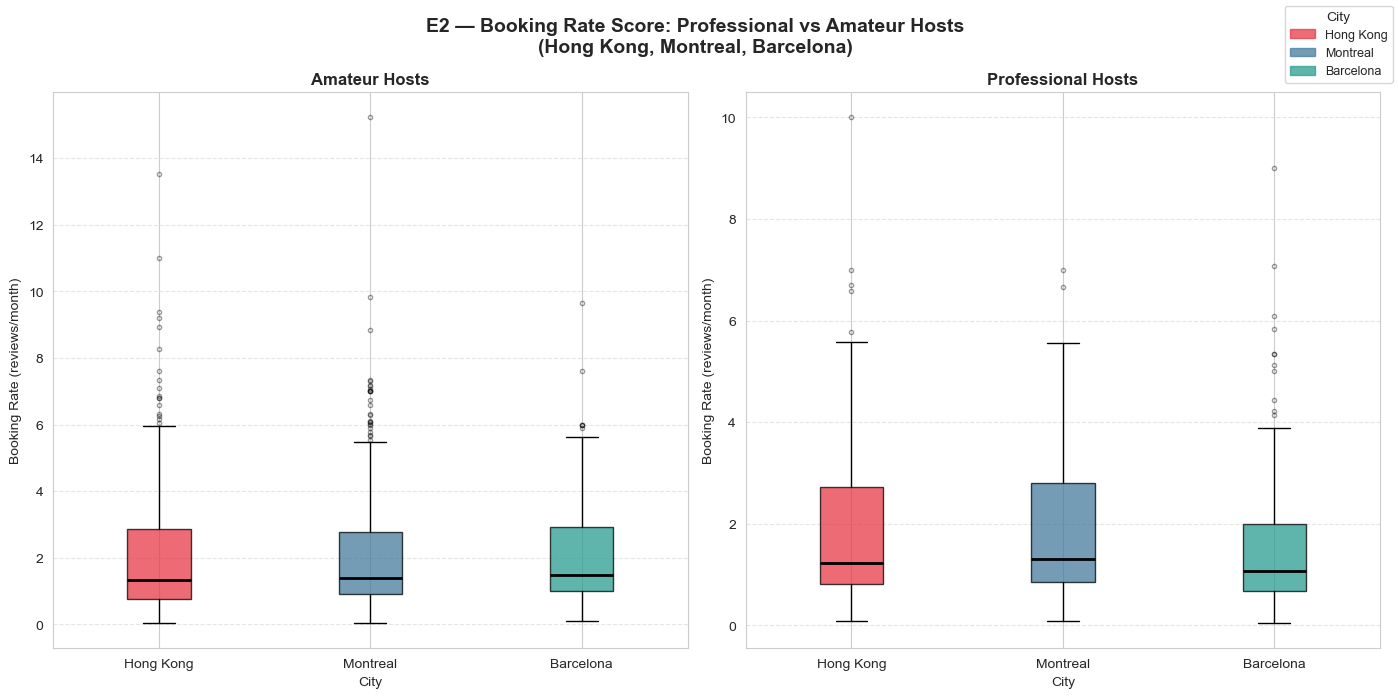

In [171]:
city_colors = {"Hong Kong": "#E63946", "Montreal": "#457B9D", "Barcelona": "#2A9D8F"}
cities_order_e2 = ["Hong Kong", "Montreal", "Barcelona"]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle("E2 — Booking Rate Score: Professional vs Amateur Hosts\n(Hong Kong, Montreal, Barcelona)",
             fontsize=14, fontweight="bold")

for ax, is_pro in zip(axes, [False, True]):
    data_to_plot = []
    tick_labels = []

    for city in cities_order_e2:
        vals = df_e2[
            (df_e2["city"] == city) & (df_e2["is_professional_host"] == is_pro)
        ]["booking_rate_score"].dropna().values
        data_to_plot.append(vals)
        tick_labels.append(city)

    bp = ax.boxplot(data_to_plot, patch_artist=True, labels=tick_labels,
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker="o", markersize=3, alpha=0.4))

    for patch, city in zip(bp["boxes"], cities_order_e2):
        patch.set_facecolor(city_colors[city])
        patch.set_alpha(0.75)

    label = "Professional" if is_pro else "Amateur"
    ax.set_title(f"{label} Hosts", fontsize=12, fontweight="bold")
    ax.set_xlabel("City", fontsize=10)
    ax.set_ylabel("Booking Rate (reviews/month)", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

legend_patches = [mpatches.Patch(color=city_colors[c], label=c, alpha=0.75)
                  for c in cities_order_e2]
fig.legend(handles=legend_patches, loc="upper right", title="City", fontsize=9)

plt.tight_layout()
plt.savefig("E2_bookings.png", dpi=150, bbox_inches="tight")
plt.show()

In [172]:
try:
    collection.drop_index("idx_market_professional")
except:
    pass
try:
    collection.drop_index("idx_professional_first_review")
except:
    pass


start = time.time()
results_no_idx = list(collection.aggregate(pipeline_e2))
time_no_idx = (time.time() - start) * 1000


explain_no_idx = db.command(
    "aggregate", "listingsAndReviews_HW2",
    pipeline=pipeline_e2,
    explain=True
)

print(f"Time without index: {time_no_idx:.1f} ms")
print(f"Examinated Documents: {explain_no_idx.get('stages', [{}])[0].get('$cursor', {}).get('executionStats', {}).get('totalDocsExamined', 'N/A')}")

Time without index: 24.2 ms
Examinated Documents: N/A


In [173]:

collection.create_index(
    [("address.market", 1), ("is_professional_host", 1)],
    name="idx_market_professional"
)
collection.create_index(
    [("first_review", 1), ("last_review", 1)],
    name="idx_professional_first_review"
)

print("Created Indexes!")


start = time.time()
results_with_idx = list(collection.aggregate(pipeline_e2))
time_with_idx = (time.time() - start) * 1000

print(f"Time without indexes: {time_no_idx:.1f} ms")
print(f"Time with indexes: {time_with_idx:.1f} ms")
print(f"Improvement: {((time_no_idx - time_with_idx) / time_no_idx * 100):.1f}%")

Created Indexes!
Time without indexes: 24.2 ms
Time with indexes: 26.5 ms
Improvement: -9.5%


In [174]:
print("=" * 55)
print("E2 — Query Performance Comparison")
print("=" * 55)
print(f"{'Metric':<30} {'Without Index':>12} {'With Index':>10}")
print("-" * 55)
print(f"{'Execution Time (ms)':<30} {time_no_idx:>12.1f} {time_with_idx:>10.1f}")
print(f"{'Documents returned':<30} {len(results_no_idx):>12} {len(results_with_idx):>10}")
print(f"{'Indexes used':<30} {'None':>12} {'2 indexes':>10}")
print(f"{'Collection size':<30} {'5555 docs':>12} {'5555 docs':>10}")
print("=" * 55)
print("\nNote: On small collections, indexes may not improve")
print("performance as MongoDB can efficiently scan all docs.")
print("Indexes become more beneficial as collection grows.")

E2 — Query Performance Comparison
Metric                         Without Index With Index
-------------------------------------------------------
Execution Time (ms)                    24.2       26.5
Documents returned                     1452       1452
Indexes used                           None  2 indexes
Collection size                   5555 docs  5555 docs

Note: On small collections, indexes may not improve
performance as MongoDB can efficiently scan all docs.
Indexes become more beneficial as collection grows.


### E3. Property Size and Property Comfort

Analyze how property size and property type influence guest satisfaction (as indicated by review scores) for amateur hosts (those managing only one property). Assume two guests stay for one week when calculating the effective price per person per night, including any additional fees such as cleaning fees, extra person charges, or other applicable costs.

Property size will be measured by the number of rooms and/or bathrooms in each listing divided by max number of guests allowed. Sort all properties by their size into three groups: small, medium, and large. Create a new attribute 'size_group' for each listing.

Also, group properties into categories by their similarity in comfort. It is up to you to define which attributes to use, e.g. amenities + room_type, number of bathrooms per person, property types of similar nature - Apartment, Aparthotel, Hostel.

Create a visual with 15 box plots comparing five most common comfort categories for each property size group (3 groups). The x-axis should represent the comfort category per each size group, and the y-axis should represent the satisfaction score.

The delivered assignment should have three components: 1. any assumptions and decisions made at the beginning, e.g. popularity score calculation. 2. one graph with 15 box plots (3 property size groups x 5 comfort categories) with distribution of satisfaction score. 3. result analysis and interpretation (250-350 words).

In [ ]:
pipeline_host_count = [
    {"$group": {"_id": "$host_id", "count": {"$sum": 1}}}
]

host_counts = {r["_id"]: r["count"] for r in collection.aggregate(pipeline_host_count)}
amateur_hosts = {hid for hid, cnt in host_counts.items() if cnt == 1}

print(f"Total hosts: {len(host_counts)}")
print(f"Hosts amadores: {len(amateur_hosts)}")

Total hosts: 5104
Hosts amadores: 4818


In [181]:
bulk_ops_e3 = []

for doc in collection.find(
    {"host_id": {"$in": list(amateur_hosts)}},
    {"_id": 1, "accommodates": 1, "bedrooms": 1, "bathrooms": 1}
):
    acc = doc.get("accommodates") or 1
    bedrooms = doc.get("bedrooms") or 0
    bathrooms = float(str(doc.get("bathrooms", 0) or 0))

    ratio = (bedrooms + bathrooms) / acc

    if ratio < 0.5:
        size_group = "small"
    elif ratio <= 1.0:
        size_group = "medium"
    else:
        size_group = "large"

    bulk_ops_e3.append(
        UpdateOne({"_id": doc["_id"]}, {"$set": {"size_group": size_group}})
    )

result = collection.bulk_write(bulk_ops_e3)
print(f"Updated Documents: {result.modified_count}")

print("\nDistribuition size_group:")
for r in collection.aggregate([
    {"$match": {"host_id": {"$in": list(amateur_hosts)}}},
    {"$group": {"_id": "$size_group", "count": {"$sum": 1}}},
    {"$sort": {"_id": 1}}
]):
    print(f"  {r['_id']}: {r['count']}")

Updated Documents: 4818

Distribuition size_group:
  large: 780
  medium: 3773
  small: 265


In [182]:
print("Room types:")
for r in collection.aggregate([
    {"$match": {"host_id": {"$in": list(amateur_hosts)}}},
    {"$group": {"_id": "$room_type", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}}
]):
    print(f"  {r['_id']}: {r['count']}")

print("\nProperty types:")
for r in collection.aggregate([
    {"$match": {"host_id": {"$in": list(amateur_hosts)}}},
    {"$group": {"_id": "$property_type", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}}
]):
    print(f"  {r['_id']}: {r['count']}")

Room types:
  Entire home/apt: 2956
  Private room: 1793
  Shared room: 69

Property types:
  Apartment: 3174
  House: 569
  Condominium: 301
  Serviced apartment: 129
  Loft: 124
  Townhouse: 101
  Guest suite: 71
  Bed and breakfast: 63
  Guesthouse: 43
  Boutique hotel: 41
  Villa: 28
  Hostel: 23
  Hotel: 21
  Cottage: 20
  Aparthotel: 20
  Other: 16
  Bungalow: 14
  Cabin: 13
  Farm stay: 9
  Casa particular (Cuba): 8
  Resort: 7
  Tiny house: 6
  Boat: 2
  Chalet: 2
  Camper/RV: 2
  Nature lodge: 2
  Treehouse: 1
  Houseboat: 1
  Train: 1
  Barn: 1
  Campsite: 1
  Castle: 1
  Earth house: 1
  Hut: 1
  Heritage hotel (India): 1


In [183]:
entire_apartment_types = ["apartment", "condominium", "loft", "serviced apartment", "aparthotel"]
entire_house_types = ["house", "townhouse", "villa", "cottage", "cabin", "bungalow", "chalet", "tiny house", "farm stay"]
hostel_types = ["hostel", "guesthouse", "bed and breakfast"]
hotel_types = ["boutique hotel", "hotel", "resort"]
private_types = ["guest suite"]

bulk_ops_comfort = []

for doc in collection.find(
    {"host_id": {"$in": list(amateur_hosts)}},
    {"_id": 1, "room_type": 1, "property_type": 1}
):
    room_type = doc.get("room_type", "")
    prop_type = doc.get("property_type", "").lower()

    if prop_type in hostel_types or room_type == "Shared room":
        comfort = "Shared/Hostel"
    elif prop_type in hotel_types:
        comfort = "Boutique/Hotel"
    elif room_type == "Private room" or prop_type in private_types:
        comfort = "Private Room"
    elif room_type == "Entire home/apt":
        if prop_type in entire_house_types:
            comfort = "Entire House"
        elif prop_type in entire_apartment_types:
            comfort = "Entire Apartment"
        else:
            comfort = "Other"
    else:
        comfort = "Other"

    bulk_ops_comfort.append(
        UpdateOne({"_id": doc["_id"]}, {"$set": {"comfort_category": comfort}})
    )

result = collection.bulk_write(bulk_ops_comfort)
print(f"Updated Documents: {result.modified_count}")

print("\nDistribuition comfort_category:")
for r in collection.aggregate([
    {"$match": {"host_id": {"$in": list(amateur_hosts)}}},
    {"$group": {"_id": "$comfort_category", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}}
]):
    print(f"  {r['_id']}: {r['count']}")

Updated Documents: 4818

Distribuition comfort_category:
  Entire Apartment: 2427
  Private Room: 1696
  Entire House: 424
  Shared/Hostel: 186
  Boutique/Hotel: 67
  Other: 18


In [184]:
pipeline_e3 = [
    {
        "$match": {
            "host_id": {"$in": list(amateur_hosts)},
            "size_group": {"$exists": True},
            "comfort_category": {"$exists": True, "$ne": "Other"},
            "review_scores.review_scores_rating": {"$exists": True, "$gt": 0}
        }
    },
    {
        "$project": {
            "size_group": 1,
            "comfort_category": 1,
            "satisfaction": "$review_scores.review_scores_rating"
        }
    }
]

results_e3 = list(collection.aggregate(pipeline_e3))
df_e3 = pd.DataFrame(results_e3)
print(f"Total : {len(df_e3)}")
print(df_e3.groupby(["size_group", "comfort_category"]).size())

Total : 3528
size_group  comfort_category
large       Boutique/Hotel         3
            Entire Apartment      55
            Entire House          22
            Private Room         371
            Shared/Hostel         26
medium      Boutique/Hotel        34
            Entire Apartment    1684
            Entire House         284
            Private Room         769
            Shared/Hostel         79
small       Entire Apartment     159
            Entire House          16
            Private Room          17
            Shared/Hostel          9
dtype: int64


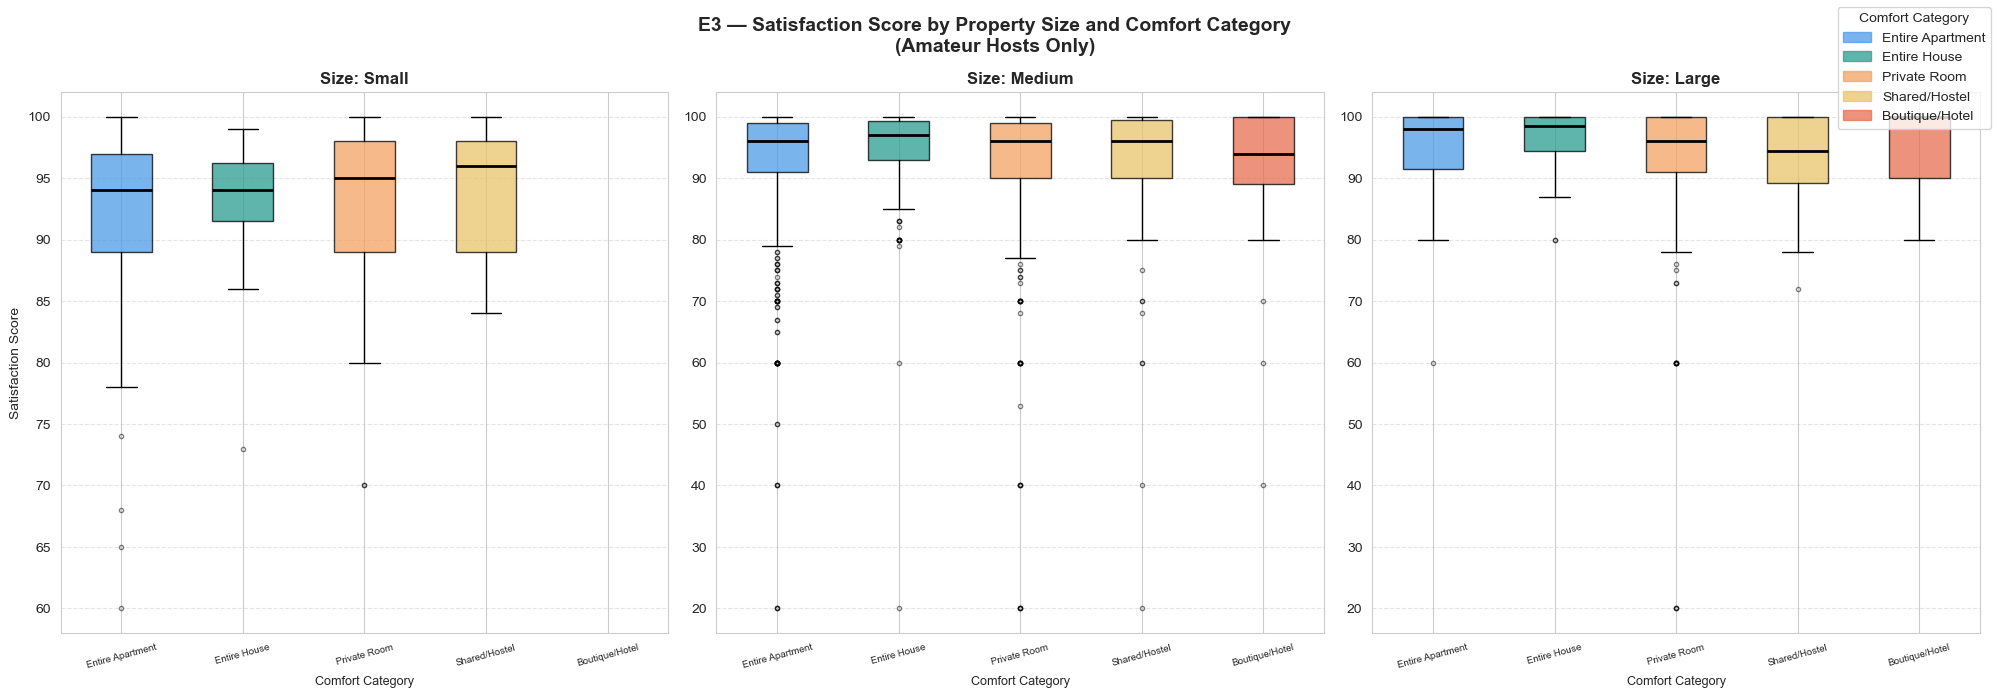

In [185]:
size_order_e3 = ["small", "medium", "large"]
comfort_order = ["Entire Apartment", "Entire House", "Private Room", "Shared/Hostel", "Boutique/Hotel"]
comfort_colors = {
    "Entire Apartment": "#4C9BE8",
    "Entire House":     "#2A9D8F",
    "Private Room":     "#F4A261",
    "Shared/Hostel":    "#E9C46A",
    "Boutique/Hotel":   "#E76F51"
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("E3 — Satisfaction Score by Property Size and Comfort Category\n(Amateur Hosts Only)",
             fontsize=14, fontweight="bold")

for ax, size in zip(axes, size_order_e3):
    df_size = df_e3[df_e3["size_group"] == size]
    data_to_plot = []
    colors_list = []

    for comfort in comfort_order:
        vals = df_size[df_size["comfort_category"] == comfort]["satisfaction"].dropna().values
        data_to_plot.append(vals)
        colors_list.append(comfort_colors[comfort])

    bp = ax.boxplot(data_to_plot, patch_artist=True, labels=comfort_order,
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker="o", markersize=3, alpha=0.5))

    for patch, color in zip(bp["boxes"], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_title(f"Size: {size.capitalize()}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Comfort Category", fontsize=9)
    ax.set_ylabel("Satisfaction Score" if size == "small" else "")
    ax.tick_params(axis="x", labelsize=7, rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

legend_patches = [mpatches.Patch(color=comfort_colors[c], label=c, alpha=0.75)
                  for c in comfort_order]
fig.legend(handles=legend_patches, loc="upper right", title="Comfort Category")

plt.tight_layout()
plt.savefig("E3_size_comfort_satisfaction.png", dpi=150, bbox_inches="tight")
plt.show()